# plotting full ensemble

In [1]:
#import datetime as dt
import cftime 
from datetime import datetime as py_datetime

import time
import datetime
from datetime import datetime as py_datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import sys
sys.path.append('src/')
sys.path.append('src/fsrc/')
import ens

from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap, to_rgb

# from contextlib import redirect_stdout
# import io
def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

## settings for plots - makes them look nicer
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('xtick', labelsize=13) 
plt.rc('ytick', labelsize=13) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})

In [2]:
import skimage.measure as sm
from scipy import stats

import netCDF4 as ncdf
import numpy as N
import math as M
import glob
import sys
import os
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime as dt
from subprocess import *
#from cbook2 import *
import src.plot_src.ctables as ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial

from mpl_toolkits.basemap import Basemap


import sys
sys.path.append('fsrc/')
from fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d

import state_vector as state



#from ens import read_CM1_ens

def subplot_format(n):
    ''' keeps an approximately square subplot organization. 
    The longer number will always be columns (so the figure will be wider than tall). 
    Reverse row,col in the return if you would prefer a taller plot'''
    
    facs= list( set(x for tup in ([i, n//i] for i in range(1, int(n**0.5)+1) if n % i == 0) for x in tup))
    if len(facs) %2 == 0:
        row, col = facs[int(len(facs)/2)-1:int(len(facs)/2)+1]
    else:
        col = row = int(np.sqrt(n))
    return row, col

def silence_print(func, *args, **kwargs):
    with redirect_stdout(io.StringIO()) as f: # this just silences all the obnoxious output
        return func(*args, **kwargs)

#===============================================================================
from ens import mymap
import scipy
import pandas as pd
import colormaps as cmaps

def get_dbz_fast(analysis_time, fpath, cref=True, ob_file=None):

    if fpath[-1]=='/': fpath=fpath[:-1]
    name = os.path.basename(fpath)
    
    with open(f'{fpath}/{name}.exp', 'rb') as f: exper = json.load(f)
    
    # These values are set in the experiment dictionary created at the begining of the run
    
    xoffset = exper['xoffset']
    yoffset = exper['yoffset']
    glat    = exper['lat0']
    glon    = exper['lon0']
      
    if ob_file == None:
      ob_file = exper['radar_obs']
    
    ob_f = pd.read_csv(ob_file)
    
    # look for reflectivity +/- 2.5 min 
    
    dt            = datetime.timedelta(0,30)
    begin  = cftime.date2num(analysis_time - dt, "seconds since 1970-01-01 00:00:00")
    ending = cftime.date2num(analysis_time + dt, "seconds since 1970-01-01 00:00:00")
    
    data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) &(ob_f.kind==12) # only dbz
    
    odata = ob_f[data_mask]
    
    data    = odata['value'][:]
    lats    = odata['lat'][:]
    lons    = odata['lon'][:]
    hgts    = odata['height'][:]
    
    cm1 = exper['cm1namelist']
    names = [c[1] for c in cm1]
    nx=cm1[np.where(np.array(names)=='nx')[0][0]][2]
    ny=cm1[np.where(np.array(names)=='ny')[0][0]][2]
    nz=cm1[np.where(np.array(names)=='nz')[0][0]][2]
    dx=cm1[np.where(np.array(names)=='dx')[0][0]][2]
    
    fstate_xc = np.arange(0, nx*dx, dx) + dx/2
    fstate_xc += exper['xoffset']
    fstate_yc = np.arange(0, ny*dx, dx) + dx/2
    fstate_yc += exper['yoffset']
    
    temp = xr.open_dataset(sorted(glob.glob(f"{exper['fcst_members'][0]}/*.nc"))[0], decode_timedelta=True)
    fstate_zc=temp.zh.values
    temp.close()
    
    map      = mymap(fstate_xc, fstate_yc, glat, glon)
    xob, yob = map(lons, lats)
    xob, yob = xob+xoffset, yob+yoffset
    
    # The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
    #     ens stores the x/y grid in grid-internal coordinates
    # Create obs list for KDTree query...
    xyz_obs  = np.vstack((hgts,yob,xob))
    obs_list = list(xyz_obs.transpose())
    
    # Create 3D grid arrays for KDTree
    y_array, z_array, x_array = np.meshgrid(fstate_yc, fstate_zc, fstate_xc)
    xyz_grid = np.dstack([z_array.ravel(),y_array.ravel(),x_array.ravel()])[0]
      
    # Use cKDTree to create fast indexing for 3D grid....
    
    mytree = scipy.spatial.cKDTree(xyz_grid)
    distance, indices1D = mytree.query(obs_list)
    
    # these are the integer indices that you now pass into the fortran routine. They
    # are the un-raveled 3D index locations nearest the observation point in the 3D array
    
    kk,jj,ii = np.unravel_index(indices1D, (len(fstate.zc), len(fstate.yc), len(fstate.xc))) 
    dbz3d = obs_2_grid3d(data, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)

    # Create composite reflectivity, and then replicate it into a 3D array
    
    dbz2d = np.zeros((1,))
    
    if cref:
    
        dbz2d = dbz3d.max(axis=0)
    
        for k in np.arange(nz):
            dbz3d[k] = dbz2d
      
    #if verbose: print("\n ==> ens_GRID_REFL: 2D composite DBZ requested   Max:  %4.1f   Min:  %4.1f" % (dbz2d.max(), dbz2d.min()))
    
    del xyz_obs, x_array, y_array, z_array, xyz_grid, mytree
             
    return dbz3d


def get_mean_var(files, var, height=None, return_dims=False, return_all_dims=False):
    myvar = []
    for f in files:
        cm1 = xr.open_dataset(f, decode_timedelta=True)
        if height != None:
            zi = findnearest(cm1.zh, height)
            myvar.append(cm1[var][0,zi].values)
        else:
            myvar.append(cm1[var][0].values)
    if return_dims:
        z,y,x = cm1.zh.values, cm1.yh.values, cm1.xh.values
        
    cm1.close()
    meanvar = np.mean(myvar, axis=0)
    
    if return_dims:
        if (height==None) | (return_all_dims==True):
            return z,y,x, meanvar
        else:
            return y,x, meanvar
    else:
        return meanvar


def pmm(cm1, var, height,t, return_mean=False):
    ''' height is in km'''

    N = cm1.sizes['ne']-1
    zi = findnearest(cm1.z, height)

    ens_mean = cm1[var][t, -1,zi]
    ranked_ens =sorted(cm1[var][t, :-1, zi].values.ravel())[::N]
    
    x,y = np.meshgrid(cm1.xh, cm1.yh)
    d = {'ens':ens_mean.values.ravel(), 'x':x.ravel(), 'y':y.ravel()}
    df = pd.DataFrame(d)
    
    df_ranked = df.sort_values(by='ens')
    df_ranked['ens'] = ranked_ens
    
    df_pmm = df_ranked.sort_index()

    if return_mean:
    
        return df_pmm['ens'].values.reshape(np.shape(x)), ens_mean
    else:
        return df_pmm['ens'].values.reshape(np.shape(x))



    
def add_scale(ax, xstart=200, xlength=50, y=280, cap_length=200*.04):

    xend = xstart+xlength
    
    ax.plot([xstart,xend], [y,y], color='k')
    ax.plot([xstart,xstart], [y-cap_length/2,y+cap_length/2], color='k')
    ax.plot([xend, xend], [y-cap_length/2,y+cap_length/2], color='k')
    #ax.text(xstart+xlength/2, y-cap_length/2, '{xlength} km', ha='center', va='top', fontsize=13)
    ax.text(xstart+xlength/2, y+cap_length/2, f'{xlength} km', ha='center', va='bottom', fontsize=13)


def raw_probs(field, threshold, ensN):
   
    probs = np.zeros_like(field)
    probs[field >= threshold] = 1
    return probs.sum(axis=0)/ensN

In [231]:
PRIOR =False
fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/'

time = dt.datetime(2024,5,8,21,0)

with open(f'{fpath}letkf.exp', 'rb') as f:exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=PRIOR)

ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 21:00:00

 ==> FindRestartFile:  Found time 5400 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/member001/cm1rst_000014.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 21:00:00 


 Wallclock time for serial read netCDF ensemble files: 12.322  sec

 Wallclock time to convert from C to A grid: 0.765  sec

 Wallclock time to create ensemble means: 1.217  sec

 Wallclock time to read arrays from netCDF ensemble files: 15.053  sec

 Wallclock time to create coordinates: 0.0  sec


           2           2
43 60


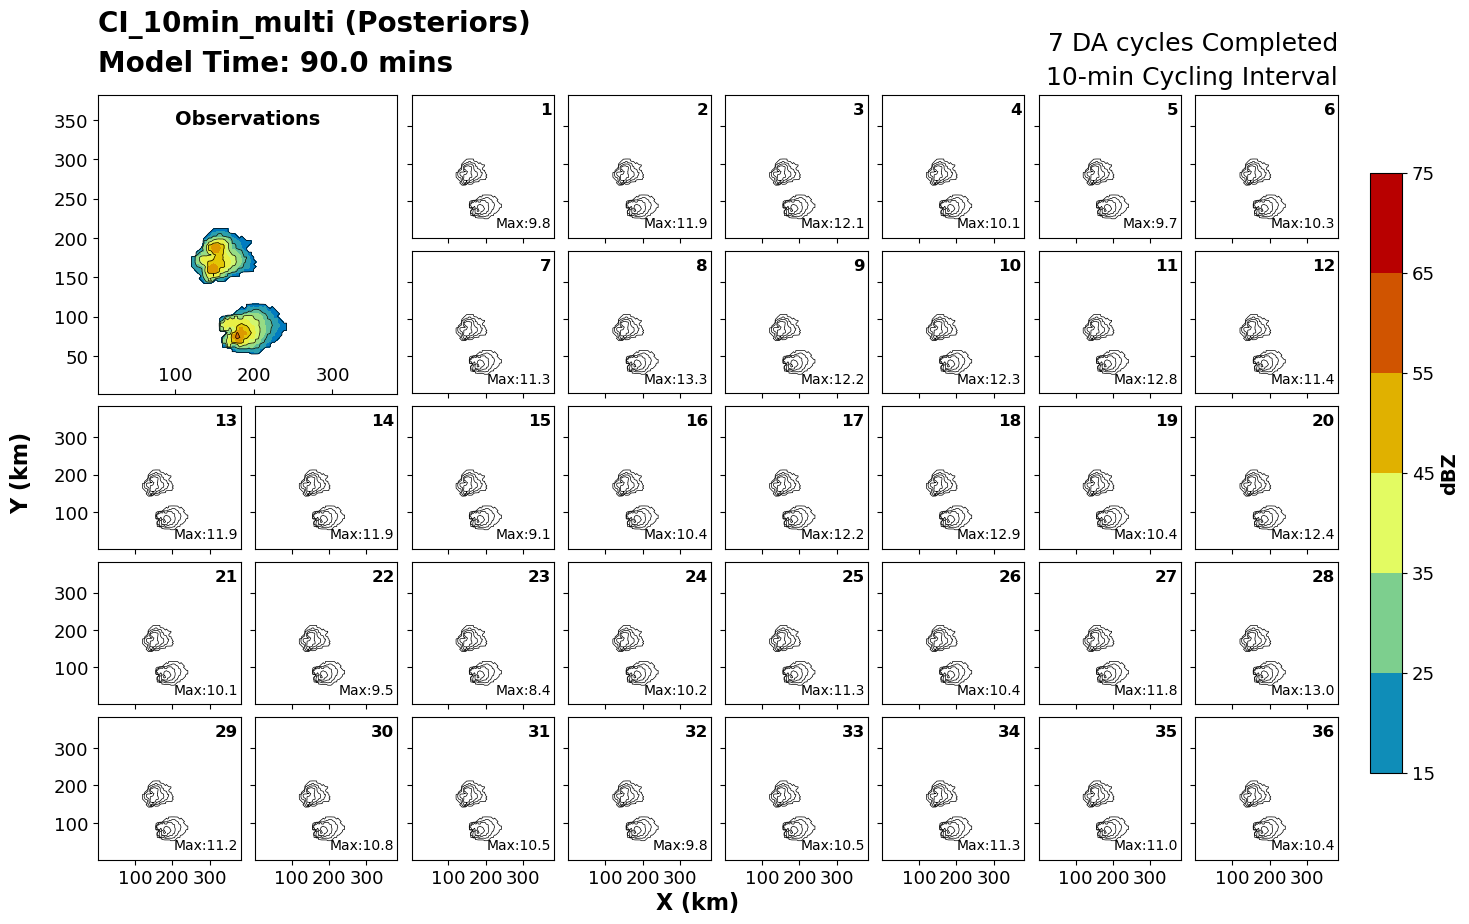

In [232]:

ne = ens_state.ne
height = 2 # in km
cref = True
include_obs = True
plot_width = 230#280#220 # in km 
smooth_obs = False

fig, axes = plt.subplots(5,8, sharex=True, sharey=True, figsize=(16,10), subplot_kw={'aspect':'equal'})
gs = axes[0,1].get_gridspec()
for ax in [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]:
    ax.remove()

axbig = fig.add_subplot(gs[0:2, 0:2])
axbig.set_aspect('equal')
axbig.tick_params(axis="x", direction="in", pad=-20)

ax_list = []# axes.flatten
for n,ax in enumerate(axes.flatten()):
    if n not in [0,1,8,9]:
        ax_list.append(ax)


x = ens_state.xc[:]/1000
y = ens_state.yc[:]/1000
z = ens_state.zc[:]/1000

zi = findnearest(z, height) # if cref is chosen, this isn't used
# prepping the observations
if include_obs == True:
    obs_3d = ens.ens_GRID_RELECTIVITY(ens_state, cref=cref) 
    if cref == True: obs = obs_3d[0]
    else: obs = obs_3d[zi] # this data is interpolated to the model grid, so this is okay to index with zi
    if smooth_obs: obs = gaussian_filter(obs, sigma=.5)

    smth = gaussian_filter(obs, sigma=12)
    yc, xc = np.where(smth == smth.max())

    yy,xx = np.where(obs>5)
    xc = np.min(xx)+int((np.max(xx) - np.min(xx))/2)
    yc = np.min(yy)+int((np.max(yy) - np.min(yy))/2)

else:
    # full_field = ens_state['DBZ'][:].sum(axis=(0,1))
    # smth = gaussian_filter(ens_state['DBZ'][-1,:].max(axis=1), sigma=12)
    # yc, xc = np.where(full_field == full_field.max())

    yy,xx = np.where(ens_state['DBZ'][-1].max(axis=0)>5)
    xc = np.min(xx)+int((np.max(xx) - np.min(xx))/2)
    yc = np.min(yy)+int((np.max(yy) - np.min(yy))/2)



print(yc, xc)

# if plot_width!= None:
#     axes[-1,-1].set_xlim(x[xc]-plot_width/2, x[xc]+plot_width/2) # shift plot 20 km to the right, it just looks better
#     axes[-1,-1].set_ylim(y[yc]-plot_width/2, y[yc]+plot_width/2)
#     axbig.set_xlim(x[xc]-plot_width/2, x[xc]+plot_width/2) 
#     axbig.set_ylim(y[yc]-plot_width/2, y[yc]+plot_width/2)


### obs
if include_obs:
    axbig.contourf(x,y, obs, cmap=ctables.REF_default, levels=np.arange(15,80,5))
    axbig.contour(x,y, obs, colors='k', linewidths=0.5, levels=np.arange(15,80,10))
    axbig.text(0.5, .95, 'Observations', ha='center', va='top', fontsize=14, weight='bold', transform=axbig.transAxes)
else:
    if cref == True: mean_field = ens_state['DBZ'][-1,:].max(axis=0) 
    else: mean_field = ens_state['DBZ'][-1,zi] 
    
    axbig.contourf(x,y, mean_field, cmap=ctables.REF_default, levels=np.arange(15,80,5))
    axbig.contour(x,y, mean_field, colors='k', linewidths=0.5, levels=np.arange(15,80,10))
    axbig.text(0.5, .95, 'Ensemble Mean', ha='center', va='top', fontsize=14, weight='bold', transform=axbig.transAxes)


for i,ax in enumerate(ax_list):
    #i=i+24
    if cref == True: dbz = ens_state['DBZ'][i,:].max(axis=0) 
    else: dbz = ens_state['DBZ'][i,zi] 
    
    im=ax.contourf(x,y, dbz, cmap=ctables.REF_default, levels=np.arange(15,80,10)) 
    #ax.contourf(x,y, dbz, colors=['C0'], levels=[5,100]) 

    if include_obs:
        ax.contour(x,y, obs, colors='k', levels=np.arange(15,80,10), linewidths=0.5)
    ax.text(0.98, .05, f'Max:{dbz.max():.1f}', va='bottom',ha='right', fontsize=10, transform=ax.transAxes)
    ax.text(0.98, .95, f'{i+1}', ha='right', va='top',fontsize=12, transform=ax.transAxes, weight='bold')

plt.subplots_adjust(hspace = .05 ,wspace = .1)

cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('dBZ', weight='bold')


fig.text(0.5, 0.07, 'X (km)', ha='center', va='center', weight='bold', fontsize=16);
fig.text(0.07,0.5, r'Y (km)', weight='bold', va='center', fontsize=16, rotation='vertical');

freq = ens_state['experiment']['DA_PARAMS']['assim_freq']
da_start = dt.datetime.strptime(ens_state['experiment']['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')
da_end = dt.datetime.strptime(ens_state['experiment']['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')
curr_time = ens_state['datetime'][0]

text='(Posteriors)'
if PRIOR:text = '(Priors)'
    
if curr_time > da_end:
    ncycles = 1 + int((da_end - da_start).seconds/freq)
    forecast_len = int((curr_time - da_end).seconds/60)
    text_add = (f'; {forecast_len}-min Forecast')
    text=''
else:
    ncycles = 1 + int(np.floor((curr_time - da_start).seconds/freq))
    text_add = ''

    if PRIOR: ncycles -=1
    
start = dt.datetime.strptime(ens_state['experiment']['date_time'], '%Y-%m-%d %H:%M:%S')

model_time = (curr_time - start).seconds/60
title = f'{name} {text}\nModel Time: {model_time} mins{text_add}'
axbig.set_title(title, fontsize=20, x=0, ha='left', weight='bold', y=1.05, linespacing=1.5);

title2 = f'{ncycles} DA cycles Completed\n{int(freq/60)}-min Cycling Interval'
axes[0,7].set_title(title2, linespacing=1.5, ha='right', x=1, y=1.02);

In [ ]:


# analysis look

# Creating Ensemble mean files for forecast (put in base dir)

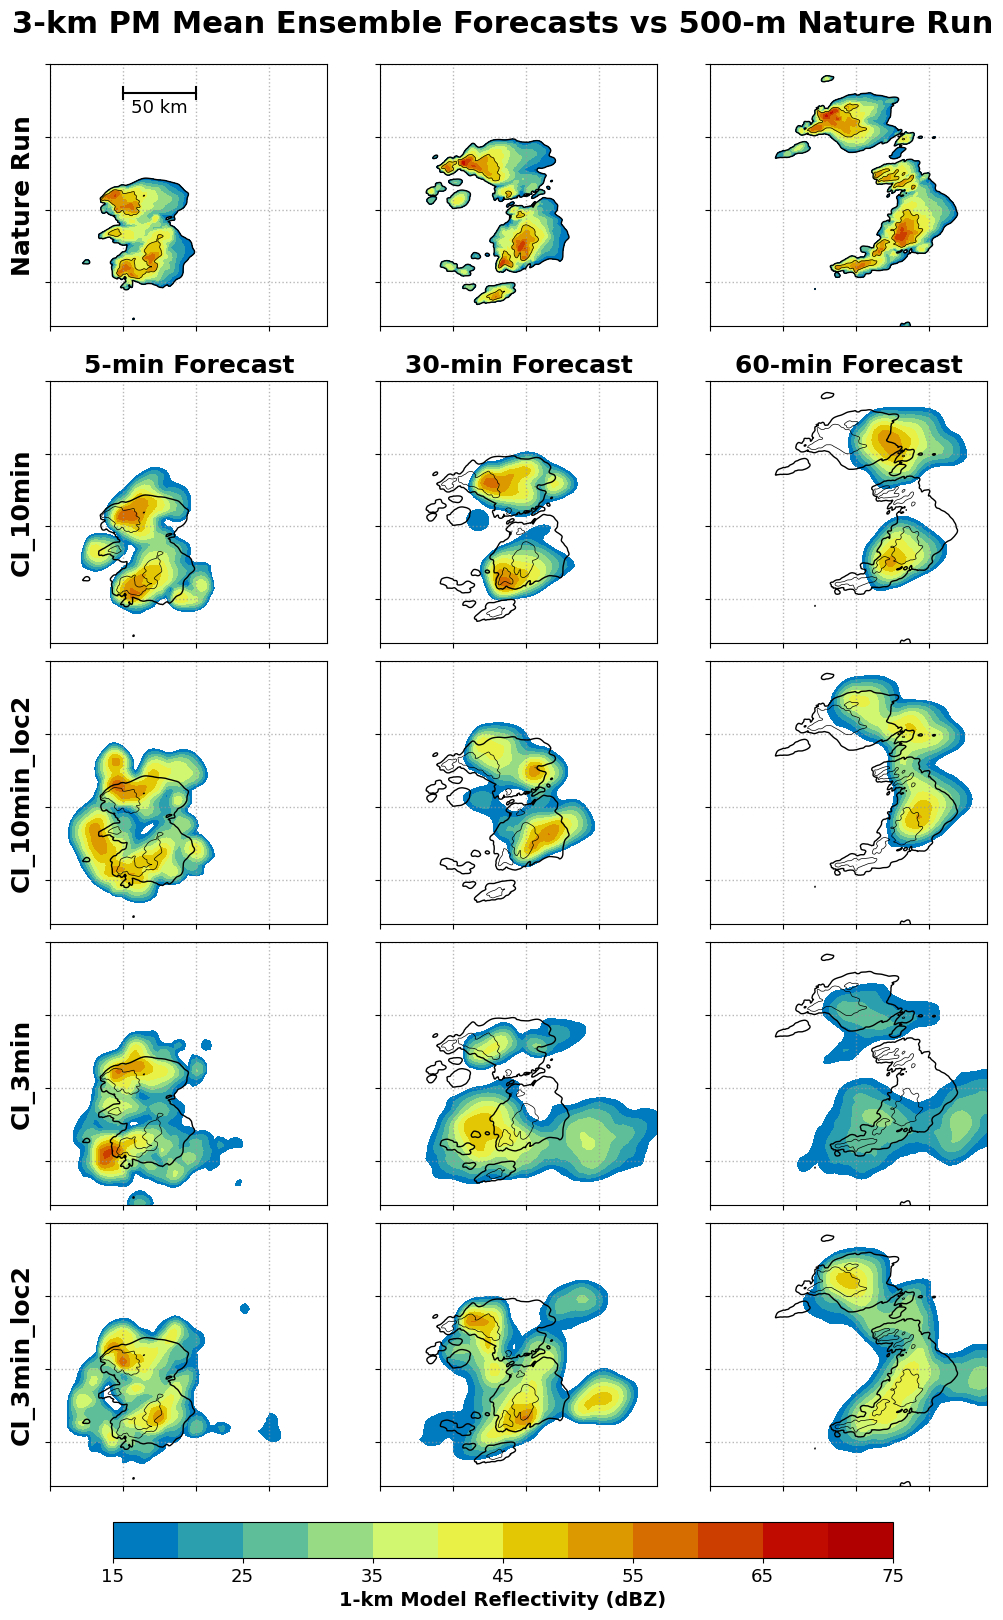

In [9]:
fig, axes = plt.subplots(5,3, figsize=(13, 18), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

times = [dt.datetime(2024,5,8,21,35), dt.datetime(2024,5,8,22), dt.datetime(2024,5,8,22,30)]
exps = ['CI_15min', 'CI_10min', 'CI_5min', 'CI_3min']
exps = ['CI_10min', 'CI_10min_loc2', 'CI_3min','CI_3min_loc2']

height = 1 # km

# get info for nature run
with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exps[0]}/{exps[0]}.exp', 'rb') as f: exper = json.load(f)
start = dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
fcst_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')

for ni, exp in enumerate(exps):
    cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc')
    cm1t = [pd.Timestamp(t) for t in cm1.time.values ]

    xh, yh, z = cm1.xh.values, cm1.yh.values, cm1.z.values

    axes[ni+1, 0].set_ylabel(exp, fontsize=18)

    for ti,time in enumerate(times):
        cti = findnearest(cm1t, time)
        axes[ ni+1, ti].contourf(xh, yh, cm1.dbz[cti,-1, findnearest(z, height)],  cmap=ctables.REF_default, levels=np.arange(15,80,5))
        
        fcst_len = int((time - fcst_start).seconds/60)
        if ni == 0:
            axes[ni+1, ti].set_title(f'{fcst_len}-min Forecast', weight='bold')
    cm1.close()

for ti,time in enumerate(times):
    tt = int((time-start).seconds/60)-10
    NR = xr.open_dataset(f'/scratch/home/jessica.mcdonald/NR_500m_may8/cm1out_{tt:06d}.nc', decode_timedelta=True)
    im=axes[0, ti].contourf(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)],  cmap=ctables.REF_default, levels=np.arange(15,80,5))
    for ax in axes[:, ti]:
        ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[15], linewidths=1)
        ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[45], linewidths=0.5)
    NR.close()
axes[0,0].set_ylabel('Nature Run', fontsize=18)

for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

# add in length scale
axes[0,0].plot([200,250], [280,280], color='k')
axes[0,0].plot([200,200], [276,284], color='k')
axes[0,0].plot([250,250], [276,284], color='k')
axes[0,0].text(225, 276, '50 km', ha='center', va='top', fontsize=13)

cbar_ax = fig.add_axes([0.2, 0.07, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('1-km Model Reflectivity (dBZ)', weight='bold')
plt.subplots_adjust(wspace=0.2, hspace=0.3)

# set limits and adjust plot
axes[0,0].set_xlim(150, 340)
axes[0,0].set_ylim(120, 300)
plt.subplots_adjust(hspace=0.07, wspace=-0.05)


for ax in axes[0,:]:
    pos = ax.get_position()
    pos.y0 = pos.y0 +.02
    pos.y1 = pos.y1 +.02
    ax.set_position(pos)
fig.canvas.draw()

#fig.suptitle('3-km Ensemble Mean Forecasts vs 1-km Nature Run', y=.93, fontsize=20, weight='bold');

fig.suptitle('3-km PM Mean Ensemble Forecasts vs 500-m Nature Run', y=.93, fontsize=22, weight='bold');

In [3]:
exps = [ 'CI_3min_multi', 'CI_3min_R05_multi']

exp = exps[0]



In [34]:
probs

In [20]:
NR = xr.open_dataset(f'/scratch/home/jessica.mcdonald/NR_500m_may8/Processed_VerificationVars.nc', decode_timedelta=True)
NRdates = [pd.to_datetime(NRt) for NRt in NR.dates.values]

In [37]:
raw_probs(cm1['dbz'][cti, :-1].values, 25, ensN)

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [62]:
exps[0]

'CI_10min'

In [65]:
exps[0].find('min') > 0

True

In [69]:
glob.glob(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc")[0]

IndexError: list index out of range

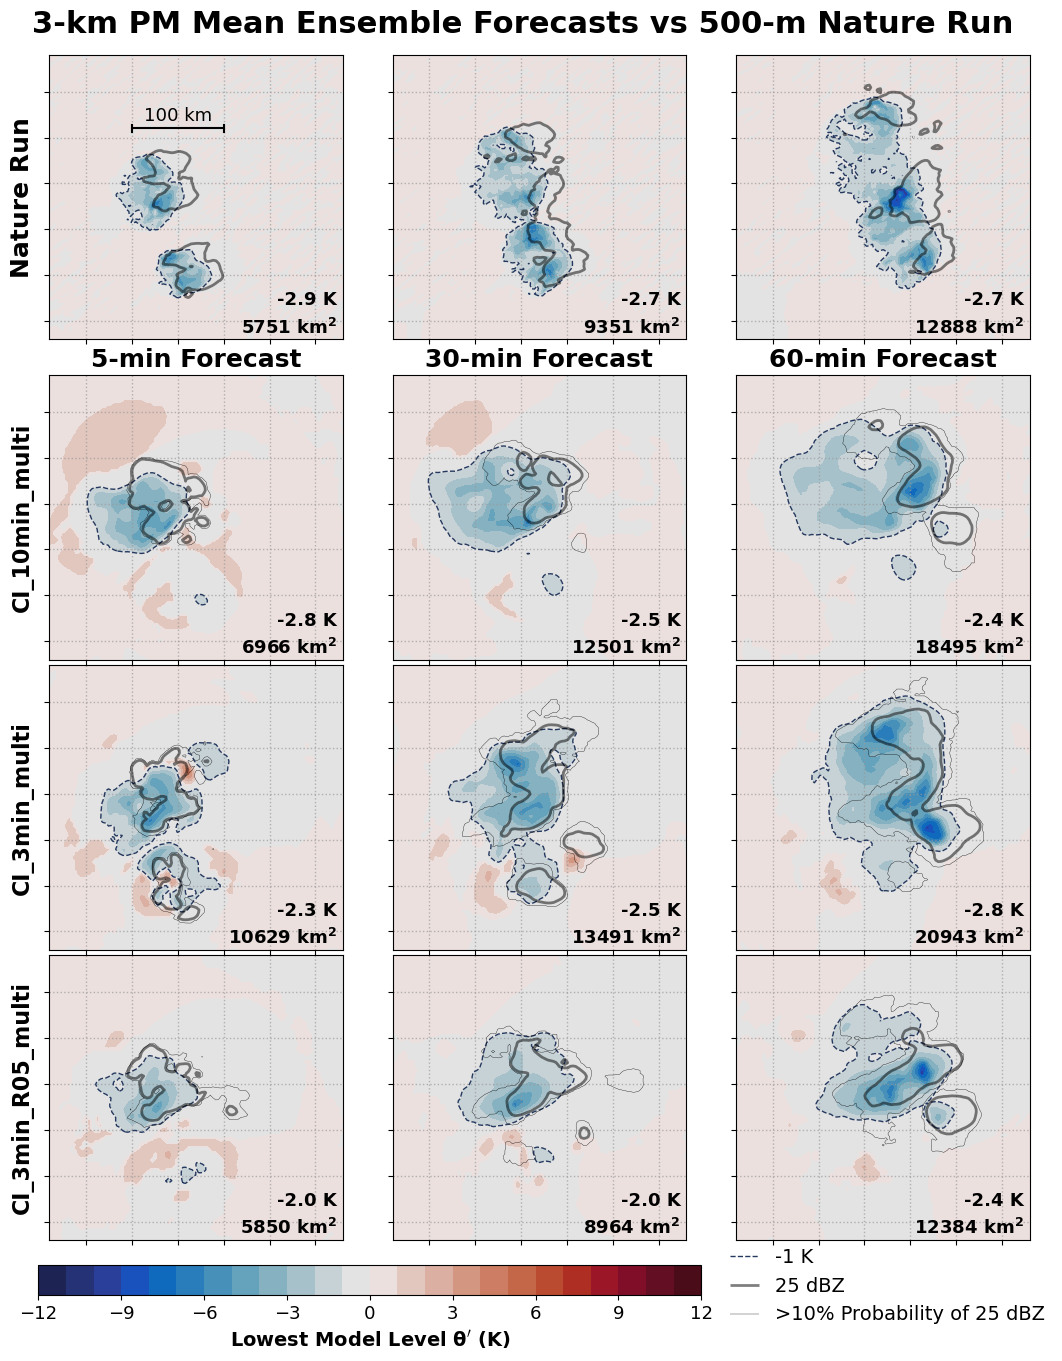

In [5]:

##############################################################################

exps = [ 'CI_10min', 'CI_3min', 'CI_3min_R05']
exps = [ 'CI_10min_multi', 'CI_3min_multi', 'CI_3min_R05_multi']


##############################################################################

if len(exps)==4:
    fig, axes = plt.subplots(5,3, figsize=(13, 18), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
if len(exps)==3:
    fig, axes = plt.subplots(4,3, figsize=(13, 15), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
if len(exps)==2:
    fig, axes = plt.subplots(3,3, figsize=(13, 15), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})


# get info for nature run
with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exps[0]}/letkf.exp', 'rb') as f: exper = json.load(f)
start = dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
fcst_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')

fcst_lens = [5,30,60]
times = [fcst_start + dt.timedelta(minutes=tt) for tt in fcst_lens]

# read in nature run 
add = ''
if exps[0].find('multi') > 0: add='extra_'
NR = xr.open_dataset(f'/scratch/home/jessica.mcdonald/{add}NR_500m_may8/Processed_VerificationVars.nc', decode_timedelta=True)
NRdates = [pd.to_datetime(NRt) for NRt in NR.dates.values]


for ni, exp in enumerate(exps):

    
    #fpath = glob.glob(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/FORECAST*/full_ens_fcst.nc")[0]
    fpath = glob.glob(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc")[0]
    cm1 = xr.open_dataset(fpath, decode_timedelta=True)
    
    cm1t = [pd.Timestamp(t) for t in cm1.time.values]
    xh, yh, z, ensN = cm1.xh.values, cm1.yh.values, cm1.z.values, int(cm1.ne.max()) 

    
    # name of experiment
    axes[ni+1, 0].set_ylabel(exp, fontsize=16)

    for ti,time in enumerate(times):
        
        cti = findnearest(cm1t, time)
        ens_pmm = pmm(cm1, 'th', 0, cti)
        thp = (ens_pmm - ens_pmm[:,-1].mean())
    
        axes[ ni+1, ti].contourf(xh, yh, thp,  cmap=cmaps.balance, levels=np.arange(-12, 12.1, 1))
        tim = axes[ ni+1, ti].contour(xh, yh, thp, colors='#25395e',linestyles='--', levels=[-1], linewidths=1)


        #now add probability of prcip
        probs = raw_probs(cm1['dbz'][cti, :-1,0].values, 25, ensN)
        pim = axes[ ni+1, ti].contour(xh, yh, probs*100,  colors='k',linewidths=0.25, levels=[10])

        dbz_pmm = pmm(cm1, 'dbz', 0, cti)
        dim = axes[ ni+1 ,ti].contour(xh, yh, dbz_pmm, colors='k', levels=[25], linewidths=2, alpha=0.5)

        # cold pool stats
        mean_temp = np.mean(thp[thp <= -1])
        cp_size = np.count_nonzero(thp <= -1)*(3*3)

        axes[ ni+1, ti].text(0.98, 0.02, f"{cp_size:.0f} km"+r'$\mathbf{^2}$', ha='right',fontsize=13, weight='bold', transform=axes[ ni+1, ti].transAxes)
        axes[ ni+1, ti].text(0.98, 0.12, f"{mean_temp:.1f} K", ha='right',fontsize=13, weight='bold', transform=axes[ ni+1, ti].transAxes)

        
        fcst_len = int((time - fcst_start).seconds/60)
        if ni == 0:
            axes[ni+1, ti].set_title(f'{fcst_len}-min Forecast', weight='bold')
            
        cm1.close()

for ti,time in enumerate(times):

    thp = NR.th[findnearest(NRdates, time),0].values -  NR.th[findnearest(NRdates, time),0,:,-1].values.mean(axis=0)
    
    im=axes[0, ti].contourf(xh, yh, thp,  cmap=cmaps.balance, levels=np.arange(-12, 12.1, 1))
    axes[0, ti].contour(xh, yh, thp, colors='#25395e',linestyles='--', levels=[ -1], linewidths=1)
   
    mean_temp = np.mean(thp[thp <= -1])
    cp_size = np.count_nonzero(thp <= -1)*(3*3)#(.5*.5)
    
    axes[0, ti].text(0.98, 0.12, f"{mean_temp:.1f} K", ha='right',fontsize=13, weight='bold', transform=axes[ 0, ti].transAxes)
    axes[0, ti].text(0.98, 0.02,f"{cp_size:.0f} km"+r'$\mathbf{^2}$', ha='right',fontsize=13, weight='bold', transform=axes[ 0, ti].transAxes)
   
    NR.close()

    for ax in [axes[0, ti]]:
        ax.contour(xh, yh, NR.dbz[findnearest(NRdates, time),0], colors='k', levels=[25], linewidths=2, alpha=0.5)
        
    
axes[0,0].set_ylabel('Nature Run', fontsize=18)

for ax in axes.flatten():
    ax.set_xticks(np.arange(0, 400, 50),np.arange(0, 400, 50))
    ax.set_yticks(np.arange(0, 400, 50),np.arange(0, 400, 50))
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

# add in length scale
add_scale(axes[0,0], xstart=150, xlength=100, y=260)


if len(exps) == 4:
    cbar_box = [0.127, 0.073, 0.51, 0.02]
    wspace, hspace = 0.07, 0.01
    legend_bbox = (.78, 0.05)


if (len(exps) == 3) |( (len(exps)==2)):
    cbar_box = [0.127, 0.073, 0.51, 0.02]
    wspace, hspace = 0.07, 0.02
    legend_bbox = (.78, 0.042)

cbar_ax = fig.add_axes(cbar_box)
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label(r'Lowest Model Level $\mathbf{\theta^{\prime}}$ (K)', weight='bold')

h0, _ = tim.legend_elements()
h1, _ = dim.legend_elements()
h2, _ = pim.legend_elements()

fig.legend(h0+h1+h2, ['-1 K', '25 dBZ', '>10% Probability of 25 dBZ'], fontsize=14, loc='lower center', 
           bbox_to_anchor = legend_bbox, handlelength=1.5, frameon=False) #bbox_to_anchor = (.78, 0.058)

# set limits and adjust plot
axes[0,0].set_xlim(100-40, 380-40)
axes[0,0].set_ylim(90+20, 320+20)

axes[0,0].set_xlim(100-40, 380)
axes[0,0].set_ylim(30, 320+20)

plt.subplots_adjust(hspace=hspace, wspace=wspace)

for ax in axes[0,:]:
    pos = ax.get_position()
    pos.y0 = pos.y0 +.02
    pos.y1 = pos.y1 +.02
    ax.set_position(pos)
fig.canvas.draw()

fig.suptitle('3-km PM Mean Ensemble Forecasts vs 500-m Nature Run', y=.93, fontsize=22, weight='bold');


In [60]:
add

'extra_'

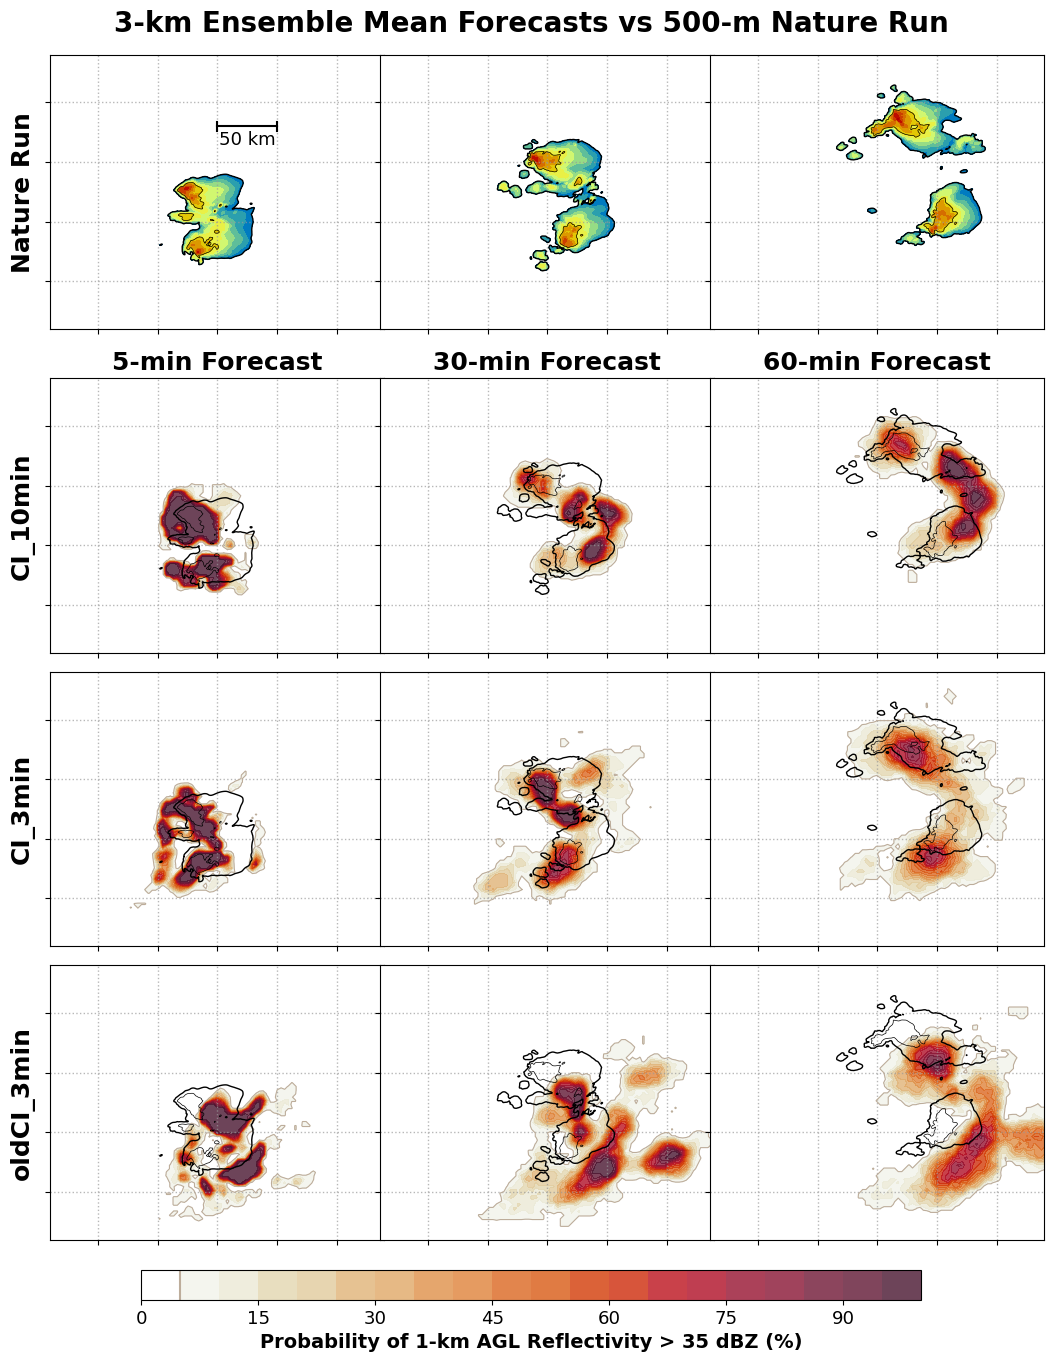

In [66]:

exps = ['CI_15min', 'CI_10min', 'CI_5min', 'CI_3min']
exps = ['CI_3min_err', 'CI_3min_inlier', 'CI_3min']

exps = [ 'CI_3min', 'CI_3min_err','CI_3min_err_inlier', 'CI_3min_inlier',]
exps = [ 'CI_5min', 'CI_5min_err','CI_3min', 'CI_3min_err',]
exps = ['CI_10min','CI_3min', 'oldCI_3min']

#exps = ['CI_3min_loc2','CI_3min_RTPP_05_loc2', 'CI_3min_60', 'CI_3min_60_RTPP05']


if len(exps)==4:
    fig, axes = plt.subplots(5,3, figsize=(13, 18), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
if len(exps)==3:
    fig, axes = plt.subplots(4,3, figsize=(13, 15), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

times = [dt.datetime(2024,5,8,21,35), dt.datetime(2024,5,8,22), dt.datetime(2024,5,8,22,30)]

height = 1   # km
threshold=35 # dbz

#cmap = concat([])

cmap_b = cmaps.sunburst_r.cut(.2, 'right')
clist = [to_rgb('#ffffff')]
clist.extend(cmap_b(np.linspace(0,1,49)))
cmap1 = LinearSegmentedColormap.from_list("CR", clist, 30)



# get info for nature run
with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exps[0]}/letkf.exp', 'rb') as f: exper = json.load(f)
start = dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')
fcst_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')

for ni, exp in enumerate(exps):
    cm1 = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc", decode_timedelta=True)
    cm1t = [pd.Timestamp(t) for t in cm1.time.values ]

    xh, yh, z = cm1.xh.values, cm1.yh.values, cm1.z.values
    ensN = int(cm1.ne.max()) #this is zero based, so it excludes the mean which is the final member


    axes[ni+1, 0].set_ylabel(exp, fontsize=18)

    for ti,time in enumerate(times):
        cti = findnearest(cm1t, time)
        dbz_field = cm1['dbz'][cti, :-1, findnearest(z, height)].values
        probs = np.zeros_like(dbz_field)
        probs[dbz_field >= threshold] = 1
        
        probs = probs.sum(axis=0)/ensN
        im = axes[ ni+1, ti].contourf(xh, yh, probs*100,  cmap=cmap1, levels=np.arange(0, 105, 5), alpha=0.8)
        axes[ni+1, ti].contour(xh, yh, probs*100,  colors='#bdad9b', levels=[5], linewidths=0.8)
        
        fcst_len = int((time - fcst_start).seconds/60)
        if ni == 0:
            axes[ni+1, ti].set_title(f'{fcst_len}-min Forecast', weight='bold')
    cm1.close()

for ti,time in enumerate(times):
    tt = int((time-start).seconds/60)-10
    NR = xr.open_dataset(f'/scratch/home/jessica.mcdonald/NR_500m_may8/cm1out_{tt:06d}.nc', decode_timedelta=True)
    axes[0, ti].contourf(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)],  cmap=ctables.REF_default, levels=np.arange(15,80,5))
    for ax in axes[:, ti]:
        ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[15], linewidths=1)
        ax.contour(NR.xh, NR.yh, NR.dbz[0,findnearest(NR.zh, height)], colors='k', levels=[45], linewidths=0.5)
    NR.close()
axes[0,0].set_ylabel('Nature Run', fontsize=18)

for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

# add in length scale
axes[0,0].plot([200,250], [280,280], color='k')
axes[0,0].plot([200,200], [276,284], color='k')
axes[0,0].plot([250,250], [276,284], color='k')
axes[0,0].text(225, 276, '50 km', ha='center', va='top', fontsize=13)

cbar_ax = fig.add_axes([0.2, 0.07, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Probability of 1-km AGL Reflectivity > 35 dBZ (%)', weight='bold')
cbar.ax.axvline(5,color='#bdad9b' )

plt.subplots_adjust(wspace=0.2, hspace=0.3)

# set limits and adjust plot
# axes[0,0].set_xlim(150, 380)
# axes[0,0].set_ylim(90, 300)

axes[0,0].set_xlim(100-40, 380-40)
axes[0,0].set_ylim(90+20, 320+20)

plt.subplots_adjust(hspace=0.07, wspace=-0.05)


for ax in axes[0,:]:
    pos = ax.get_position()
    pos.y0 = pos.y0 +.02
    pos.y1 = pos.y1 +.02
    ax.set_position(pos)
fig.canvas.draw()

fig.suptitle('3-km Ensemble Mean Forecasts vs 500-m Nature Run', y=.93, fontsize=20, weight='bold');



In [58]:
start

datetime.datetime(2024, 5, 8, 19, 30)

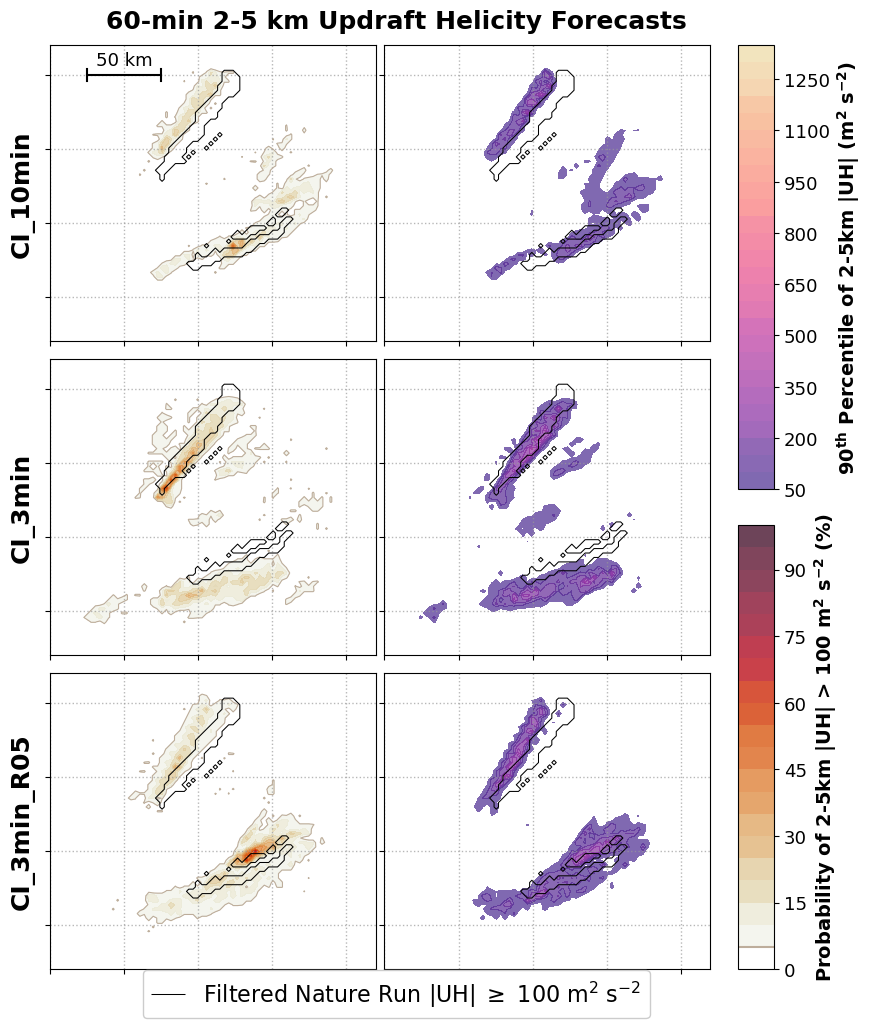

In [105]:



#

time = dt.datetime(2024,5,8,21,35)

exps = ['CI_10min', 'CI_3min','CI_3min_R05']

#exps = [ 'CI_3min_multi', 'CI_3min_R05_multi']


if len(exps) == 4:
    fig, axes = plt.subplots(4,2, figsize=(8.5, 15), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
if len(exps) == 3:
    fig, axes = plt.subplots(3,2, figsize=(9, 12), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
    
if len(exps) == 2:
    fig, axes = plt.subplots(2,2, figsize=(12, 12), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
    
height = 1   # km
threshold=100 # m2 s-2


cmap_b = cmaps.agsunset#.cut(.2, 'right')
clist = []
clist.extend(cmap_b(np.linspace(0,1,7)))
cmap2 = LinearSegmentedColormap.from_list("CR", clist, 30)

# get info for nature run
with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exps[0]}/letkf.exp', 'rb') as f: exper = json.load(f)
start = dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')

#fcst_start = dt.datetime.strptime(exper['DA_PARAMS'['DA_end_time'], '%Y-%m-%d %H:%M:%S')


cmap_b = cmaps.sunburst_r.cut(.2, 'right')
clist = [to_rgb('#ffffff')]
clist.extend(cmap_b(np.linspace(0,1,49)))
cmap1 = LinearSegmentedColormap.from_list("CR", clist, 30)



for ni, exp in enumerate(exps):
    #fpath = glob.glob(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/FORECAST*/full_ens_fcst.nc")[0]
    fpath = glob.glob(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc")[0]
    cm1 = xr.open_dataset(fpath, decode_timedelta=True)
    cm1t = [pd.Timestamp(t) for t in cm1.time.values ]

    xh, yh, z = cm1.xh.values, cm1.yh.values, cm1.z.values
    ensN = int(cm1.ne.max()) #this is zero based, so it excludes the mean which is the final member

    axes[ni, 0].set_ylabel(exp, fontsize=18)

    UH = abs(cm1['UH_2-5km'][:,:-1].values) # drop 
    UH_90 = np.max(np.percentile(UH, 90, axis=1), axis=0)
    
    probs = np.zeros_like(UH)
    probs[UH >= threshold] = 1
    
    probs = probs.sum(axis=1)
    probs = probs.max(axis=0)/ensN


    im1=axes[ni, 0].contourf(xh, yh, probs*100,  cmap=cmap1, levels=np.arange(0, 105, 5), alpha=0.8)
    axes[ni, 0].contour(xh, yh, probs*100,  colors='#bdad9b', levels=[5], linewidths=0.8)
    im2=axes[ni, 1].contourf(xh, yh, UH_90,  cmap=cmap2, levels=np.arange(50, 1400, 50), alpha=0.7)

    cm1.close()

### add in nature run stuff
NR = xr.open_dataset('/scratch/home/jessica.mcdonald/NR_500m_may8/Processed_VerificationVars.nc')
#NR = xr.open_dataset('/scratch/home/jessica.mcdonald/extra_NR_500m_may8/Processed_VerificationVars.nc')
#threshold = 1000

##### nature run is only off by FIVE MINUTES, not 10! DA starts at 25 mins for Nature Run and 30 mins for ensemble
t0 = findnearest(int((cm1t[0]-start).seconds/60)-5, NR.time.values)
t1 = findnearest(int((cm1t[-1]-start).seconds/60)-5, NR.time.values)+1

NRuh =abs(NR['UH2-5km'][t0:t1].values)

temp=np.zeros_like(NRuh)
temp[NRuh >=threshold] = 1
NR_UH = np.clip(temp.sum(axis=0), 0, 1)
# NR_UH = gaussian_filter(NR_UH, 1)




Nxh, Nyh = NR.xh.values, NR.yh.values

for ax in axes.flatten():
    im=ax.contour(Nxh, Nyh, NR_UH, levels=[0.5], colors='k', linewidths=0.75)

    ax.set_yticks(np.arange(50, 400, 50))
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())
    
    #ax.set_xlim(150, 370)
    ax.set_xlim(150-50, 370-50)
    ax.set_ylim(100+20,300+20)

    # ax.set_xlim(85, 340)
    # ax.set_ylim(100+20,300)
    
    
NR.close()

plt.subplots_adjust(hspace=0.06, wspace=-0.08)

cbar_ax1 = fig.add_axes([0.91, 0.11, 0.04, 0.37])
cbar1 = fig.colorbar(im1, cax=cbar_ax1)
cbar1.set_label(f'Probability of 2-5km |UH| > {threshold} '+ r'm$\mathbf{^2}$ s$\mathbf{^{-2}}$ (%)', weight='bold')
cbar1.ax.axhline(5,color='#bdad9b' )

cbar_ax2 = fig.add_axes([0.91, 0.51, 0.04, 0.37])
cbar2 = fig.colorbar(im2, cax=cbar_ax2)
cbar2.set_label('90$\mathbf{^{th}}$ Percentile of 2-5km |UH| (m$\mathbf{^2}$ s$\mathbf{^{-2}}$)', weight='bold')

plt.draw()
flen = int((cm1t[-1]-cm1t[0]).seconds/60)
if flen==55: flen=60 # fix the start issue with the final forecast
fig.suptitle(f'{flen}-min 2-5 km Updraft Helicity Forecasts', y=.90, x=.53, fontsize=18, weight='bold', va='center');

h, _ = im.legend_elements()
l = [r'Filtered Nature Run |UH| $\geq$ '+f'{threshold}'+r' m${^2}$ s${^{-2}}$']
leg=fig.legend(h, l, loc='lower center', fontsize=16, handlelength=1.5, bbox_to_anchor=(0.53,0.06))

#add_scale(axes[0,0], xstart=290,y=270)
#add_scale(axes[0,0], xstart=125,y=320)
add_scale(axes[0,0], xstart=125,y=300)

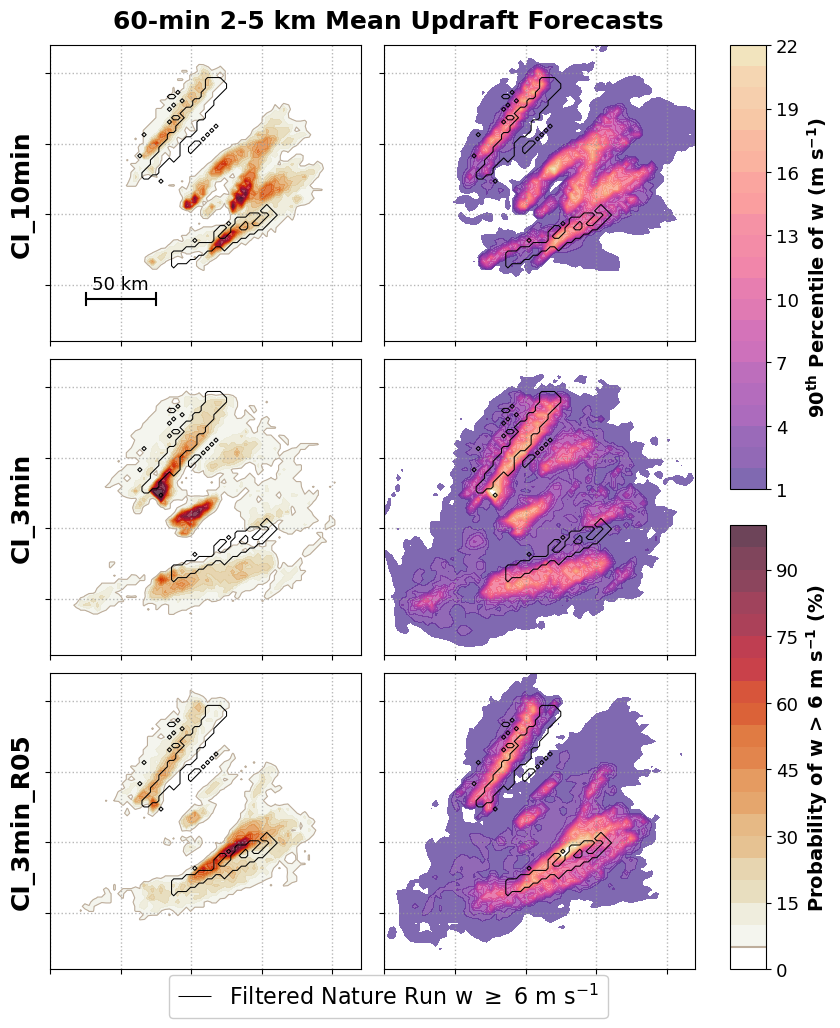

In [3]:



#

time = dt.datetime(2024,5,8,21,35)


exps = ['CI_10min', 'CI_3min', 'CI_3min_R05']


if len(exps) == 4:
    fig, axes = plt.subplots(4,2, figsize=(8.5, 15), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
if len(exps) == 3:
    fig, axes = plt.subplots(3,2, figsize=(9, 12), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
    
if len(exps) == 2:
    fig, axes = plt.subplots(2,2, figsize=(12, 12), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})
    
height = 1   # km
threshold=6 # m2 s-2


cmap_b = cmaps.agsunset#.cut(.2, 'right')
clist = []
clist.extend(cmap_b(np.linspace(0,1,7)))
cmap2 = LinearSegmentedColormap.from_list("CR", clist, 30)

# get info for nature run
with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exps[0]}/letkf.exp', 'rb') as f: exper = json.load(f)
start = dt.datetime.strptime(exper['date_time'], '%Y-%m-%d %H:%M:%S')

#fcst_start = dt.datetime.strptime(exper['DA_PARAMS'['DA_end_time'], '%Y-%m-%d %H:%M:%S')


cmap_b = cmaps.sunburst_r.cut(.2, 'right')
clist = [to_rgb('#ffffff')]
clist.extend(cmap_b(np.linspace(0,1,49)))
cmap1 = LinearSegmentedColormap.from_list("CR", clist, 30)



for ni, exp in enumerate(exps):
    #fpath = glob.glob(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/FORECAST*/full_ens_fcst.nc")[0]
    fpath = glob.glob(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc")[0]
    cm1 = xr.open_dataset(fpath, decode_timedelta=True)
    cm1t = [pd.Timestamp(t) for t in cm1.time.values ]

    xh, yh, z = cm1.xh.values, cm1.yh.values, cm1.z.values
    ensN = int(cm1.ne.max()) #this is zero based, so it excludes the mean which is the final member

    axes[ni, 0].set_ylabel(exp, fontsize=18)

    UH = cm1['w'][:,:-1, findnearest(cm1.z, 2):findnearest(cm1.z,5)+1].mean(axis=(2)).values
    UH_90 = np.max(np.percentile(UH, 90, axis=1), axis=0)
    
    probs = np.zeros_like(UH)
    probs[UH >= threshold] = 1
    
    probs = probs.sum(axis=1)
    probs = probs.max(axis=0)/ensN


    im1=axes[ni, 0].contourf(xh, yh, probs*100,  cmap=cmap1, levels=np.arange(0, 105, 5), alpha=0.8)
    axes[ni, 0].contour(xh, yh, probs*100,  colors='#bdad9b', levels=[5], linewidths=0.8)
    im2=axes[ni, 1].contourf(xh, yh, UH_90,  cmap=cmap2, levels=np.arange(1, 23, 1), alpha=0.7)

    cm1.close()

### add in nature run stuff

NR = xr.open_dataset('/scratch/home/jessica.mcdonald/NR_500m_may8/Processed_VerificationVars.nc')


##### nature run is only off by FIVE MINUTES, not 10! DA starts at 20 mins for Nature Run and 30 mins for ensemble
t0 = findnearest(int((cm1t[0]-start).seconds/60)-10, NR.time.values)
t1 = findnearest(int((cm1t[-1]-start).seconds/60)-10, NR.time.values)+1

NRuh =NR['w'][t0:t1,  findnearest(cm1.z, 2):findnearest(cm1.z,5)+1].mean(axis=1).values

temp=np.zeros_like(NRuh)
temp[NRuh >=threshold] = 1
NR_UH = np.clip(temp.sum(axis=0), 0, 1)
# NR_UH = gaussian_filter(NR_UH, 1)




Nxh, Nyh = NR.xh.values, NR.yh.values

for ax in axes.flatten():
    im=ax.contour(Nxh, Nyh, NR_UH, levels=[0.5], colors='k', linewidths=0.75)

    ax.set_yticks(np.arange(50, 400, 50))
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())
    

    ax.set_xlim(150-50, 370-50)
    ax.set_ylim(110,300+20)

    # ax.set_xlim(85, 340)
    # ax.set_ylim(100+20,300)
    
    
NR.close()

plt.subplots_adjust(hspace=0.06, wspace=-0.08)

cbar_ax1 = fig.add_axes([0.91, 0.11, 0.04, 0.37])
cbar1 = fig.colorbar(im1, cax=cbar_ax1)
cbar1.set_label(f'Probability of w > {threshold} '+ r'm s$\mathbf{^{-1}}$ (%)', weight='bold')
cbar1.ax.axhline(5,color='#bdad9b' )

cbar_ax2 = fig.add_axes([0.91, 0.51, 0.04, 0.37])
cbar2 = fig.colorbar(im2, cax=cbar_ax2)
cbar2.set_label('90$\mathbf{^{th}}$ Percentile of w (m s$\mathbf{^{-1}}$)', weight='bold')

plt.draw()
flen = int((cm1t[-1]-cm1t[0]).seconds/60)
if flen==55: flen=60 # fix the start issue with the final forecast
fig.suptitle(f'{flen}-min 2-5 km Mean Updraft Forecasts', y=.90, x=.53, fontsize=18, weight='bold', va='center');

h, _ = im.legend_elements()
l = [r'Filtered Nature Run w $\geq$ '+f'{threshold}'+r' m s${^{-1}}$']
leg=fig.legend(h, l, loc='lower center', fontsize=16, handlelength=1.5, bbox_to_anchor=(0.53,0.06))

#add_scale(axes[0,0], xstart=290,y=270)
#add_scale(axes[0,0], xstart=125,y=320)

add_scale(axes[0,0], xstart=125,y=140)

In [89]:
np.shape(cm1['w'][:,:-1, findnearest(cm1.z, 2):findnearest(cm1.z,5)+1].mean(axis=(2)).values)

(12, 36, 128, 128)

In [4]:
exp = 'CI_15min'
exps = ['CI_3min']#,'CI_3min', 'CI_3min_RTPP_05','CI_3min_loc2','CI_3min_RTPP_05_loc2', 'CI_3min_err', 'CI_3min_inlier', 'CI_3min_err_inlier','CI_3min_10min','CI_3min_60']
for exp in exps:
    print(exp)
    myfile = glob.glob(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/FORECAST*/full_ens_fcst.nc")[0]
    
    myds = xr.open_dataset(myfile, decode_timedelta=True)
    z = myds.z
    ztop = findnearest(z, 5)
    zbot = findnearest(z, 2)
    
    # note = we are calculating this for the mean member as well
    w        = myds['w'][:, :, zbot:ztop+1].values
    u        = myds['u'][:, :, zbot:ztop+1].values
    v        = myds['v'][:, :, zbot:ztop+1].values
    
    dx  = np.gradient(myds.xh)*1000
    dy  = np.gradient(myds.yh)*1000
    dz  = np.gradient(myds.z)[zbot:ztop+1]*1000
    
    dudy = np.gradient(u, axis=3)/dy
    dvdx = np.gradient(v, axis=4)/dx
    zeta = dvdx-dudy
    
    UH = np.sum(zeta*w*dz[np.newaxis, np.newaxis, :, np.newaxis, np.newaxis], axis=2)
    del u,v,w,dx,dy,dz,dudy, dvdx, zeta
    
    myds['UH_2-5km'] = (('t', 'ne','nj','ni'), UH)
    temp = myds.copy()
    myds.close()
    
    temp = temp.drop_vars(['time', 'xh', 'yh', 'z', 'u', 'w','v', 'dbz', 'pi0', 'th', 'tte', 'qv', 'qc', 'qr', 'qi', 'qs', 'qg', 'qh'])
    temp.to_netcdf(myfile, mode='a')
    del temp

CI_3min


In [11]:
cm1.z[0].values

array(0.1, dtype=float32)

In [20]:
print("MULTI")

exps = ['CI_10min_multi','CI_3min_R05_multi','CI_3min_multi']
colors = cmaps.pride(np.linspace(.2, .8, len(exps)))

var = 'UH_2-5km'
mv = []
db = []
w = []

for i,exp in enumerate(exps):
    #fpath = [f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"]

    # pull in forecast data
    cm1 = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc", decode_timedelta=True)
    times = [pd.to_datetime(t) for t in cm1.time.values]
    #ensN = cm1.sizes['ne']-1
    mv.extend(cm1['UH_2-5km'][:,:-1].values.flatten())
    db.extend(cm1['dbz'][:,:-1].values.flatten())
    w.extend(cm1['w'][:,:-1,findnearest(cm1.z, 2):findnearest(cm1.z, 5)+1].mean(axis=2).values.flatten())

print('UH')   
for val in [50, 100, 150]:
    print(f'{val}, {stats.percentileofscore(mv, val )}')


print('dbz')    
for val in [30, 35, 40, 45, 50]:
    print(f'{val}, {stats.percentileofscore(db, val )}')

print('w')    
for val in [3,4,5,6,7,8,9,10]:
    print(f'{val}, {stats.percentileofscore(w, val )}')


print("NORMAL")

exps = ['CI_10min','CI_3min_R05','CI_3min']
colors = cmaps.pride(np.linspace(.2, .8, len(exps)))

var = 'UH_2-5km'
mv = []
db = []
w = []

for i,exp in enumerate(exps):
    #fpath = [f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"]

    # pull in forecast data
    cm1 = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc", decode_timedelta=True)
    times = [pd.to_datetime(t) for t in cm1.time.values]
    #ensN = cm1.sizes['ne']-1
    mv.extend(cm1['UH_2-5km'][:,:-1].values.flatten())
    db.extend(cm1['dbz'][:,:-1].values.flatten())
    w.extend(cm1['w'][:,:-1,findnearest(cm1.z, 2):findnearest(cm1.z, 5)+1].mean(axis=2).values.flatten())

print('UH')   
for val in [50, 100, 150]:
    print(f'{val}, {stats.percentileofscore(mv, val )}')


print('dbz')    
for val in [30, 35, 40, 45, 50]:
    print(f'{val}, {stats.percentileofscore(db, val )}')

print('w')    
for val in [3,4,5,6,7,8,9,10]:
    print(f'{val}, {stats.percentileofscore(w, val )}')

MULTI
UH
50, 99.87595640582802
100, 99.93596018096547
150, 99.96218269253954
dbz
30, 98.69451359805899
35, 99.08005324071176
40, 99.39406753605249
45, 99.6460687740576
50, 99.82694202904915
w
3, 99.51036241319444
4, 99.622533350815
5, 99.6916029188368
6, 99.74324732650945
7, 99.78501590681664
8, 99.82037485381703
9, 99.84990814585744
10, 99.87601762936438
NORMAL
UH
50, 99.90059652446229
100, 99.95046544958043
150, 99.97128145194347
dbz
30, 98.80385149804502
35, 99.13463130635753
40, 99.41771616849692
45, 99.65172026798145
50, 99.8237392048777
w
3, 99.59369706518855
4, 99.67948536813995
5, 99.73402141052999
6, 99.7748057047526
7, 99.80786641438802
8, 99.83577492796344
9, 99.8604103370949
10, 99.88180089879918


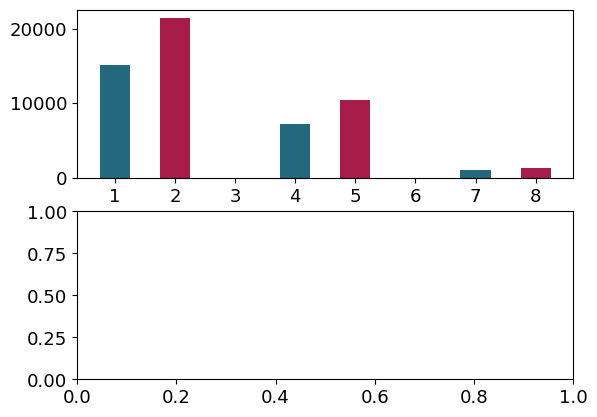

In [31]:


# reflectivity, 30, 45, 60
# counts
fig, axes = plt.subplots(2,1)

exps = ['CI_3min_R05_multi','CI_3min_multi']
colors = cmaps.pride(np.linspace(.2, .8, len(exps)))

for i,exp in enumerate(exps):
    #fpath = [f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"]

    # pull in forecast data
    cm1 = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc", decode_timedelta=True)
    times = [pd.to_datetime(t) for t in cm1.time.values]
    ensN = cm1.sizes['ne']-1

    var = cm1.dbz[:,:-1].max(axis=1)#.values

   
    d30 = np.sum(var>=30)/36#/60
    d45 = np.sum(var>=45)/36#/60
    d60 = np.sum(var>=60)/36#/60
    
    axes[0].bar(1+i, d30, .5, color=colors[i])
    axes[0].bar(4+i, d45, .5, color=colors[i])
    axes[0].bar(7+i, d60, .5, color=colors[i])
    



0.0
0.25
0.5


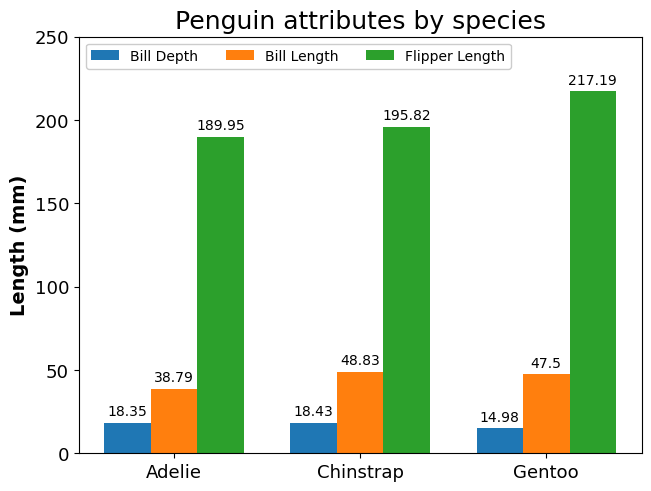

In [25]:
import matplotlib.pyplot as plt
import numpy as np

species = ("Adelie", "Chinstrap", "Gentoo")
penguin_means = {
    'Bill Depth': (18.35, 18.43, 14.98),
    'Bill Length': (38.79, 48.83, 47.50),
    'Flipper Length': (189.95, 195.82, 217.19),
}

# x = np.arange(len(species))  # the label locations
# width = 0.25  # the width of the bars
# multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in penguin_means.items():
    offset = width * multiplier
    print(offset)
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Length (mm)')
ax.set_title('Penguin attributes by species')
ax.set_xticks(x + width, species)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 250)

plt.show()

In [41]:
stats.percentileofscore(abs(NR_UH.flatten()), 100)

np.float64(99.96609157986111)

# Contigency Tables & Performance Diagram

In [118]:
exp ='CI_10min_loc2'

exps = ['CI_3min_R05_multi','CI_3min_multi']#, 'CI_10min']#'CI_3min_RTPP05', 'CI_3min_60', 'CI_3min_60_RTPP05']#'CI_10min_loc2', # do ci 3 loc2 tomorrow

#exps = ['CI_3min_RTPP_05_loc2', 'CI_3min_60', 'CI_3min_60_RTPP05']

ens_threshold = 100 #6# 100 #4 #100#12 #100 # for object indentification
#threshold2 = 100 # for keeping obects to match


# set a threshold for the ENSEMBLE. 


var =  "UH_2-5km"'w'# "UH_2-5km"
name = 'UH'#'w'#'UH'#


for exp in exps[0:1]:
    print(exp)

    fpath = [f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"]
    fpath.extend(glob.glob(fpath[0]+'FORECAST*/'))

    for f in fpath:
        print(f)
    
        # pull in forecast data
        cm1 = xr.open_dataset(f"{f}full_ens_fcst.nc", decode_timedelta=True)
        times = [pd.to_datetime(t) for t in cm1.time.values]
        ensN = cm1.sizes['ne']-1
        
        # pull in verification data!
        ds = xr.open_dataset('/work/jessica.mcdonald/scratch_link/extra_NR_500m_may8/Processed_VerificationVars.nc')
        ds = ds.rename({'UH2-5km':"UH_2-5km"})
        times_NR = [pd.to_datetime(t) for t in ds.dates.values]

        zi,zf = findnearest(ds.zh, 2),findnearest(ds.zh, 5)+1
            
        hits_grid = np.zeros([len(times), ensN])
        miss_grid = np.zeros([len(times), ensN])      
        fa_grid = np.zeros([len(times), ensN])
        pod_grid = np.zeros([len(times)])
        far_grid = np.zeros([len(times)])
        sr_grid = np.zeros([len(times)])

        # now convert threshold for NR to ensemble threshold

        # all times
        time = dt.datetime(times[0].year, times[0].month, times[0].day,times[0].hour, times[0].minute)
        ti = findnearest(times_NR, time)

        if var == 'UH_2-5km':
        
            NR_UH =abs(ds[var][:ti].values)
            NR_threshold = stats.percentileofscore(NR_UH.flatten(), threshold) # this is the percentile of the given threshold for the NR
            
            #all times, all ensemble members
            ens_UH = abs(cm1[var][:,:-1].values)
            #ens_threshold = np.percentile(ens_UH, NRperc)
            print(ens_threshold)


            
        else:
            #NR_UH =(ds[var][:ti, zi].values)
            NR_UH = ds['w'][:ti,zi:zf].mean(axis=(1)).values
            NRperc = stats.percentileofscore(NR_UH.flatten(),threshold) # this is the percentile of the given threshold for the NR
            
            #all times, all ensemble members
            #ens_UH = (cm1[var][:,:-1, zi].values)
            ebs_UH = (cm1['w'][:,:-1,zi:zf].mean(axis=(2)).values)
            ens_threshold = np.percentile(ens_UH, NRperc)
            print(ens_threshold)

        
        for tidx, time in enumerate(times):
            time = dt.datetime(time.year, time.month, time.day,time.hour, time.minute)

                
            # find forecast times
            ti = findnearest(times, time)

            if var == 'UH_2-5km':
            
                UHraw = abs(cm1[var][ti, :-1].values)
                ensN = np.shape(UHraw)[0]
                
                # find verification time
                ti_NR = findnearest(times_NR, time)
                
                NR_UHraw = abs(ds[var][ti_NR,:,:].values)
            else:

                UHraw = (cm1[var][ti,:-1, zi:zf].mean(axis=(2)).values)
                ensN = np.shape(UHraw)[0]
                
                # find verification time
                ti_NR = findnearest(times_NR, time)
                
                NR_UHraw = (ds[var][ti_NR,zi:zf].mean(axis=(1)).values)
            
                            
            ########################### now make table 
            
            # step 1 Values less than X reduced to 0
            
            
            UHraw[UHraw < ens_threshold ] = 0.0
            
            NR_UHraw[NR_UHraw < threshold] = 0.0
            
            # step 2, smooth with gauss filter, stdev=1
            UHsmooth = gaussian_filter(UHraw, 1)
            NR_UHsmooth = gaussian_filter(NR_UHraw, 1)
            
            # step 3, normalize using ratio of max filtered and max raw values
            ratio = np.max(UHraw)/np.max(UHsmooth)
            UHsmooth = UHsmooth*ratio
            
            NRratio = np.max(NR_UHraw)/np.max(NR_UHsmooth)
            NR_UHsmooth = NR_UHsmooth*NRratio
            
            # step 4, convert into objects using threshold and label
            # step 5, filter for max strength and object size (and eccentricity?)
            
            ##### verification objects
            Verif_obj = pd.DataFrame(columns=['area', 'Y0', 'X0', 'coords_scaled', 'coords','eccentricity', 'intensity_max', 'member'])
            labeled_array, num_features = sm.label(NR_UHsmooth>= threshold,connectivity=2,return_num=True)
            OBS = sm.regionprops_table(labeled_array, intensity_image = NR_UHsmooth,spacing=(3.0, 3.0), properties=['area', 'centroid', 'coords_scaled','coords','eccentricity','intensity_max' ])
            df = pd.DataFrame(OBS)
            df = df.rename(columns={'centroid-0':'Y0', 'centroid-1':'X0'})
            ### now drop anything that doesn't have a) eceentricity < 1, b) intensity_max greater than threshold 2, and c) area > 25 m2
            df = df[(df['eccentricity'] < 1.0) & (df['area']>25) & (df['intensity_max'] >= threshold)]
            
            if len(df) > 0:
                Verif_obj = df.copy()
            Verif_obj.reset_index(drop=True, inplace=True)
            
            ##### forecast objects
            Fcst_obj = pd.DataFrame(columns=['area', 'Y0', 'X0', 'coords_scaled', 'coords','eccentricity', 'intensity_max', 'member'])
            for m in np.arange(0, ensN):
            
                labeled_array, num_features = sm.label(UHsmooth[m]>= ens_threshold, connectivity=2,return_num=True)
                OBS = sm.regionprops_table(labeled_array, intensity_image = UHsmooth[m],spacing=(3.0,3.0), properties=['area', 'centroid', 'coords_scaled','coords','eccentricity','intensity_max' ])
                
                df = pd.DataFrame(OBS)
                df['member'] = m+1
                df = df.rename(columns={'centroid-0':'Y0', 'centroid-1':'X0'})
                ### now drop anything that doesn't have a) eceentricity < 1, b) intensity_max greater than threshold 2, and c) area > 25 m2
                df = df[(df['eccentricity'] < 1.0) & (df['area']>25) & (df['intensity_max'] >= ens_threshold)]
                
                if len(df) > 0:
                    Fcst_obj = pd.concat([Fcst_obj, df])
            Fcst_obj.reset_index(drop=True, inplace=True)
            
            # step 6, match objects that are closest and within 40 km of verification object
            
            contingency = pd.DataFrame(data = np.zeros((np.shape(UHraw)[0], 3)), 
                                       index=np.arange(1,  np.shape(UHraw)[0]+1), 
                                       columns = ['hits', 'misses', 'false_alarms'])
            
            # loop over members
            
            # if an object is within 40 km of a verification obj, hit = 1
            # if an object more than 40 km of a verification object, or it is within 40 km of a verification object but another object is closer false_alarm = 1
            # if there is a verification object but not forecast object within 40 km, misses = 1
            # calculate and assign all distances
            for obj in Verif_obj.index:
                Fcst_obj[f'dist_{obj}'] = np.hypot(Fcst_obj.Y0.values - Verif_obj.Y0.values[obj],  Fcst_obj.X0.values - Verif_obj.X0.values[obj])
            
                
            for m in np.arange(0,ensN):
                
                if len(Fcst_obj[Fcst_obj['member']==m]): # there are fcst objects!
                    idxs = Fcst_obj[Fcst_obj['member']==m].index
                    fcst = Fcst_obj[Fcst_obj['member']==m].copy()
                    fcst.reset_index(drop=True, inplace=True)
            
                    fcst['closest'] = 0.0
            
                    # first find hits/misses
                    for obj in Verif_obj.index:
                        closest = int(np.argmin(fcst[f'dist_{obj}']))
                        
                        if fcst.loc[closest, f'dist_{obj}'] <= 40:
                            fcst.loc[closest, 'closest'] = 1.0
                            contingency.loc[m+1, 'hits'] +=1
                        else:
                            contingency.loc[m+1, 'misses'] +=1
                    
                    # then find false alarms = objects that aren't closest to any verification object
                    for i in fcst.index:
                        if fcst.loc[i, 'closest'] == 0.0:
                            contingency.loc[m+1, 'false_alarms'] +=1
            
                else: # there were not fcst objects, so everything is missed 
                    contingency.loc[m+1, 'misses'] += len(Verif_obj)
            
            # step 7, make contigency table! PD and FAR for starters using ALL ensemble members
            a = contingency['hits'].sum()
            b = contingency['false_alarms'].sum()
            c = contingency['misses'].sum()
            
            POD = a/(a+c)
            FAR = b/(a+b)
            Success_Ratio = 1 - FAR
        
            hits_grid[tidx, :] = contingency['hits'].values
            miss_grid[tidx, :] = contingency['misses'].values     
            fa_grid[tidx, :]   = contingency['false_alarms'].values  
            pod_grid[tidx]     = POD
            far_grid[tidx]     = FAR
            sr_grid[tidx]      = Success_Ratio
                        
            
            
            #plt.scatter(Success_Ratio, POD, color='blue', alpha=0.5, s = 60)
        coords = {
                't'    : np.arange(0, len(times)),
                'ne'   : np.arange(0, ensN),}
        
        data_vars = { 
            'time'                     : (['t'],times),
            'hits'                     : (['t','ne'], hits_grid),
            'misses'                   : (['t','ne'], miss_grid),
            'false_alarms'             : (['t','ne'], fa_grid),
            'POD'                      : (['t'], pod_grid),
            'FAR'                      : (['t'], far_grid),
            'S_RATIO'                  : (['t'], sr_grid),}
         
        myds = xr.Dataset(data_vars, coords)
#        myds.attrs['NR100_EnsEquivalent'] = ens_threshold
        #myds.to_netcdf(f'{f}/performance_{name}.nc', format='NETCDF4')


CI_3min_R05_multi
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_R05_multi/
6.967685773371216


/tmp/ipykernel_2824709/2193231930.py:111: RuntimeWarning: invalid value encountered in scalar divide
  ratio = np.max(UHraw)/np.max(UHsmooth)
/tmp/ipykernel_2824709/2193231930.py:114: RuntimeWarning: invalid value encountered in scalar divide
  NRratio = np.max(NR_UHraw)/np.max(NR_UHsmooth)
/tmp/ipykernel_2824709/2193231930.py:198: RuntimeWarning: invalid value encountered in scalar divide
  POD = a/(a+c)
/tmp/ipykernel_2824709/2193231930.py:199: RuntimeWarning: invalid value encountered in scalar divide
  FAR = b/(a+b)
/tmp/ipykernel_2824709/2193231930.py:111: RuntimeWarning: invalid value encountered in scalar divide
  ratio = np.max(UHraw)/np.max(UHsmooth)
/tmp/ipykernel_2824709/2193231930.py:114: RuntimeWarning: invalid value encountered in scalar divide
  NRratio = np.max(NR_UHraw)/np.max(NR_UHsmooth)
/tmp/ipykernel_2824709/2193231930.py:198: RuntimeWarning: invalid value encountered in scalar divide
  POD = a/(a+c)
/tmp/ipykernel_2824709/2193231930.py:199: RuntimeWarning: invalid

CI_3min_multi
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_multi/
6.967685773371216


/tmp/ipykernel_2824709/2193231930.py:111: RuntimeWarning: invalid value encountered in scalar divide
  ratio = np.max(UHraw)/np.max(UHsmooth)
/tmp/ipykernel_2824709/2193231930.py:114: RuntimeWarning: invalid value encountered in scalar divide
  NRratio = np.max(NR_UHraw)/np.max(NR_UHsmooth)
/tmp/ipykernel_2824709/2193231930.py:198: RuntimeWarning: invalid value encountered in scalar divide
  POD = a/(a+c)
/tmp/ipykernel_2824709/2193231930.py:199: RuntimeWarning: invalid value encountered in scalar divide
  FAR = b/(a+b)
/tmp/ipykernel_2824709/2193231930.py:111: RuntimeWarning: invalid value encountered in scalar divide
  ratio = np.max(UHraw)/np.max(UHsmooth)
/tmp/ipykernel_2824709/2193231930.py:114: RuntimeWarning: invalid value encountered in scalar divide
  NRratio = np.max(NR_UHraw)/np.max(NR_UHsmooth)
/tmp/ipykernel_2824709/2193231930.py:198: RuntimeWarning: invalid value encountered in scalar divide
  POD = a/(a+c)
/tmp/ipykernel_2824709/2193231930.py:199: RuntimeWarning: invalid

In [117]:
cm1

<xarray.Dataset> Size: 42GB
Dimensions:   (t: 12, ni: 128, nj: 128, nk: 52, ne: 37)
Coordinates:
  * t         (t) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * ni        (ni) int64 1kB 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * nj        (nj) int64 1kB 0 1 2 3 4 5 6 7 ... 120 121 122 123 124 125 126 127
  * nk        (nk) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
  * ne        (ne) int64 296B 0 1 2 3 4 5 6 7 8 9 ... 28 29 30 31 32 33 34 35 36
Data variables: (12/19)
    time      (t) datetime64[ns] 96B 2024-05-08T21:35:00 ... 2024-05-08T22:30:00
    xh        (ni) float32 512B ...
    yh        (nj) float32 512B ...
    z         (nk) float32 208B ...
    u         (t, ne, nk, nj, ni) float64 3GB ...
    v         (t, ne, nk, nj, ni) float64 3GB ...
    ...        ...
    qr        (t, ne, nk, nj, ni) float64 3GB ...
    qi        (t, ne, nk, nj, ni) float64 3GB ...
    qs        (t, ne, nk, nj, ni) float64 3GB ...
    qg        (t, ne, nk, nj, ni) float64 3GB ...
    qh        (t, ne, nk, nj, ni) float64 3GB ...
    UH_2-5km  (t, ne, nj, ni) float64 58MB ...

(150.0, 300.0)

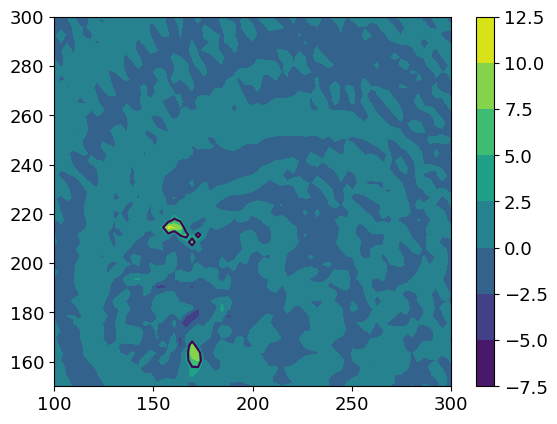

In [66]:
fds = xr.open_dataset('/scratch/home/jessica.mcdonald/NR_500m_may8/Processed_VerificationVars.nc')

plt.contourf(fds.xh, fds.yh,fds.w[100,findnearest(fds.zh, 2), :,:])
plt.colorbar()
plt.contour(fds.xh, fds.yh,fds.w[100,findnearest(fds.zh, 2), :,:], levels=[4])
plt.xlim(100,300)
plt.ylim(150,300)

In [8]:
exps = ['CI_3min_R05']#,'CI_3min', 'CI_3min_RTPP05', 'CI_3min_60', 'CI_3min_60_RTPP05']#'CI_10min_loc2', # do ci 3 loc2 tomorrow

#exps = ['CI_3min_RTPP_05_loc2', 'CI_3min_60', 'CI_3min_60_RTPP05']

threshold = 100 # for object indentification
#threshold2 = 100 # for keeping obects to match


for exp in exps:
    print(exp)

    fpath = [f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"]
    #fpath.extend(glob.glob(fpath[0]+'FORECAST*/'))

    for f in fpath:
        print(f)
    
        # pull in forecast data
        cm1 = xr.open_dataset(f"{f}full_ens_fcst.nc", decode_timedelta=True)
        times = [pd.to_datetime(t) for t in cm1.time.values]
        
        # pull in verification data!
        ds = xr.open_dataset('/work/jessica.mcdonald/scratch_link/NR_500m_may8/Processed_VerificationVars.nc')
        times_NR = [pd.to_datetime(t) for t in ds.dates.values]


        #### subset nature run to the same times as the forecast
        time = dt.datetime(times[0].year, times[0].month, times[0].day,times[0].hour, times[0].minute)
        ti = findnearest(times_NR, time)
     
     
        # now convert threshold for NR to ensemble threshold

        print('ABS UH, THRESH=100')
    
        # all times
        NR_UH =abs(ds['UH2-5km'][ti:].values)
        NRperc = stats.percentileofscore(NR_UH.flatten(), 100,nan_policy='omit') # this is the percentile of the given threshold for the NR
        
        #all times, all ensemble members
        ens_UH = abs(cm1['UH_2-5km'][:,:-1].values)
        ens_threshold = np.percentile(ens_UH, NRperc)
        print(ens_threshold)

        print('VERTICAL VELOCITY, THRESH=10')
    
        # all times
        NR_UH =(ds['w'][ti:,:findnearest(ds.zh, 8)].values)
        NRperc = stats.percentileofscore(NR_UH.flatten(), 10,nan_policy='omit') # this is the percentile of the given threshold for the NR
        
        #all times, all ensemble members
        ens_UH = (cm1['w'][:,:-1, :findnearest(cm1.z.values, 8)].values)
        ens_threshold = np.percentile(ens_UH, NRperc)
        print(ens_threshold)

        print('COMP REF, THRESH=30')
    
        # all times
        NR_UH =(ds['dbz'][ti:,:].max(axis=1).values)
        NRperc = stats.percentileofscore(NR_UH.flatten(), 30,nan_policy='omit') # this is the percentile of the given threshold for the NR
        
        #all times, all ensemble members
        ens_UH =(cm1['dbz'][:,:-1,:].max(axis=2).values)
        ens_threshold = np.percentile(ens_UH, NRperc)
        print(ens_threshold)


CI_3min_R05
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_R05/
ABS UH, THRESH=100
125.64902842484946
VERTICAL VELOCITY, THRESH=10
16.774573332513228
COMP REF, THRESH=30
37.92230432838784


CI_3min_multi
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_multi/
CI_3min_R05_multi
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_R05_multi/


Text(0.5, 1.02, '1-hr 2-km AGL UH Object Forecast after 90 minutes of DA')

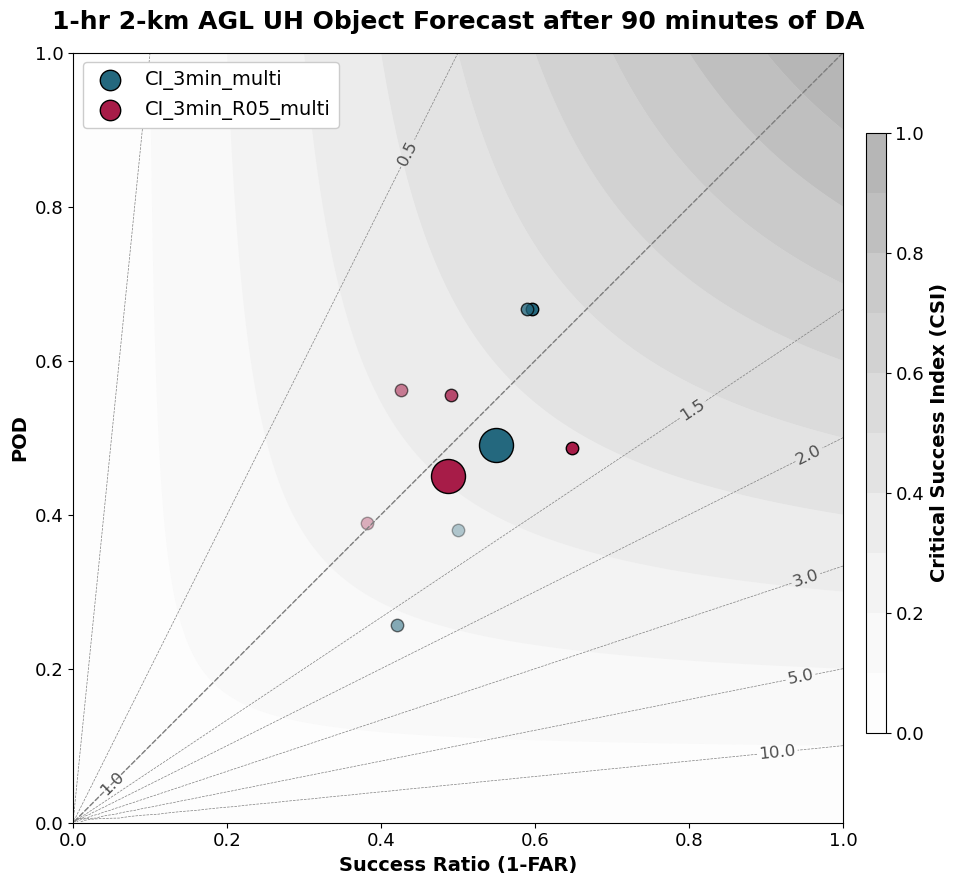

In [70]:

# tomorrow add in 3min loc 2, 
# add plot for the final forecasts too
exps = ['CI_10min', 'CI_3min', 'CI_3min_R05']

exps = ['CI_3min_multi', 'CI_3min_R05_multi']

#exps = ['CI_3min','CI_3min_RTPP05', 'CI_3min_60', 'CI_3min_60_RTPP05']

colors = cmaps.rainbow_dark(np.linspace(.0, .8, len(exps)))
colors = cmaps.pride(np.linspace(.2, .8, len(exps)))


fig, ax = plt.subplots(figsize=(10,10))
ax.set_aspect('equal')
ax.set_xlim(0,1.)
ax.set_ylim(0,1.)

 
sr_array = np.linspace(0.001,1,200)
pod_array = np.linspace(0.001,1,200)
X,Y = np.meshgrid(sr_array,pod_array)
csi_vals = (X** -1 + Y ** -1 - 1.) ** -1 
im = ax.contourf(X,Y,csi_vals,levels=np.arange(0,1.1,0.1),cmap='Greys', alpha=0.3, antialiased=True) #blue_blgra2_r,


cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Critical Success Index (CSI)', weight='bold')


fb = X/Y
ax.contour(X,Y,fb,levels=[1],linestyles='--',colors='0.5', linewidths=1)
bias = ax.contour(X,Y,fb,levels=[0.1,0.5,1,1.5,2,3,5,10],linestyles='--',colors='Grey', linewidths=0.5)
plt.clabel(bias, inline=True, inline_spacing=2,fmt='%.1f', fontsize=12,colors='0.3')

for ei,exp in enumerate(exps):
    print(exp)

    fpath = [f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"]
    
    fpath.extend(glob.glob(fpath[0]+'FORECAST*/'))

    
    for f in fpath[-1:]:
        print(f)
    
        # pull in forecast data
        perf = xr.open_dataset(f"{f}performance_UH.nc", decode_timedelta=True)

        df = pd.DataFrame(index=perf.time.values, data={'POD':perf.POD.values, 'S_RATIO':perf.S_RATIO.values})
        df = df.resample('15min').first()[1:] # drop the first value because it doesn't really exist (forecast files start 5 mins after the last DA)

        #ax.plot(df.S_RATIO, df.POD,color=colors[ei], linewidth=0.5, alpha=0.5)
        
        for ii,i in enumerate(np.arange(0, len(df.POD), 1)): # make this robust so that it actually uses time stamps, not skips
       
            ax.scatter(df.S_RATIO.iloc[i], df.POD.iloc[i], alpha=1-(.9*(ii/len(df.POD))), s=80, color=colors[ei],edgecolor='k')#
            
        ax.scatter(perf.S_RATIO.mean(), perf.POD.mean(), color=colors[ei], edgecolor='k', s=600, zorder=100, label=exp)
        perf.close()
   
ax.legend(fontsize=14, ncol=1, loc=2, markerscale=0.6)

ax.set_xlabel('Success Ratio (1-FAR)')
ax.set_ylabel('POD')
#plt.title('2-hr Forecast after 30 minutes of DA')
ax.set_title('1-hr 2-km AGL  Object Forecast after 90 minutes of DA', weight='bold', y=1.02)

In [17]:
fds = xr.open_dataset('/scratch/home/jessica.mcdonald/NR_500m_may8/Processed_VerificationVars.nc')

def plot_distribution(ax, var, **kwargs):
    hist, bins = np.histogram(var, bins=80)
    bins = (bins[1:]+bins[:-1])/2.0
    ax.semilogy(bins, hist / len(var),**kwargs)

Text(0.5, 1.06, 'Filtered 3-km Nature Run Distributions')

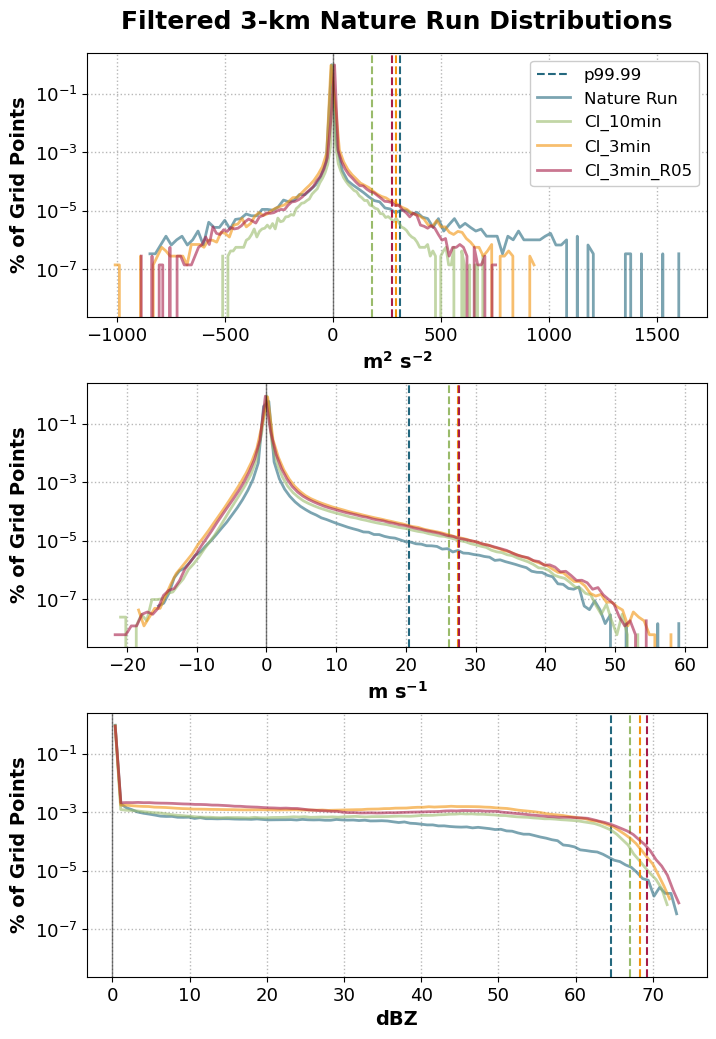

In [33]:
exps = ['CI_10min', 'CI_3min', 'CI_3min_R05']


c = cmaps.pride(np.linspace(.2, .8, len(exps)+1))

uh = (fds['UH2-5km'].values.flatten())
w = fds['w'][:, :findnearest(fds.zh, 8)].values.flatten()
dbz = fds['dbz'][:, :].max(axis=1).values.flatten()

fig, axes=plt.subplots(3,1, figsize=(8,12), sharey=True)

## UH plot

lw = 2

axes[0].axvline(np.percentile(uh, 99.99), ls='--',color=c[0], label=r'p99.99' )
plot_distribution(axes[0], uh, color=c[0], lw=lw, alpha=0.6, label='Nature Run')


## vertical velocity plot
plot_distribution(axes[1], w, color=c[0], lw=lw, alpha=0.6, label='Nature Run')
axes[1].axvline(np.percentile(w, 99.99), ls='--',color=c[0])  

## vertical velocity plot
plot_distribution(axes[2], dbz, color=c[0], lw=lw, alpha=0.6, label='Nature Run')
axes[2].axvline(np.percentile(dbz, 99.99), ls='--',color=c[0],)


for i,exp in enumerate(exps):


    cm1 = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc", decode_timedelta=True)
    
    uh = (cm1['UH_2-5km'][:,:-1].values.flatten())
    w =  cm1['w'][:,:-1, :findnearest(cm1.z, 8)].values.flatten()
    dbz =  cm1['dbz'][:, :,:-1].max(axis=1).values.flatten()


    plot_distribution(axes[0], uh, color=c[i+1], lw=lw, alpha=0.6, label=exp)
    axes[0].axvline(np.percentile(uh, 99.99), ls='--',color=c[i+1])
    
    ## vertical velocity plot
    plot_distribution(axes[1], w, color=c[i+1], lw=lw, alpha=0.6, label=exp)
    axes[1].axvline(np.percentile(w, 99.99), ls='--',color=c[i+1])  
    
    ## vertical velocity plot
    plot_distribution(axes[2], dbz, color=c[i+1], lw=lw, alpha=0.6, label=exp)
    axes[2].axvline(np.percentile(dbz, 99.99), ls='--',color=c[i+1])
        

for ax in axes:
    ax.grid(ls=':', alpha=0.7)
    ax.axvline(0, color='k', lw=1, alpha=0.5)
    ax.set_ylabel('% of Grid Points')
axes[0].legend(fontsize=12)
    
plt.subplots_adjust(hspace=0.25)

axes[0].set_xlabel(r'm$\mathbf{^2}$ s$\mathbf{^{-2}}$')
axes[1].set_xlabel(r'm s$\mathbf{^{-1}}$')
axes[2].set_xlabel(r'dBZ')

axes[0].set_title('Filtered 3-km Nature Run Distributions', y=1.06, weight='bold')

In [25]:
cm1 = xr.open_dataset(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc", decode_timedelta=True)

uh = (cm1['UH_2-5km'][:,:-1].mean(axis=1).values.flatten())
w =  cm1['w'][:,:-1, :findnearest(cm1.z, 8)].mean(axis=1).values.flatten()
dbz =  cm1['dbz'][:, :,:-1].mean(axis=1).max(axis=1).values.flatten()

# Gridding the Innovations for Additive Noise

In [228]:
PRIOR =False
fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/'
name = os.path.basename(os.path.normpath(fpath))
#myDTstring = '2024,05,08,20,05,00'

time = dt.datetime(2024,5,8,20,00)

with open(f'{fpath}letkf.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=PRIOR)

# print(files[0])
ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 1800 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member001/cm1rst_000002.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:00:00 


 Wallclock time for serial read netCDF ensemble files: 5.899  sec

 Wallclock time to convert from C to A grid: 0.687  sec

 Wallclock time to create ensemble means: 1.273  sec

 Wallclock time to read arrays from netCDF ensemble files: 8.612  sec

 Wallclock time to create coordinates: 0.0  sec


In [94]:
def fnormal(prng=np.random, scale=1.0, size=(1,)):
  return prng.normal(scale=scale, size=size)

def get_inno_and_ref_mask(ens_state, inno_threshold=10, dbz_threshold=25, verbose=False):

    print(inno_threshold, dbz_threshold)

    xoffset       = ens_state.experiment['xoffset']
    yoffset       = ens_state.experiment['yoffset']
    glat          = ens_state.experiment['lat0']
    glon          = ens_state.experiment['lon0']
    analysis_time = ens_state.datetime[0]
    
    # get obs and innovations from prior
    priors = xr.open_dataset(os.path.join(ens_state['experiment']['base_path'],f'Prior_{analysis_time.strftime("%Y-%m-%d_%H:%M:%S.nc")}'))
    prior = priors.sel(ob_num=priors.ob_num[priors.kind==12])
    
    data    =prior.value.values
    inno    =prior.value.values-prior.Hxfbar.values 
    lats    =prior.lat.values
    lons    =prior.lon.values
    hgts    =prior.z.values
    
    if verbose: print("\n ==> ens_state_GRID_REFL: Number of points found from initial search:      %d" % (data.size))
    
    # The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
    #     ens_state stores the x/y grid in grid-internal coordinates
    map      = mymap(fstate.xc, fstate.yc, glat, glon)
    xob, yob = map(lons, lats)
    xob, yob = xob+xoffset, yob+yoffset
    
    # Create obs list for KDTree query...
    xyz_obs  = np.vstack((hgts,yob,xob))
    obs_list = list(xyz_obs.transpose())
    
    # Create 3D grid arrays for KDTree
    y_array, z_array, x_array = np.meshgrid(fstate.yc, fstate.zc, fstate.xc)
    xyz_grid = np.dstack([z_array.ravel(),y_array.ravel(),x_array.ravel()])[0]
    
    # Use cKDTree to create fast indexing for 3D grid....
    mytree = scipy.spatial.cKDTree(xyz_grid)
    distance, indices1D = mytree.query(obs_list)
    
    # these are the integer indices that you now pass into the fortran routine. They
    # are the un-raveled 3D index locations nearest the observation point in the 3D array
    kk,jj,ii = np.unravel_index(indices1D, (len(fstate.zc), len(fstate.yc), len(fstate.xc)))
    
    # Call the fortran routine that grids the dbz data
    dbz3d  = obs_2_grid3d(data, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)
    inno3d = obs_2_grid3d(inno, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)

    if verbose:
        print("\n ==> ens_ADDITIVE_NOISE: Observed reflectivity gridded:  Max:  %4.2f  Min:  %4.2f" % (dbz3d.max(), dbz3d.min()))
        print("\n ==> ens_ADDITIVE_NOISE: innovations gridded:  Max:  %4.2f  Min:  %4.2f" % (inno3d.max(), inno3d.min()))
    
    mask = (dbz3d > dbz_threshold ) & (abs(inno3d) > inno_threshold)
    #zc, yc, xc  = np.meshgrid(fstate.zc[:]/1000, fstate.xc[:]/1000, fstate.yc[:]/1000, indexing='ij')

    return mask


verbose=False
dbz_threshold=25
inno_threshold=10
xoffset       = ens_state.experiment['xoffset']
yoffset       = ens_state.experiment['yoffset']
glat          = ens_state.experiment['lat0']
glon          = ens_state.experiment['lon0']
analysis_time = ens_state.datetime[0]

# get obs and innovations from prior
priors = xr.open_dataset(os.path.join(ens_state['experiment']['base_path'],f'Prior_{analysis_time.strftime("%Y-%m-%d_%H:%M:%S.nc")}'))
prior = priors.sel(ob_num=priors.ob_num[priors.kind==12])

data    =prior.value.values
inno    =prior.value.values-prior.Hxfbar.values 
lats    =prior.lat.values
lons    =prior.lon.values
hgts    =prior.z.values

if verbose: print("\n ==> ens_state_GRID_REFL: Number of points found from initial search:      %d" % (data.size))

# The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
#     ens_state stores the x/y grid in grid-internal coordinates
map      = mymap(fstate.xc, fstate.yc, glat, glon)
xob, yob = map(lons, lats)
xob, yob = xob+xoffset, yob+yoffset

# Create obs list for KDTree query...
xyz_obs  = np.vstack((hgts,yob,xob))
obs_list = list(xyz_obs.transpose())

# Create 3D grid arrays for KDTree
y_array, z_array, x_array = np.meshgrid(fstate.yc, fstate.zc, fstate.xc)
xyz_grid = np.dstack([z_array.ravel(),y_array.ravel(),x_array.ravel()])[0]

# Use cKDTree to create fast indexing for 3D grid....
mytree = scipy.spatial.cKDTree(xyz_grid)
distance, indices1D = mytree.query(obs_list)

# these are the integer indices that you now pass into the fortran routine. They
# are the un-raveled 3D index locations nearest the observation point in the 3D array
kk,jj,ii = np.unravel_index(indices1D, (len(fstate.zc), len(fstate.yc), len(fstate.xc)))

# Call the fortran routine that grids the dbz data
dbz3d  = obs_2_grid3d(data, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)
inno3d = obs_2_grid3d(inno, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)

if verbose:
    print("\n ==> ens_ADDITIVE_NOISE: Observed reflectivity gridded:  Max:  %4.2f  Min:  %4.2f" % (dbz3d.max(), dbz3d.min()))
    print("\n ==> ens_ADDITIVE_NOISE: innovations gridded:  Max:  %4.2f  Min:  %4.2f" % (inno3d.max(), inno3d.min()))

mask = (dbz3d > dbz_threshold ) & (inno3d > inno_threshold)
zc, yc, xc  = np.meshgrid(fstate.zc[:]/1000, fstate.xc[:]/1000, fstate.yc[:]/1000, indexing='ij')

           2           2
           2           2


In [84]:
np.any(mask==True)

np.True_

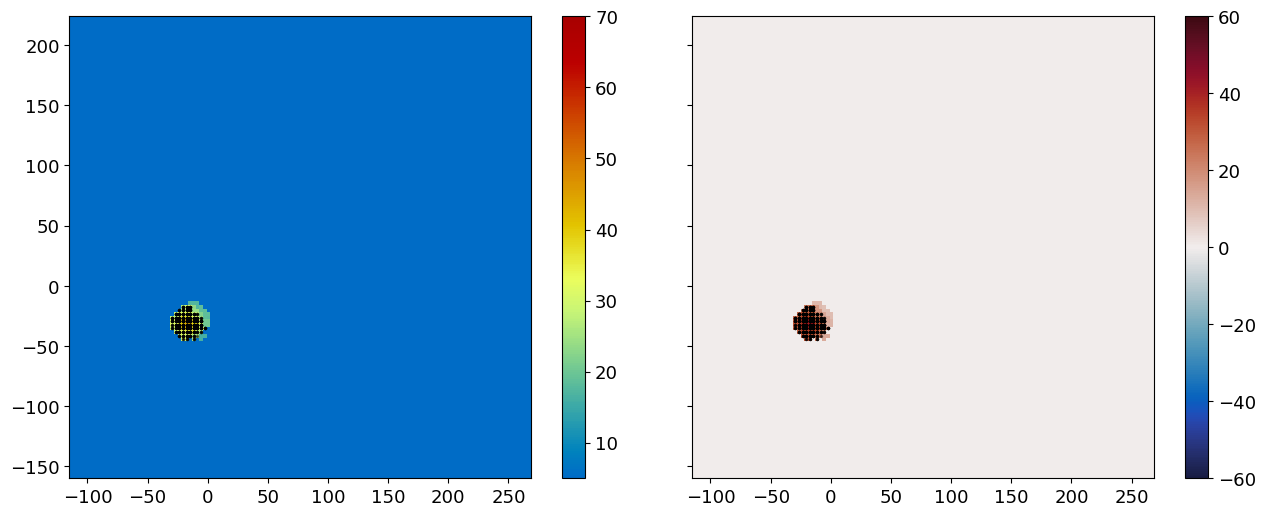

In [96]:
fig, axes = plt.subplots(1,2, sharex=True, sharey=True, figsize=(16,6), subplot_kw={'aspect':'equal'})


im=axes[0].pcolormesh(xc[0],yc[0], dbz3d.max(axis=0), cmap=ctables.REF_default, vmin=5, vmax=70)
plt.colorbar(im, ax=axes[0])

im2=axes[1].pcolormesh(xc[0],yc[0], inno3d.max(axis=0), cmap=cmaps.balance, vmin=-60, vmax=60)
plt.colorbar(im2, ax=axes[1])


for ax in axes: ax.scatter(xc[mask], yc[mask], alpha=0.5, color='k', s=2)

plt.subplots_adjust(wspace=0.01)
# axes[0].set_xlim(-50, 100)
# axes[0].set_ylim(-150, 50)

In [30]:
#===============================================================================
#
def ens_ADDITIVE_NOISE(ens_state, ob_file=None, plot=False, option=1):
#
#===============================================================================

    print("\n  ----------------------------------------------------------------------")
    print("\n                 BEGIN ADD_NOISE                                        ")
    print("\n  ----------------------------------------------------------------------")
    
    t0 = timer()

    def debug(n,p, name):
         print("\n"+f" ==> ens_ADD_NOISE: VAR: {name}  NE: {n}  Pert_Min:  {p.min():0.3f}  Pert_Max:  {p.max():0.3f}")
        
      
    # These values are set in the experiment dictionary created at the begining of the run
    
    wpert   = ens_state.experiment['ADD_NOISE']['wpert']
    upert   = ens_state.experiment['ADD_NOISE']['upert']
    vpert   = ens_state.experiment['ADD_NOISE']['vpert']
    tpert   = ens_state.experiment['ADD_NOISE']['tpert']
    tdpert  = ens_state.experiment['ADD_NOISE']['tdpert']
    qvpert  = ens_state.experiment['ADD_NOISE']['qvpert']
    hradius = ens_state.experiment['ADD_NOISE']['hradius']
    vradius = ens_state.experiment['ADD_NOISE']['vradius']
    r_seed  = ens_state.experiment['ADD_NOISE']['r_seed']
    xoffset = ens_state.experiment['xoffset']
    yoffset = ens_state.experiment['yoffset']
    nz,ny,nx= ens_state.nz,ens_state.ny,ens_state.nx
    xc,yc,zc= fstate.xc, fstate.yc, fstate.zc
    
    # Add time so random number seed changes at each time
    r_seed  = r_seed + int(ens_state.time)
    
    
    if option==1: # composite reflectivity
    
        f3d = ens_GRID_RELECTIVITY(ens_state, ob_file=ob_file, cref=True)
    
        if type(f3d) == str :
            print("\n  ==> ens_ADDITIVE_NOISE: Not enough reflectivity obs to grid, exiting ADDITIVE_NOISE")
            #return
        
        else:
            f3d_min = ens_state.experiment['ADD_NOISE']['min_dbz_4pert']
            print("\n ==> ens_ADDITIVE_NOISE: Observed reflectivity gridded:  Max:  %4.2f  Min:  %4.2f" % (f3d.max(), f3d.min()))
            mask = f3d > f3d_min
    
    if option==2: # adaptive inflation
    
        # Use the adaptive inflation file as the mask
        
        infilename = "Inflation_%s.nc" % (ens_state.datetime[0].strftime("%Y-%m-%d_%H:%M:%S"))
        newfile    = os.path.join(ens_state.experiment['base_path'], infilename)  
        file_obj   = netCDF4.Dataset(newfile, "r")
        f3d        = file_obj.variables['inflation'][...]
        f3d_min    = 2.0
        file_obj.close()
        mask = f3d > f3d_min
        print("\n ==> ens_ADDITIVE_NOISE: Inflation file read in:  Max:  %4.2f  Min:  %4.2f" % (f3d.max(), f3d.min()))
        
    if option == 3: # innovations AND reflectivity (3D)
    
        #mask = get_inno_and_ref_mask(ens_state, inno_threshold=ens_state.experiment['ADD_NOISE']['min_inno_4pert'], dbz_threshold=ens_state.experiment['ADD_NOISE']['min_dbz_4pert'])
         mask = get_inno_and_ref_mask(ens_state, dbz_threshold=ens_state.experiment['ADD_NOISE']['min_dbz_4pert'],verbose=True)
        
    ### now apply the smoothed perturbations
    
    for n in np.arange(ens_state.ne):
    
        if upert > 0:
            raw_pert = fnormal(np.random.RandomState([1+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
            pert     = np.where(mask, raw_pert, 0.0)
            p        = add_smooth_perts(pert, hradius, vradius,xc,yc,zc)
            p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())
            ens_state['U'][n] = ens_state['U'][n] + upert*p
            if debugAN: debug(n,p,'U')
        
        if vpert > 0:
            raw_pert = fnormal(np.random.RandomState([2+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
            pert     = np.where(mask, raw_pert, 0.0)
            p        = add_smooth_perts(pert, hradius, vradius, xc,yc,zc)
            p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())
            ens_state['V'][n] = ens_state['V'][n] + vpert*p
            if debugAN: debug(n,p,'V')
        
        if wpert > 0:
            raw_pert = fnormal(np.random.RandomState([3+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
            pert     = np.where(mask, raw_pert, 0.0)
            p        = add_smooth_perts(pert, hradius, vradius, xc,yc,zc)
            p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())
            ens_state['W'][n] = ens_state['W'][n] + wpert*p
            if debugAN: debug(n,p,'W')
        
        if tpert > 0:
            raw_pert = fnormal(np.random.RandomState([4+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
            pert     = np.where(mask, raw_pert, 0.0)
            p        = add_smooth_perts(pert, hradius, vradius, xc,yc,zc)
            p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())
            ens_state['TH'][n] = ens_state['TH'][n] + tpert*p
            if debugAN:  debug(n,p,'T')
          
        # If Tdpert > 0, add dewpoint perturbations to QV - do it in Td space
        if tdpert > 0.0 and qvpert < 0.01:                                  # Dont do both, prefer saturations...
            raw_pert = fnormal(np.random.RandomState([5+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
            pert     = np.where(mask, raw_pert, 0.0)
            p        = add_smooth_perts(pert, hradius, vradius, xc,yc,zc)
            p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())
            
            p0 = 1000.*(ens_state['PI0'][n])**3.508
            e  = ens_state['QV'][n]*p0/(0.622+ens_state['QV'][n])            # vapor pressure
            e  = np.clip(e, 0.001, 100.)                                     # avoid problems near zero
            td = 273.16 + ( 243.5 / ( 17.67/np.log(e/6.112) - 1.0 ) )        # Bolton's approximation
            td = np.clip(td + tdpert*p, 200.0, (p0*ens_state['TH'][n])-0.1)  #theres probably a bug here       # make sure Td is < T
            
            # Transform back to QV
            
            tdc = td - 273.16
            e   = 6.112 * np.exp(17.67*tdc / (tdc+243.5) )                   # Bolton's approximation
            ens_state['QV'][n] = 0.622*e / (p0-e)
            
            if debugAN: debug(n,ens_state['QV'][n],"Td/QV")
        
        # If qvpert > 0, add noise to Qv, restricting the RH <= 99%.
        if qvpert > 0.0:
            raw_pert = fnormal(np.random.RandomState([5+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
            pert     = np.where(mask, raw_pert, 0.0)
            p        = add_smooth_perts(pert, hradius, vradius, xc,yc,zc)
            p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())
            
            tc = (ens_state['PI0'][n]*ens_state['TH'][n]) - 273.16
            p0 = 1000.*(ens_state['PI0'][n])**3.508
            e  = 6.112 * np.exp(17.67*tc / (tc+243.5) )  
            qvs = (0.622*e)/ (p0-e)
            ens_state['QV'][n] = ens_state['QV'][n] + p*qvpert/100.      
            ens_state['QV'][n] = np.where(ens_state['QV'][n] >= qvs/100., 0.99*qvs/100., ens_state['QV'][n])     
            
            if debugAN: debug(n,p,'QV')
    
    if plot:
        ens_state_PLOT_MEAN_STDDEV(ens_state, klevel = 4, savefig="ADDITIVE_NOISE_PLOT.pdf")
       
    if time_all:  print("\n Wallclock time to run ADDITIVE_NOISE:", round(timer() - t0, 3), " sec")
    
    print("\n  ----------------------------------------------------------------------")
    print("\n                 END ADD_NOISE                                          ")
    print("\n  ----------------------------------------------------------------------")



In [22]:
import netCDF4

In [24]:
ens_state.keys()

{'name': 'CM1',
 'files': ['/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member001/cm1rst_000002.nc',
  '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member002/cm1rst_000002.nc',
  '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member003/cm1rst_000002.nc',
  '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member004/cm1rst_000002.nc',
  '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member005/cm1rst_000002.nc',
  '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member006/cm1rst_000002.nc',
  '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member007/cm1rst_000002.nc',
  '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member008/cm1rst_000002.nc',
  '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member009/cm1rst_000002.nc',
  '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member010/cm1rst_000002.nc',
  '/w

In [229]:
TH = ens_state['TH'][:-1].copy()
U = ens_state['U'][:-1].copy()
V = ens_state['V'][:-1].copy()
W = ens_state['W'][:-1].copy()
QV = ens_state['QV'][:-1].copy()
np.shape(TH)

(36, 52, 128, 128)

In [230]:

# These values are set in the experiment dictionary created at the begining of the run

option=3
debugAN=False


wpert   = 0.5#ens_state.experiment['ADD_NOISE']['wpert']
upert   = 1.0#ens_state.experiment['ADD_NOISE']['upert']
vpert   = 1.0#ens_state.experiment['ADD_NOISE']['vpert']
tpert   = 1.0#ens_state.experiment['ADD_NOISE']['tpert']
tdpert  = 0#ens_state.experiment['ADD_NOISE']['tdpert']
qvpert  = 1.0#ens_state.experiment['ADD_NOISE']['qvpert']
hradius = ens_state.experiment['ADD_NOISE']['hradius']
vradius = ens_state.experiment['ADD_NOISE']['vradius']
r_seed  = ens_state.experiment['ADD_NOISE']['r_seed']
xoffset = ens_state.experiment['xoffset']
yoffset = ens_state.experiment['yoffset']
nz,ny,nx= ens_state.nz,ens_state.ny,ens_state.nx
xc,yc,zc= fstate.xc, fstate.yc, fstate.zc

# Add time so random number seed changes at each time
r_seed  = r_seed + int(ens_state.time)


if option==1: # composite reflectivity

    f3d = ens_GRID_RELECTIVITY(ens_state, ob_file=ob_file, cref=True)

    if type(f3d) == str :
        print("\n  ==> ens_ADDITIVE_NOISE: Not enough reflectivity obs to grid, exiting ADDITIVE_NOISE")
        #return
    
    else:
        f3d_min = ens_state.experiment['ADD_NOISE']['min_dbz_4pert']
        print("\n ==> ens_ADDITIVE_NOISE: Observed reflectivity gridded:  Max:  %4.2f  Min:  %4.2f" % (f3d.max(), f3d.min()))
        mask = f3d > f3d_min

if option==2: # adaptive inflation

    # Use the adaptive inflation file as the mask
    
    infilename = "Inflation_%s.nc" % (ens_state.datetime[0].strftime("%Y-%m-%d_%H:%M:%S"))
    newfile    = os.path.join(ens_state.experiment['base_path'], infilename)  
    file_obj   = netCDF4.Dataset(newfile, "r")
    f3d        = file_obj.variables['inflation'][...]
    f3d_min    = 1.3
    file_obj.close()
    mask = f3d > f3d_min
    print("\n ==> ens_ADDITIVE_NOISE: Inflation file read in:  Max:  %4.2f  Min:  %4.2f" % (f3d.max(), f3d.min()))
    
if option == 3: # innovations AND reflectivity (3D)

    #mask = get_inno_and_ref_mask(ens_state, inno_threshold=ens_state.experiment['ADD_NOISE']['min_inno_4pert'], dbz_threshold=ens_state.experiment['ADD_NOISE']['min_dbz_4pert'], verbose=True)
    mask = get_inno_and_ref_mask(ens_state,verbose=True)
    
### now apply the smoothed perturbations

for n in np.arange(ens_state.ne):

    if upert > 0:
        raw_pert = fnormal(np.random.RandomState([1+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
        pert     = np.where(mask, raw_pert, 0.0)
        praw     = add_smooth_perts(pert, hradius, vradius,xc,yc,zc)
        p        = np.where(praw!=0, 1.0 - 2.0*(praw - praw.min()) / (praw.max()-praw.min()), praw)
        ens_state['U'][n] = ens_state['U'][n] + upert*p
        if debugAN: debug(n,p,'U')
    
    if vpert > 0:
        raw_pert = fnormal(np.random.RandomState([2+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
        pert     = np.where(mask, raw_pert, 0.0)
        praw     = add_smooth_perts(pert, hradius, vradius,xc,yc,zc)
        p        = np.where(praw!=0, 1.0 - 2.0*(praw - praw.min()) / (praw.max()-praw.min()), praw)
        ens_state['V'][n] = ens_state['V'][n] + vpert*p
        if debugAN: debug(n,p,'V')
    
    if wpert > 0:
        raw_pert = fnormal(np.random.RandomState([3+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
        pert     = np.where(mask, raw_pert, 0.0)
        praw     = add_smooth_perts(pert, hradius, vradius,xc,yc,zc)
        p        = np.where(praw!=0, 1.0 - 2.0*(praw - praw.min()) / (praw.max()-praw.min()), praw)
        ens_state['W'][n] = ens_state['W'][n] + wpert*p
        if debugAN: debug(n,p,'W')
    
    if tpert > 0:
        raw_pert = fnormal(np.random.RandomState([4+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
        pert     = np.where(mask, raw_pert, 0.0)
        praw     = add_smooth_perts(pert, hradius, vradius,xc,yc,zc)
        p        = np.where(praw!=0, 1.0 - 2.0*(praw - praw.min()) / (praw.max()-praw.min()), praw)
        ens_state['TH'][n] = ens_state['TH'][n] + tpert*p
        if debugAN:  debug(n,p,'T')
      
    # If Tdpert > 0, add dewpoint perturbations to QV - do it in Td space
    if tdpert > 0.0 and qvpert < 0.01:                                  # Dont do both, prefer saturations...
        raw_pert = fnormal(np.random.RandomState([5+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
        pert     = np.where(mask, raw_pert, 0.0)
        praw     = add_smooth_perts(pert, hradius, vradius,xc,yc,zc)
        p        = np.where(praw!=0, 1.0 - 2.0*(praw - praw.min()) / (praw.max()-praw.min()), praw)
        
        p0 = 1000.*(ens_state['PI0'][n])**3.508
        e  = ens_state['QV'][n]*p0/(0.622+ens_state['QV'][n])            # vapor pressure
        e  = np.clip(e, 0.001, 100.)                                     # avoid problems near zero
        td = 273.16 + ( 243.5 / ( 17.67/np.log(e/6.112) - 1.0 ) )        # Bolton's approximation
        td = np.clip(td + tdpert*p, 200.0, (p0*ens_state['TH'][n])-0.1)  #theres probably a bug here       # make sure Td is < T
        
        # Transform back to QV
        
        tdc = td - 273.16
        e   = 6.112 * np.exp(17.67*tdc / (tdc+243.5) )                   # Bolton's approximation
        ens_state['QV'][n] = 0.622*e / (p0-e)
        
        if debugAN: debug(n,ens_state['QV'][n],"Td/QV")
    
    # If qvpert > 0, add noise to Qv, restricting the RH <= 99%.
    if qvpert > 0.0:
        raw_pert = fnormal(np.random.RandomState([5+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
        pert     = np.where(mask, raw_pert, 0.0)
        praw     = add_smooth_perts(pert, hradius, vradius,xc,yc,zc)
        p        = np.where(praw!=0, 1.0 - 2.0*(praw - praw.min()) / (praw.max()-praw.min()), praw)
        
        tc = (ens_state['PI0'][n]*ens_state['TH'][n]) - 273.16 # celcius
        p0 = 1000.*(ens_state['PI0'][n])**3.508                # hpa
        e  = 6.112 * np.exp(17.67*tc / (tc+243.5) )            # hpa
        qvs = (0.622*e)/ (p0-e)                                # this is dimensionless, so it is equivalent to kg/kg!                            
        ens_state['QV'][n] = ens_state['QV'][n] + p*qvpert/1000.      
        #ens_state['QV'][n] = np.where(ens_state['QV'][n] >= qvs/100., 0.99*qvs/100., ens_state['QV'][n]) # do not divide by 100
        ens_state['QV'][n] = np.where(ens_state['QV'][n] >= qvs, 0.99*qvs, ens_state['QV'][n]) 
        
    #     if debugAN: debug(n,p,'QV')

10 25

 ==> ens_state_GRID_REFL: Number of points found from initial search:      127
           2           2
           2           2

 ==> ens_ADDITIVE_NOISE: Observed reflectivity gridded:  Max:  42.84  Min:  0.00

 ==> ens_ADDITIVE_NOISE: innovations gridded:  Max:  40.52  Min:  0.00


In [172]:
raw_pert = fnormal(np.random.RandomState([1+r_seed+n**2]), scale=1.0, size=(nz,ny,nx))
pert     = np.where(mask, raw_pert, 0.0)
praw        = add_smooth_perts(pert, hradius, vradius,xc,yc,zc)
p =  np.where(praw!=0, 1.0 - 2.0*(praw - praw.min()) / (praw.max()-praw.min()), praw)
#p        = 1.0 - 2.0*(p - p.min()) / (p.max()-p.min())

In [173]:
p =  np.where(praw!=0, 1.0 - 2.0*(praw - praw.min()) / (praw.max()-praw.min()), praw)

In [219]:
temp = QV[0]+ p*qvpert/1000.  

In [225]:
from metpy.calc import saturation_mixing_ratio
from metpy.units import units

In [227]:
saturation_mixing_ratio(p0[0,0,0]*units.hPa, tc[0,0,0]*units.degC).to('g/kg')

<Quantity(25.002281188964844, 'gram / kilogram')>

In [233]:
qvs[0,0,0]/100

np.float32(0.000250572)

In [220]:
temp[0,0,0]

np.float32(0.015993822)

In [223]:
e[0,0,0]

np.float32(36.626858)

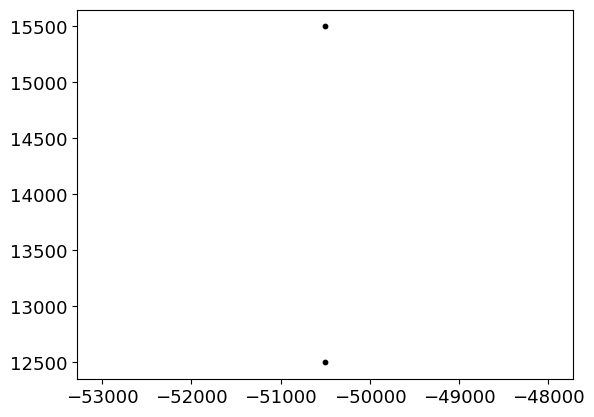

In [140]:

klev=15
plt.scatter(X[mask[klev]], Y[mask[klev]], s=10, color='k', alpha=1)

In [133]:
np.where(mask)

(array([15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 17,
        17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18,
        18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18,
        18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19, 19, 19,
        19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19,
        19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19,
        19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
        20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
        20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
        20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21,
        21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21,
        21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21,
        21, 21, 21, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22,
        22, 

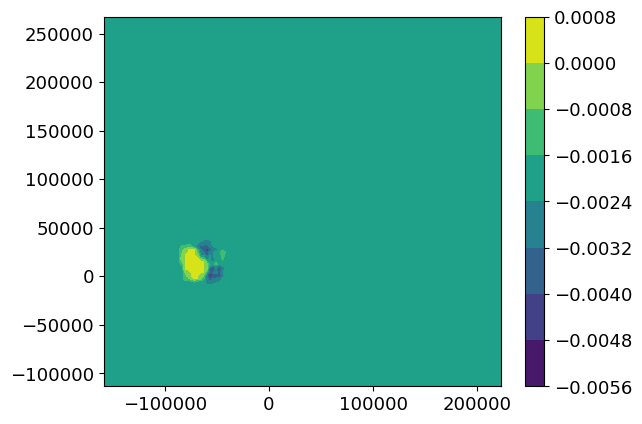

In [152]:
plt.contourf(xc, yc, ens_state['QV'][mem,klev])
plt.colorbar()

0.0


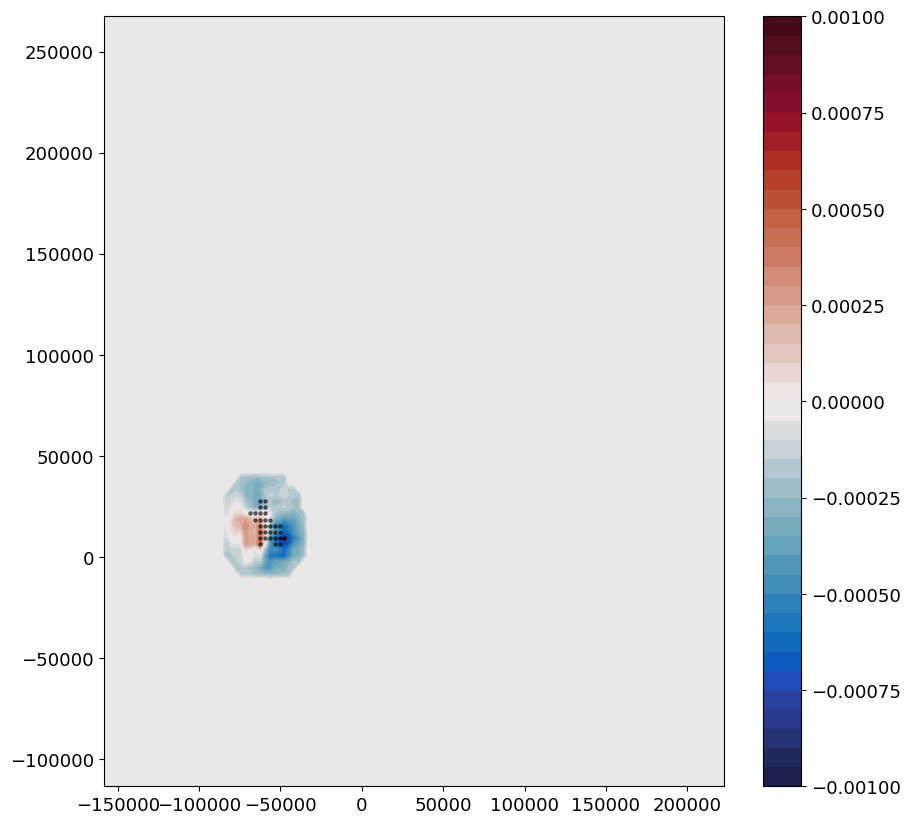

In [232]:
fig = plt.figure(figsize=(10,10))

klev = 18
mem=3

print(ens_state['TH'][mem,klev,0,0] -TH[mem,klev,0,0])

plt.contourf(xc,yc, (ens_state['QV'][mem,klev] -QV[mem,klev]),np.arange(-1, 1.05, .05)/1000,   cmap=cmaps.balance) #np.arange(-1, 1.05, .05)np.arange(-1, 1.05, .05)/100
plt.colorbar()

#zc, yc, xc  = np.meshgrid(fstate.zc[:]/1000, fstate.xc[:]/1000, fstate.yc[:]/1000, indexing='ij')
plt.scatter(X[mask[klev]], Y[mask[klev]], s=5, color='k', alpha=0.5)

In [90]:
np.shape(mask)

(52, 128, 128)

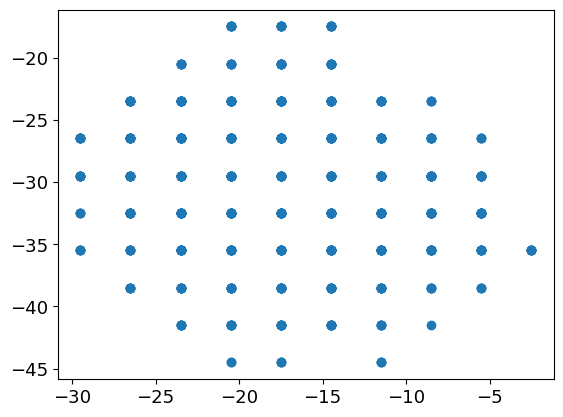

In [59]:
zc, yc, xc  = np.meshgrid(fstate.zc[:]/1000, fstate.xc[:]/1000, fstate.yc[:]/1000, indexing='ij')

plt.scatter(xc[mask], yc[mask])

In [330]:
p.min()

np.float32(-1.0)

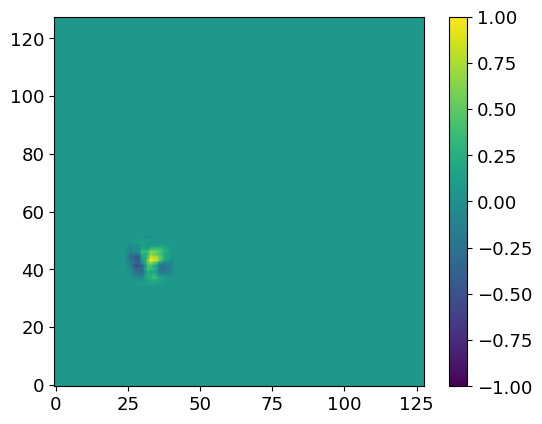

In [332]:
plt.imshow(p[20], origin='lower', vmin=-1, vmax=1)
plt.colorbar()

In [308]:
xoffset       = ens_state.experiment['xoffset']
yoffset       = ens_state.experiment['yoffset']
glat          = ens_state.experiment['lat0']
glon          = ens_state.experiment['lon0']
analysis_time = ens_state.datetime[0]

# get obs and innovations from prior
priors = xr.open_dataset(os.path.join(ens_state['experiment']['base_path'],f'Prior_{analysis_time.strftime("%Y-%m-%d_%H:%M:%S.nc")}'))
prior = priors.sel(ob_num=priors.ob_num[priors.kind==12])

data    =prior.value.values
inno    =prior.value.values-prior.Hxfbar.values 
lats    =prior.lat.values
lons    =prior.lon.values
hgts    =prior.z.values

if verbose: print("\n ==> ens_state_GRID_REFL: Number of points found from initial search:      %d" % (data.size))

# The coordinate system here is based on the grid lat0/lon0/hgt0, and the offset grid stored in fstate
#     ens_state stores the x/y grid in grid-internal coordinates
map      = mymap(fstate.xc, fstate.yc, glat, glon)
xob, yob = map(lons, lats)
xob, yob = xob+xoffset, yob+yoffset

# Create obs list for KDTree query...
xyz_obs  = np.vstack((hgts,yob,xob))
obs_list = list(xyz_obs.transpose())

# Create 3D grid arrays for KDTree
y_array, z_array, x_array = np.meshgrid(fstate.yc, fstate.zc, fstate.xc)
xyz_grid = np.dstack([z_array.ravel(),y_array.ravel(),x_array.ravel()])[0]

# Use cKDTree to create fast indexing for 3D grid....
mytree = scipy.spatial.cKDTree(xyz_grid)
distance, indices1D = mytree.query(obs_list)

# these are the integer indices that you now pass into the fortran routine. They
# are the un-raveled 3D index locations nearest the observation point in the 3D array
kk,jj,ii = np.unravel_index(indices1D, (len(fstate.zc), len(fstate.yc), len(fstate.xc)))

# Call the fortran routine that grids the dbz data
dbz3d  = obs_2_grid3d(data, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)
inno3d = obs_2_grid3d(inno, xob, yob, hgts, x_array, y_array, z_array, ii, jj, kk, 4000., 2000., 0.0)

if verbose:
    print("\n ==> ens_ADDITIVE_NOISE: Observed reflectivity gridded:  Max:  %4.2f  Min:  %4.2f" % (dbz3d.max(), dbz3d.min()))
    print("\n ==> ens_ADDITIVE_NOISE: innovations gridded:  Max:  %4.2f  Min:  %4.2f" % (inno3d.max(), inno3d.min()))

mask = (dbz3d > dbz_threshold ) & (abs(innos3d) > inno_threshold)


 ==> ens_state_GRID_REFL: Number of points found from initial search:      127
           2           2
           2           2

 ==> ens_ADDITIVE_NOISE: Observed reflectivity gridded:  Max:  42.84  Min:  0.00

 ==> ens_ADDITIVE_NOISE: innovations gridded:  Max:  40.52  Min:  0.00


In [306]:
dbz_threshold

25

In [299]:
p

array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       ...,

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan

In [23]:
# def pmm_analysis(var, N , return_mean=False):
#     ''' height is in km'''

#     ens_state_mean = cm1[var][t, -1,zi]
#     ranked_ens =sorted(cm1[var][t, :-1, zi].values.ravel())[::N]
    
#     x,y = np.meshgrid(cm1.xh, cm1.yh)
#     d = {'ens':ens_mean.values.ravel(), 'x':x.ravel(), 'y':y.ravel()}
#     df = pd.DataFrame(d)
    
#     df_ranked = df.sort_values(by='ens')
#     df_ranked['ens'] = ranked_ens
    
#     df_pmm = df_ranked.sort_index()

#     if return_mean:
    
#         return df_pmm['ens'].values.reshape(np.shape(x)), ens_mean
#     else:
#         return df_pmm['ens'].values.reshape(np.shape(x))

# PRIOR =False
# fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/'

# time = dt.datetime(2024,5,8,20,10)

# with open(f'{fpath}letkf.exp', 'rb') as f:exper = json.load(f)
# files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=PRIOR)

# ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
# ens.ens_CM1_coords(ens_state)


ex1 = 'CI_10min_multi'
ex2 = 'CI_10min_multi_add'

exps = [ 'CI_10min_multi','CI_10min_multi_add']

In [32]:
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

In [10]:
files

['/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add_test/member001/cm1rst_000006.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add_test/member002/cm1rst_000006.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add_test/member003/cm1rst_000006.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add_test/member004/cm1rst_000006.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add_test/member005/cm1rst_000006.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add_test/member006/cm1rst_000006.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add_test/member007/cm1rst_000006.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add_test/member008/cm1rst_000006.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add_test/member009/cm1rst_000006.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:20:00

 ==> FindRestartFile:  Found time 3000 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member001/cm1rst_000006.nc

 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:20:00

 ==> FindRestartFile:  Found time 3000 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add3/member001/cm1rst_000006.nc

 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:20:00

 ==> FindRestartFile:  Found time 3000 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add_test/member001/cm1rst_000006.nc


Text(0.5, 1.0, 'obs')

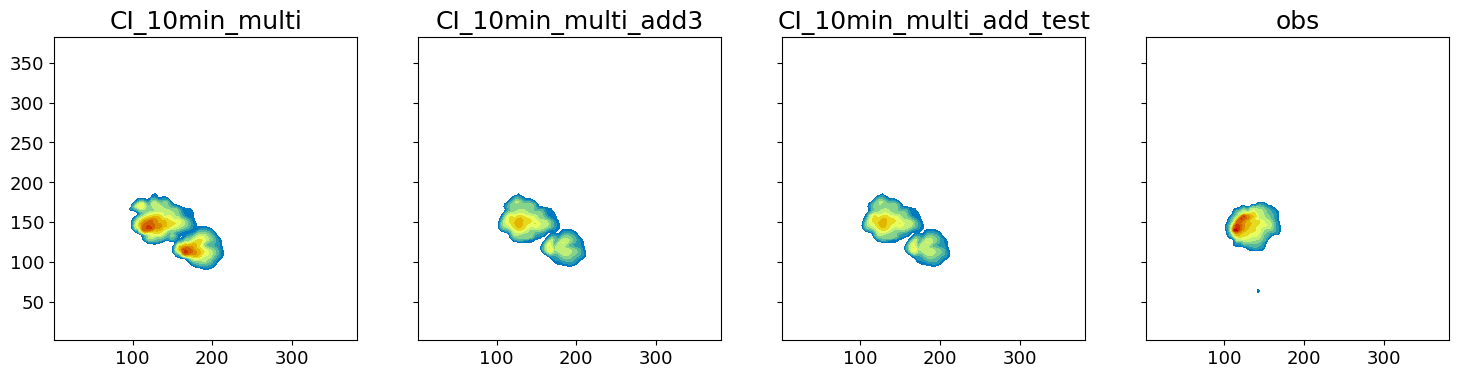

In [9]:
time = dt.datetime(2024,5,8,20,20)

member = 15



exps = [ 'CI_10min_multi','CI_10min_multi_add3','CI_10min_multi_add_test']

fig, axes = plt.subplots(1,4, sharex=True, sharey=True, subplot_kw={'aspect':'equal'}, figsize=(18, 6))

for i,exp in enumerate(exps):

    fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}'

    with open(os.path.join(fpath, 'letkf.exp'), 'rb') as f:exper = json.load(f)
    files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=False)
    # just pick member 1

    cm1 = xr.open_dataset(files[member], decode_timedelta=True)
    axes[i].contourf(cm1.xh/1000, cm1.yh/1000, cm1.dbz[0].max(axis=0), levels=np.arange(5, 75, 5), cmap=ctables.REF_default)
    axes[i].set_title(exp)
    cm1.close()


ds = xr.open_dataset('/work/jessica.mcdonald/scratch_link/extra_NR_500m_may8/Processed_VerificationVars.nc')
times = [pd.to_datetime(d) for d in ds.dates.values]
axes[3].contourf(ds.xh, ds.yh, ds.dbz[findnearest(times, time)].max(axis=0), levels=np.arange(5, 75, 5), cmap=ctables.REF_default)

axes[3].set_title('obs')

In [12]:
ctest = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add_test/member016/cm1rst_000006.nc', decode_timedelta=True)

ctest2 = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add3/member016/cm1rst_000006.nc', decode_timedelta=True)

In [13]:
temp = (ctest.dbz[0].max(axis=0) - ctest2.dbz[0].max(axis=0))

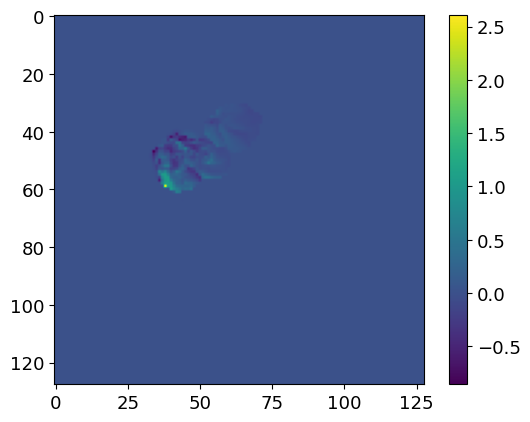

In [15]:
plt.imshow(temp)
plt.colorbar()

In [263]:
cmaps.pride((3-m)/3)

(np.float64(0.12156862745098039),
 np.float64(0.0392156862745098),
 np.float64(0.10196078431372549),
 np.float64(1.0))


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:20:00

 ==> FindRestartFile:  Found time 3000 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi/member001/cm1rst_000006.nc

 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:20:00

 ==> FindRestartFile:  Found time 3000 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add3/member001/cm1rst_000006.nc


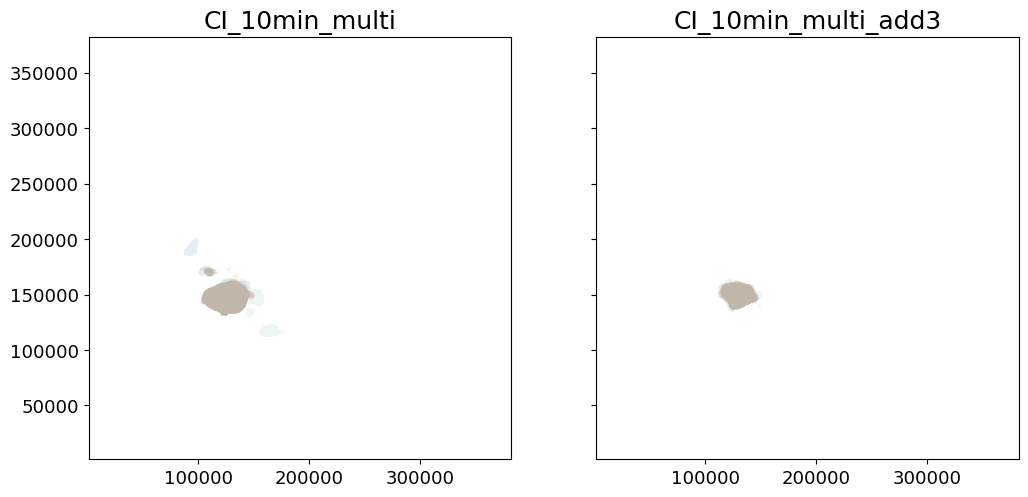

In [267]:
time = time = dt.datetime(2024,5,8,20,20)

member = 10

exps = [ 'CI_10min_multi','CI_10min_multi_add3']

fig, axes = plt.subplots(1,2, sharex=True, sharey=True, subplot_kw={'aspect':'equal'}, figsize=(12, 6))

for i,exp in enumerate(exps):

    fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}'

    with open(os.path.join(fpath, 'letkf.exp'), 'rb') as f:exper = json.load(f)
    files, myDT = ens.FindRestartFiles(exper, time, ret_exp=False, prior=PRIOR)
    # just pick member 1
    for m,mem in enumerate([1,2,3,4,5,6]):
        cm1 = xr.open_dataset(files[mem], decode_timedelta=True)
        axes[i].contourf(cm1.xh, cm1.yh, cm1.dbz[0].max(axis=0), levels=[30,70], alpha=0.1,colors=[cmaps.pride((6-m)/6)])#, cmap=ctables.REF_default)
        axes[i].set_title(exp)
        cm1.close()

In [26]:
files

['/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/member001/cm1rst_000004.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/member002/cm1rst_000004.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/member003/cm1rst_000004.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/member004/cm1rst_000004.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/member005/cm1rst_000004.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/member006/cm1rst_000004.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/member007/cm1rst_000004.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/member008/cm1rst_000004.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/member009/cm1rst_000004.nc',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_10min_multi_add/member010/cm1rst_000004.nc',


# Creating better posterior/prior code

In [3]:
import os
import numpy as N
import math as M
import datetime as DT 
from netCDF4 import *
import pyDart
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *

import json
import src.plot_src.ctables as ctables

from pyDart import dxy_2_dll
import pandas as pd
import pickle
import numpy as np
import cftime


day_utime   = "days since 1601-01-01 00:00:00"
sec_utime   = "seconds since 1970-01-01 00:00:00"

import sys
import ens
from ens import calcHx
import pandas as pd
import state_vector as state_vector
import datetime as DT
import json
import numpy as np


In [7]:

#fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_outliers/'
fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_noref/'
name = fpath.split('/')[-2]

analysis_time = DT.datetime(2024, 5, 8, 20)

sec_utime = "seconds since 1970-01-01 00:00:00"
with open(f'{fpath}{name}.exp', 'rb') as f:
    exper = json.load(f)


    
files, myDT = ens.FindRestartFiles(exper, analysis_time, ret_exp=False)

state = ens.read_CM1_ens(files, exper, state_vector=state_vector.Hxf, DateTime=analysis_time)   
ens.ens_CM1_C2A(state)
ens.ens_CM1_coords(state)




 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 1800 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_noref/member001/cm1rst_000006.nc

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:00:00 


 Wallclock time for serial read netCDF ensemble files: 2.358  sec

 Wallclock time to convert from C to A grid: 0.436  sec

 Wallclock time to read arrays from netCDF ensemble files: 2.938  sec

 Wallclock time to convert from C to A grid: 0.437  sec

 Wallclock time to create coordinates: 0.0  sec


In [8]:

fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_noref/'



# ################
name = fpath.split('/')[-2]

sec_utime = "seconds since 1970-01-01 00:00:00"
with open(f'{fpath}{name}.exp', 'rb') as f:
    exper = json.load(f)

    
obs_file = exper['radar_obs']
window = int(exper['DA_PARAMS']['assim_window'])
obs_error = exper['DA_PARAMS']['obs_errors']
outlier = exper['DA_PARAMS']['outlier']
obs_include = exper['DA_PARAMS']['obs_included']
path = exper['base_path']
start = DT.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')
end   = DT.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')
tdel  = DT.timedelta(seconds=exper['DA_PARAMS']['assim_freq'])

ob_f = pd.read_csv(obs_file)



analysis_time= start

# if you want only a subset of observations, this will do that. Make sure to add additional options as the file contains more data
if len(obs_include) > 0:
    include = []
    for ob in obs_include:
        print(f'-------->> INCLDUING OBSERVATION TYPE {ob}')
        if ob == "DBZ0_W":
            include.append(14)
            ob_f.loc[ob_f.kind==13, 'kind'] = 14 # recode all clear air obs to be vertical velocity         
        if ob == "DBZ0":
            include.append(13)
        if ob == "DBZ":
            include.append(12)
        if ob == 'VR':
            include.append(11)

    ob_f = ob_f[ob_f['kind'].isin(include)]

#set spatial and temporal conditions to index the observation data 
g_lat_max = state.late[:].max()
g_lat_min = state.late[:].min()
g_lon_max = state.lone[:].max()
g_lon_min = state.lone[:].min()
g_alt_max = max(state.zc.data[:]) + state.hgt
g_alt_min = min(state.zc.data[:]) + state.hgt

dt     = DT.timedelta(0,int(window/2))
begin  = cftime.date2num(analysis_time - dt, sec_utime)
ending = cftime.date2num(analysis_time + dt, sec_utime)

data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) & \
          (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
          (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)

subdata = ob_f[data_mask]


-------->> INCLDUING OBSERVATION TYPE DBZ


In [4]:



fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/'



# ################
name = fpath.split('/')[-2]

sec_utime = "seconds since 1970-01-01 00:00:00"
with open(f'{fpath}{name}.exp', 'rb') as f:
    exper = json.load(f)

    
obs_file = exper['radar_obs']
window = int(exper['DA_PARAMS']['assim_window'])
obs_error = exper['DA_PARAMS']['obs_errors']
outlier = exper['DA_PARAMS']['outlier']
obs_include = exper['DA_PARAMS']['obs_included']
path = exper['base_path']
start = DT.datetime(2024,5,8,20,30)#DT.datetime.strptime(exper['DA_PARAMS']['DA_start_time'], '%Y-%m-%d %H:%M:%S')
end   = DT.datetime(2024,5,8,21,30)#DT.datetime.strptime(exper['DA_PARAMS']['DA_end_time'], '%Y-%m-%d %H:%M:%S')
tdel  = DT.timedelta(seconds=exper['DA_PARAMS']['assim_freq'])
tdel = DT.timedelta(seconds=600)

ob_f = pd.read_csv(obs_file)

for analysis_time in np.arange(start, end+tdel, tdel):
    #analysis_time.astype(DT.timedelta)
    analysis_time = pd.Timestamp(analysis_time)

    lat     = np.empty((0))
    lon     = np.empty((0))
    dates   = np.empty((0))
    value   = np.empty((0))
    kind    = np.empty((0))
    height  = np.empty((0))
    elev    = np.empty((0))
    az      = np.empty((0))
    err_var = np.empty((0))
    idx     = np.empty((0))

    
    
    print("\n --> ComputeHx:  Reading in model state for HxF at %s \n" %  (analysis_time.strftime("%Y-%m-%d %H:%M:%S")))
    
    # read from history files
      
        
    files, myDT = ens.FindRestartFiles(exper, analysis_time, ret_exp=False)
    
    state = ens.read_CM1_ens(files, exper, state_vector=state_vector.Hxf, DateTime=myDT)   
    ens.ens_CM1_C2A(state)
    ens.ens_CM1_coords(state)
    
      
    Hxfm = np.empty((0,state.ne))  # need to init this here cause need size of ensemble
    
    
    # if you want only a subset of observations, this will do that. Make sure to add additional options as the file contains more data
    if len(obs_include) > 0:
        include = []
        for ob in obs_include:
            print(f'-------->> INCLDUING OBSERVATION TYPE {ob}')
            if ob == "DBZ0_W":
                include.append(14)
                ob_f.loc[ob_f.kind==13, 'kind'] = 14 # recode all clear air obs to be vertical velocity         
            if ob == "DBZ0":
                include.append(13)
            if ob == "DBZ":
                include.append(12)
            if ob == 'VR':
                include.append(11)
    
        ob_f = ob_f[ob_f['kind'].isin(include)]
    
    #set spatial and temporal conditions to index the observation data 
    g_lat_max = state.late[:].max()
    g_lat_min = state.late[:].min()
    g_lon_max = state.lone[:].max()
    g_lon_min = state.lone[:].min()
    g_alt_max = max(state.zc.data[:]) + state.hgt
    g_alt_min = min(state.zc.data[:]) + state.hgt
    
    dt     = DT.timedelta(0,int(window/2))
    begin  = cftime.date2num(analysis_time - dt, sec_utime)
    ending = cftime.date2num(analysis_time + dt, sec_utime)
    
    data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) & \
              (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
              (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)
    
    subdata = ob_f[data_mask]
    
    if len(subdata.index) > 0:
        print("\n --> ComputeHx:  Total number of obs found at search time: %s \n" % len(subdata.index))
    else:
        print("\n --> ComputeHx:  No obs found at search time:  %s exiting......\n" % (analysis_time))
        sys.exit(0)
    
    
    #### IF DOING NORMAL EXPERIMENT, USE THIS
    idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, subdata['kind'].values,subdata['lat'].values,                                         
                                                             subdata['lon'].values,subdata['height'].values,
                                                               subdata['elevation'].values,subdata['azimuth'].values)
    
    nobs = np.size(idx) 
    
    print("\n --> ComputeHx:  Total number of obs found is: %d \n" % (nobs))
    
      #### IF DOING NORMAL EXPERIMENT, USE THIS
    err_var = np.append(err_var, subdata['error_var'].values[idx])   
    value   = np.append(value,   subdata['value'].values[idx])
    dates   = np.append(dates,   subdata['date'].values[idx])
        
    # Overide the file observation std deviations with either defaults at top of script or input parameters
    
    for key in obs_error.keys():
        print_once = True
        for n, item in enumerate(kind):
            if int(item) == int(key):
                err_var[n] = obs_error[key][1]**2.0
            if print_once:
                print("\n --> ComputeHx:  Changing %s observational error to:  %s" % (obs_error[key][0],obs_error[key][1]))
                print_once = False
    
    # Here we choose to create a coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
    # The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid
    
    xs, ys = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
    zs     = height
    
    Hxfbar = np.average(Hxf,axis=1)
    
    # We dont use this flag (is supposed to be a flag to tell one whether the obs is used for verification or assimilation, or thrown out)
    status = np.ones(nobs)
    
    # Compute standard deviation of model priors versus observation
    outlier = np.abs(Hxfbar-value)/np.sqrt(Hxf.var(ddof=1,axis=1)+err_var)
    
    create_prior_file(state.ne, path)
    write_prior(state.ne, kind, value, dates, err_var, xs, ys, zs, Hxf, Hxfbar, lat, lon, elev, azimuth, status, outlier, path)
    newPriorFile = os.path.join(path, "Posterior_%s.nc" % analysis_time.strftime("%Y-%m-%d_%H:%M:%S"))
    os.rename(os.path.join(path, "Prior.nc"), newPriorFile)



 --> ComputeHx:  Reading in model state for HxF at 2024-05-08 20:30:00 


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:30:00

 ==> FindRestartFile:  Found time 3600 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/CI_3min_10min/member001/cm1rst_000016.nc

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:30:00 


 Wallclock time for serial read netCDF ensemble files: 5.13  sec

 Wallclock time to convert from C to A grid: 0.439  sec

 Wallclock time to read arrays from netCDF ensemble files: 5.711  sec

 Wallclock time to convert from C to A grid: 0.439  sec

 Wallclock time to create coordinates: 0.0  sec
-------->> INCLDUING OBSERVATION TYPE DBZ
-------->> INCLDUING OBSERVATION TYPE VR
-------->> INCLDUING OBSERVATION TYPE DBZ0

 --> ComputeHx:  Total number of obs found at search time: 8750 

 calcHx:  OBS   LAT MIN/MAX:   33.618283845221214 36.99285857702675
 calcHx:  MODEL LAT MIN/MAX:   33.62953

In [81]:
outlier_threshold = 3
inlier_threshold=0.25
mask  = np.where( (outlier <= outlier_threshold) & (outlier >= 0), True, False )


#
fmask = np.where( ((kind !=13) & (outlier <= outlier_threshold)) | ((kind==13) & (outlier >= 0.25)), True, False )
#mask2 = np.where( (kind==13) & (outlier >= inlier_threshold), True, False)

#fmask = mask | mask2

# update for a test.... remove outlier threshold for dbz0, but add inlier threshold

# mask2 = np.where(kind==13, True, False)
# new_mask = mask | mask2 # forces all DBZ0 to be true, so gets rid of outlier threshold

# mask3 = np.where( (kind==13) & (outlier >= inlier_threshold), True, False) # now add in inlier threshold

# fmask = new_mask | mask3

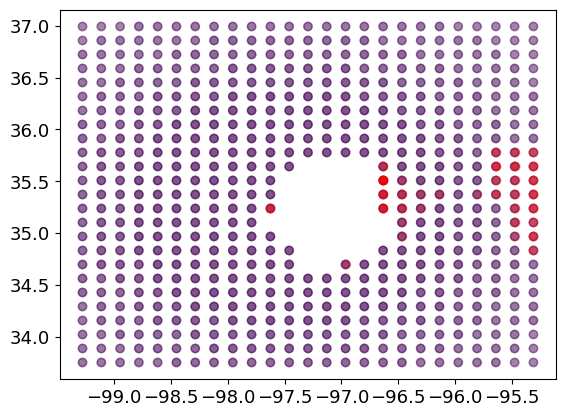

In [87]:
k = 13

mkind = np.where((kind==k), True, False)

lats = lat[mkind&mask]
lons = lon[mkind&mask]
vals  = value[mkind&mask]

plt.scatter(lons,lats, c=vals, alpha=0.1)


mkind = np.where((kind==k), True, False)

lats = lat[mkind&fmask]
lons = lon[mkind&fmask]
vals  = value[mkind&fmask]

plt.scatter(lons,lats, c='r', alpha=0.2)


In [75]:
len(outlier[fmask])

3526

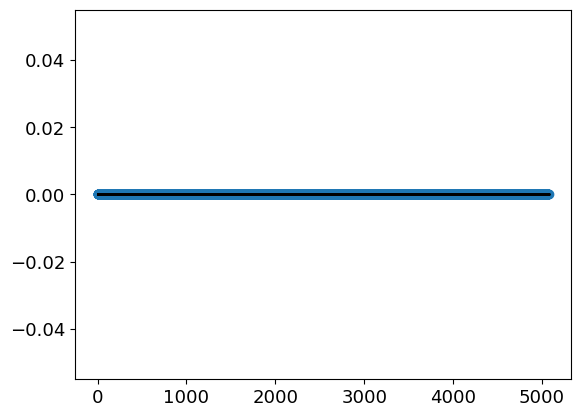

In [22]:
val = value[kind==13]

plt.scatter(range(len(val)), val)


val = value[mask]

plt.scatter(range(len(val)), val, color='k', s=1)


In [11]:
os.rename(os.path.join(path, "Prior.nc"), newPriorFile)

In [17]:

ob_f = pd.read_csv(obs_file)
  
# Initialize a bunch of containers, they get converted to numpy arrays below

lat     = np.empty((0))
lon     = np.empty((0))
dates   = np.empty((0))
value   = np.empty((0))
kind    = np.empty((0))
height  = np.empty((0))
elev    = np.empty((0))
az      = np.empty((0))
err_var = np.empty((0))
idx     = np.empty((0))

analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
 
print("\n --> ComputeHx:  Reading in model state for HxF at %s \n" %  (analysis_time.strftime("%Y-%m-%d %H:%M:%S")))

# read from history files
  
Hxfm = np.empty((0,state.ne))  # need to init this here cause need size of ensemble


# if you want only a subset of observations, this will do that. Make sure to add additional options as the file contains more data
if len(obs_include) > 0:
    include = []
    for ob in obs_include:
        if ob == "DBZ0_W":
            include.append(14)
            ob_f.loc[ob_f.kind==13, 'kind'] = 14 # recode all clear air obs to be vertical velocity
                 
        if ob == "DBZ0":
            include.append(13)
        if ob == "DBZ":
            include.append(12)
        if ob == 'VR':
            include.append(11)

    ob_f = ob_f[ob_f['kind'].isin(include)]

#set spatial and temporal conditions to index the observation data 
g_lat_max = state.late[:].max()
g_lat_min = state.late[:].min()
g_lon_max = state.lone[:].max()
g_lon_min = state.lone[:].min()
g_alt_max = max(state.zc.data[:]) + state.hgt
g_alt_min = min(state.zc.data[:]) + state.hgt

dt     = DT.timedelta(0,int(window/2))
begin  = cftime.date2num(analysis_time - dt, sec_utime)
ending = cftime.date2num(analysis_time + dt, sec_utime)

data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) & \
          (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
          (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)

subdata = ob_f[data_mask]




if len(subdata.index) > 0:
    print("\n --> ComputeHx:  Total number of obs found at search time: %s \n" % len(subdata.index))
else:
    print("\n --> ComputeHx:  No obs found at search time:  %s exiting......\n" % (analysis_time))
    sys.exit(0)

# Compute Hxfs from 

#### IF DOING ONE OB TEST, USE THIS 
# idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
#                                                              np.array([subdata['kind']]), 
#                                                              np.array([subdata['lat']]),                                         
#                                                              np.array([subdata['lon']]),
#                                                              np.array([subdata['height']]),
#                                                              np.array([subdata['elevation']]), 
#                                                              np.array([subdata['azimuth']]))

#### IF DOING NORMAL EXPERIMENT, USE THIS
idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
                                                           subdata['kind'].values, 
                                                           subdata['lat'].values,                                         
                                                           subdata['lon'].values,
                                                           subdata['height'].values,
                                                           subdata['elevation'].values,
                                                           subdata['azimuth'].values)
nobs = np.size(idx) 
err_var = np.append(err_var, subdata['error_var'].values[idx])   
value   = np.append(value,   subdata['value'].values[idx])
dates   = np.append(dates,   subdata['date'].values[idx])

for key in obs_error.keys():
    print_once = True
    for n, item in enumerate(kind):
        if int(item) == int(key):
            err_var[n] = obs_error[key][1]**2.0
        if print_once:
            print("\n --> ComputeHx:  Changing %s observational error to:  %s" % (obs_error[key][0],obs_error[key][1]))
            print_once = False

# Here we choose to create a coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
# The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid


xs, ys = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
zs     = height

Hxfbar = np.average(Hxf,axis=1)

# We dont use this flag (is supposed to be a flag to tell one whether the obs is used for verification or assimilation, or thrown out)
status = np.ones(nobs)

# Compute standard deviation of model priors versus observation
outlier = np.abs(Hxfbar-value)/np.sqrt(Hxf.var(ddof=1,axis=1)+err_var)


 --> ComputeHx:  Reading in model state for HxF at 2024-05-08 20:00:00 


 --> ComputeHx:  Total number of obs found at search time: 7026 

 calcHx:  OBS   LAT MIN/MAX:   33.618283845221214 36.99285857702675
 calcHx:  MODEL LAT MIN/MAX:   33.62953247125773 37.058100351453895
 calcHx:  OBS   LON MIN/MAX:   -99.44232358785833 -95.31078620011496
 calcHx:  MODEL LON MIN/MAX:   -99.42855179656584 -95.2309098106186
 calcHx:  OBS   HGT MIN/MAX:   144.60763863317047 43511.96395013844
 calcHx:  MODEL HGT MIN/MAX:   75.0 19700.0

 --> ComputeHx:  Changing VR observational error to:  3.0

 --> ComputeHx:  Changing DBZ observational error to:  7.0

 --> ComputeHx:  Changing DBZ0 observational error to:  5.0

 --> ComputeHx:  Changing DBZ0_W observational error to:  0.5


In [22]:
kind[kind==11]

array([11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 11, 11, 11, 11, 11, 11, 11])

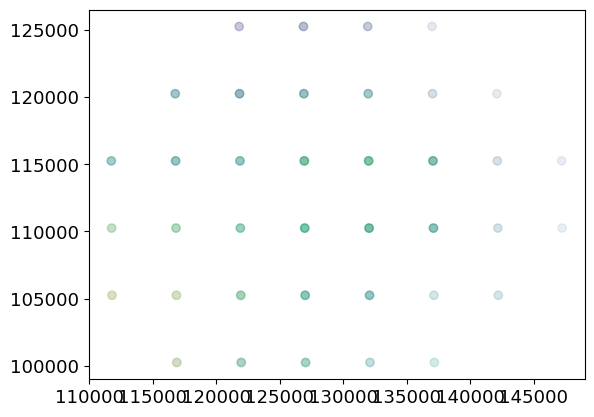

In [21]:
plt.scatter(xs[kind==11], ys[kind==11], c=value[kind==11], alpha=0.1)

In [18]:
mask = outlier <= 3

np.unique(kind[mask])

array([12, 14])

In [36]:
def get_departures(state, obs_include, analysis_time):

    ob_f = pd.read_csv(obs_file)
    # read from history files
    Hxfm = np.empty((0,state.ne))  # need to init this here cause need size of ensemble
    # if you want only a subset of observations, this will do that. Make sure to add additional options as the file contains more data
    if len(obs_include) > 0:
        include = []
        for ob in obs_include:
          if ob == "DBZ0":
             include.append(13)
          if ob == "DBZ":
             include.append(12)
          if ob == 'VR':
             include.append(11)
    ob_f = ob_f[ob_f['kind'].isin(include)]
    
    #set spatial and temporal conditions to index the observation data 
    g_lat_max = state.late[:].max()
    g_lat_min = state.late[:].min()
    g_lon_max = state.lone[:].max()
    g_lon_min = state.lone[:].min()
    g_alt_max = max(state.zc.data[:]) + state.hgt
    g_alt_min = min(state.zc.data[:]) + state.hgt
    
    dtime  = dt.timedelta(0,int(window/2))
    begin  = cftime.date2num(analysis_time - dtime, sec_utime)
    ending = cftime.date2num(analysis_time + dtime, sec_utime)
    
    data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) & \
              (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
              (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)
    
    subdata = ob_f[data_mask]
    idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
                                                                   subdata['kind'].values, 
                                                                   subdata['lat'].values,                                         
                                                                   subdata['lon'].values,
                                                                   subdata['height'].values,
                                                                   subdata['elevation'].values,
                                                                   subdata['azimuth'].values)

    value   = np.empty((0))
    value   = np.append(value,   subdata['value'].values[idx])
    dep = value[:, np.newaxis] - Hxf
    return dep

In [38]:
start = dt.datetime(2024,5,8,20)
end = dt.datetime(2024,5,8,21)
tdel = dt.timedelta(minutes=5)

for time in np.arange(start, end+tdel, tdel):
    analysis_time = time.astype(dt.datetime)
    myDTstring = analysis_time.strftime("%Y,%m,%d,%H,%M,%S")

    with open(f'{fpath}{name}.exp', 'rb') as f:
        exper = json.load(f)
    files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

    state = ens.read_CM1_ens(files, exper, state_vector=state_vector.Hxf, DateTime=analysis_time)   
    ens.ens_CM1_C2A(state)
    ens.ens_CM1_coords(state)
    
    obs_file = exper['radar_obs']
    window = int(exper['DA_PARAMS']['assim_window'])
    
    obs_error = exper['DA_PARAMS']['obs_errors']
    outlier = exper['DA_PARAMS']['outlier']

    dep = get_departures(state, ['DBZ0'], analysis_time)

    if analysis_time == start:
        full = dep.copy()
    else:
        full = np.concat([full, dep], axis=0)

    del state
        


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 2700 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/test/member001/cm1rst_000003.nc

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:00:00 


 Wallclock time for serial read netCDF ensemble files: 2.113  sec

 Wallclock time to convert from C to A grid: 0.436  sec

 Wallclock time to read arrays from netCDF ensemble files: 2.694  sec

 Wallclock time to convert from C to A grid: 0.436  sec

 Wallclock time to create coordinates: 0.0  sec
 calcHx:  OBS   LAT MIN/MAX:   33.618283845221214 36.99285857702675
 calcHx:  MODEL LAT MIN/MAX:   33.62953247125773 37.058100351453895
 calcHx:  OBS   LON MIN/MAX:   -99.44232358785833 -95.31078620011496
 calcHx:  MODEL LON MIN/MAX:   -99.42855179656584 -95.2309098106186
 calcHx:  OBS   HGT MIN/MAX:   144.60763863317047 43511.96395013844
 calcHx:  MODEL HGT MIN/MAX:   75.0 19700.0

 ==> Fin

In [28]:
new = np.concat([dep, dep2], axis=0)

In [48]:
np.shape(full)

(67048, 36)

In [49]:
len(full.flatten())

2413728

In [47]:
counts

array([    2,     8,    13,    10,     3,     0,     0,     1,     4,
           9,    14,    10,     4,    21,    65,    90,   126,   130,
         220,   423,   785,  1526,  2669,  4313,  7050, 10473])

27969
27969


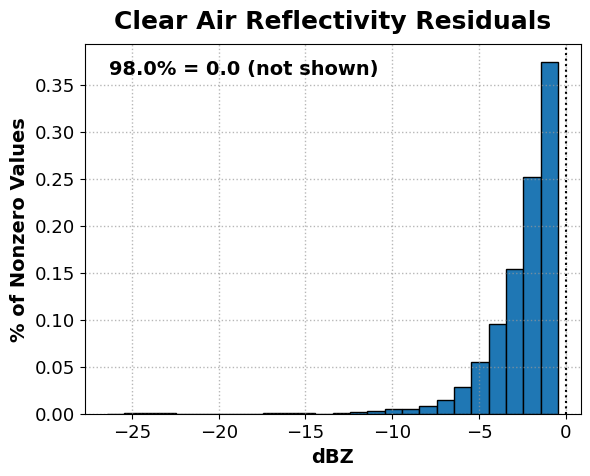

In [66]:
eqzero = 100*list(full.flatten()).count(0.0)/len(full.flatten())
bins = np.arange(np.min(full), 0, 1)
counts, bin_edges  = np.histogram(full.flatten(), bins=bins)
#ncounts, nbin_edges  = np.histogram(full.flatten(), bins=bins)

print(sum(counts))
print(sum(ncounts))

bin_c= (bin_edges[:-1] + bin_edges[1:]) / 2
nbin_c = (nbin_edges[:-1] + nbin_edges[1:]) / 2

fig=plt.figure()
plt.title('Clear Air Reflectivity Residuals', weight='bold', y=1.02)
plt.bar(bin_c, counts/sum(counts), width=1, edgecolor='k')

plt.text(0.05, .96, f"{eqzero:.1f}% = 0.0 (not shown)",va='top', fontsize=14, weight='bold', transform=plt.gca().transAxes)

plt.xlabel('dBZ')
plt.ylabel('% of Nonzero Values')
plt.axvline(0, color='k', ls=':')
plt.grid(ls=":", alpha=0.7)

In [15]:

myDTstring = '2024,05,08,19,15,00'

with open('/work/jessica.mcdonald/CM1_LETKF_2025/AllExperiments/DBZ/DBZ.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 19:15:00

 ==> FindRestartFile:  Found time 0 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/AllExperiments/DBZ/member001/cm1rst_000000.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 19:15:00 


 Wallclock time for serial read netCDF ensemble files: 19.147  sec

 Wallclock time to convert from C to A grid: 0.915  sec

 Wallclock time to create ensemble means: 1.321  sec

 Wallclock time to read arrays from netCDF ensemble files: 22.163  sec

 Wallclock time to create coordinates: 0.0  sec


(80000.0, 250000.0)

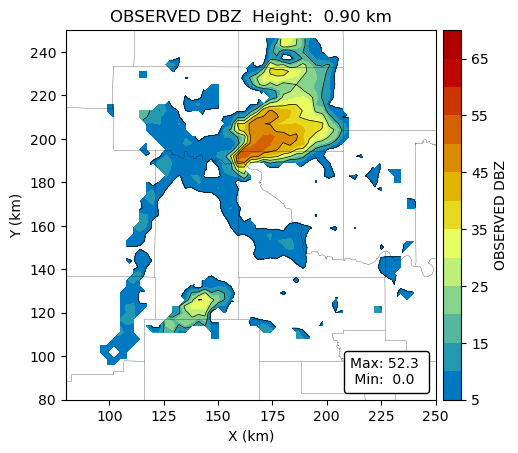

In [25]:
fig,ax=plt.subplots(1)
mfld = N.ma.masked_less_equal(f3d[5,:,:], 0.0)
label = "OBSERVED DBZ"
PLOT_ONE(mfld, x2d, y2d, map, clevels=clevels, height=state.zc[5], label = label, ax = ax, \
       counties=True, cmap=ctables.REF_default, zoom = zoom)
ax.set_xlim(80*1000, 250*1000)
ax.set_ylim(80*1000, 250*1000)

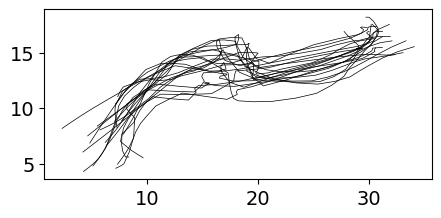

In [16]:
t=10
fig=plt.figure(figsize=(5,5))
ax = plt.gca()
ax.set_aspect('equal')
for mem in np.arange(1,21,1):
    #try:
    cm1 = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member{mem:03d}/cm1rst_{t:06d}.nc',decode_timedelta= True)
   
    
    ax.plot(cm1.ua[0,:30,0,-1],cm1.va[0,:30,0,-1],lw=0.5, color='k' )
    #ax.plot(cm1.theta[0,:30,0,-1],cm1.zh[:30],lw=0.5, color='k' )
    cm1.close()
    

# modifying warm bubble code

In [12]:
#import datetime as dt

import sys
sys.path.append('src/') 

import cftime 
from datetime import datetime as py_datetime

import time
import datetime
from datetime import datetime as py_datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import ens

# from contextlib import redirect_stdout
# import io
def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

import netCDF4 as ncdf
import numpy as N
import math as M
import glob
import sys
import os
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime
from subprocess import *
#from cbook2 import *
import plot_src.ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial

from mpl_toolkits.basemap import Basemap

sys.path.append('src/fsrc/') 
from fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d

import state_vector as state

from ens import read_CM1_ens

def fnormal(prng=N.random, scale=1.0, size=(1,)):
  return prng.normal(scale=scale, size=size)

def funiform(prng=N.random, scale=1.0, size=(1,)):
    return scale*(0.5 - prng.uniform(size=size))

In [ ]:
work/jessica.mcdonald/CM1_LETKF_2025/experiments/shiftCooked_CM1/shiftCooked_CM1.exp

In [13]:
#experiment = 'AllExperiments/DBZ'
myDTstring = '2024,05,08,19,30,00'

with open(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/letkf.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False)#,prior=True)

ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens.ens_CM1_coords(ens_state)


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 19:30:00

 ==> FindRestartFile:  Found time 0 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/Control/member001/cm1rst_000000.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 19:30:00 


 Wallclock time for serial read netCDF ensemble files: 27.632  sec

 Wallclock time to convert from C to A grid: 0.797  sec

 Wallclock time to create ensemble means: 1.345  sec

 Wallclock time to read arrays from netCDF ensemble files: 30.547  sec

 Wallclock time to create coordinates: 0.0  sec


In [89]:
centerx + (xypert[:,0,n]*max_x_offset)

array([ 87879.05893411,  92250.62123029, 103270.5476856 ])

In [92]:
xypert[0,0,n]*max_x_offset*2

np.float64(-24241.882131789396)

In [16]:
#def ens_IC_warm_bubble(ens_state, plot=False, writeout=False):

# These values are set in the experiment dictionary created at the begining of the run

nb           = ens_state.experiment['INIT']['nb']
wpert        = ens_state.experiment['INIT']['wpert']
upert        = ens_state.experiment['INIT']['upert']
vpert        = ens_state.experiment['INIT']['vpert']
tpert        = ens_state.experiment['INIT']['tpert'] 
tdpert       = ens_state.experiment['INIT']['tdpert']
qvpert       = ens_state.experiment['INIT']['qvpert']
centerx      = ens_state.experiment['INIT']['centerx']
centery      = ens_state.experiment['INIT']['centery']
max_x_offset = ens_state.experiment['INIT']['max_x_offset']
max_y_offset =ens_state.experiment['INIT']['max_y_offset']
# zbmin        = ens_state.experiment['INIT']['zbmin']
# zbmax        = ens_state.experiment['INIT']['zbmax']
bhrad        = ens_state.experiment['INIT']['rbubh']
bvrad        = ens_state.experiment['INIT']['rbubv']
r_seed       = ens_state.experiment['INIT']['r_seed']

print(upert, wpert, vpert, tpert, tdpert)

klevel      = 4   # level to plot perturbations
me          = int(ens_state.ne/2)  # which member to plot

np.random.seed(r_seed)
xypert = (np.random.rand(nb,2,ens_state.ne)*2)-1

# calculate additional random modifications to T and W, up to 75% the size of the prescribed perturbation   
t_adjust = (xypert[0][0])
rand_t = (tpert*.50) * t_adjust

for n in np.arange(ens_state.ne):

    # additional edit - add the first x and y perturbations, but halved, to ALL bubbles
    xshift = xypert[0,0,n]*max_x_offset*1.5 
    yshift = xypert[0,1,n]*max_y_offset*1.5

    xb = centerx + (xypert[:,0,n]*max_x_offset) + xshift # these are length nb
    yb = centery + (xypert[:,1,n]*max_y_offset) + yshift
    zb = zbmax*np.ones(xb.shape) + ens_state.hgt
    
    ni, nj, nk = ens_state['nx'],ens_state['ny'],ens_state['nz']
    xh= np.tile(ens_state['xc'][:], (nj*nk,1)).reshape(nk, nj, ni)
    yh= np.tile(ens_state['yc'][:], (ni*nk,1)).reshape(nk, nj, ni).swapaxes(1,2) 
    zh= ens_state['zc'][:, np.newaxis, np.newaxis]
    
    pert = np.zeros([nk,nj,ni])
    
    for b in range(nb): # this uses the equation from CM1 to create the warm bubbles
        beta = np.sqrt( ((xh- xb[b])/bhrad)**2 + ((yh- yb[b])/bhrad)**2 + ((zh - zb[b])/bvrad)**2 )
        mask = beta < 1
        pert[mask]+= (np.cos(0.5*np.pi*beta[mask])**2)
    
    pospert = (pert - pert.min()) / (pert.max()-pert.min())
    neupert = 0.5 - pospert
  
    print(f'\n ==> ens_IC_warm_bubble: ens member {n+1} max T perturbation = {tpert+rand_t[n]} ')
    
  #   if tpert > 0.0:
  #       ens_state['TH'][n]  = ens_state['TH'][n]*0
  #       ens_state['TH'][n] = ens_state['TH'][n] + (tpert+rand_t[n])*pospert
  #   if wpert > 0.0:
  #       ens_state['W'][n]  = ens_state['W'][n]  + wpert*pospert        
  #   if upert > 0.0:
  #       ens_state['U'][n]  = ens_state['U'][n]  + upert*neupert
  #   if vpert > 0.0:
  #       ens_state['V'][n]  = ens_state['V'][n]  + vpert*neupert

  #   if tdpert > 0.0 and qvpert < 0.01:                                  # Dont do both, prefer saturations...
  #       p0 = 1000.*(ens_state['PI0'][n])**3.508
  #       e  = ens_state['QV'][n]*p0/(0.622+ens_state['QV'][n])                       # vapor pressure
  #       e  = np.clip(e, 0.001, 100.)                                     # avoid problems near zero
  #       td = 273.16 + ( 243.5 / ( 17.67/np.log(e/6.112) - 1.0 ) )        # Bolton's approximation
  #       td = np.clip(td + tdpert*pospert, 200.0, (p0*ens_state['TH'][n])-0.1)  # make sure Td is < T
        
  #       # Transform back
  #       tdc = td - 273.16
  #       e   = 6.112 * np.exp(17.67*tdc / (tdc+243.5) )                   # Bolton's approximation
  #       ens_state['QV'][n] = 0.622*e / (p0-e)
  
  # # If qvpert > 0, essentially saturate the regions where the warm bubbles are.
  #   if qvpert > 0.0:
  #       tc = (ens_state['PI0'][n]*ens_state['TH'][n]) - 273.16
  #       p0 = 1000.*(ens_state['PI0'][n])**3.508
  #       e  = 6.112 * np.exp(17.67*tc / (tc+243.5) )  
  #       qvs = (0.622*e)/ (p0-e)      
  #       ens_state['QV'][n] = np.where(pospert > 0.0, (100.-qvpert)*qvs/100., ens_state['QV'][n])

# Write ensemble back out
  # if writeout:
  #   write_CM1_ens(ens_state, writeEns=True, writeFcstMean=True, overwrite=True)

0.0 1.0 0.0 3.0 0.0


NameError: name 'zbmax' is not defined

In [20]:
nb           = ens_state.experiment['INIT']['nb']
wpert        = ens_state.experiment['INIT']['wpert']
upert        = ens_state.experiment['INIT']['upert']
vpert        = ens_state.experiment['INIT']['vpert']
tpert        = ens_state.experiment['INIT']['tpert']
tdpert       = ens_state.experiment['INIT']['tdpert']
qvpert       = ens_state.experiment['INIT']['qvpert']
centerx      = ens_state.experiment['INIT']['centerx']
centery      = ens_state.experiment['INIT']['centery']
centerz      = ens_state.experiment['INIT']['centerz']
max_x_offset = ens_state.experiment['INIT']['max_x_offset']
max_y_offset = ens_state.experiment['INIT']['max_y_offset']
#zbmin        = ens_state.experiment['INIT']['zbmin']
#zbmax        = ens_state.experiment['INIT']['zbmax']
bhrad        = ens_state.experiment['INIT']['rbubh']
bvrad        = ens_state.experiment['INIT']['rbubv']
r_seed       = ens_state.experiment['INIT']['r_seed']

print(upert, wpert, vpert, tpert, tdpert)

klevel      = 4   # level to plot perturbations
me          = int(ens_state.ne/2)  # which member to plot

np.random.seed(r_seed)
xypert = (np.random.rand(nb,2,ens_state.ne)*2)-1

# calculate additional random modifications to T, up to 75% the size of the prescribed perturbation   
t_adjust = (xypert[0][0])
rand_t = (tpert*.75) * t_adjust

for n in np.arange(ens_state.ne):

    # randomized shift for the whole bubble cluster
    xshift = xypert[0,0,n]*max_x_offset*1.5 
    yshift = xypert[0,1,n]*max_y_offset*1.5

    xb = centerx + (xypert[:,0,n]*max_x_offset) +xshift# these are length nb
    yb = centery + (xypert[:,1,n]*max_y_offset) +yshift
    zb = centerz*np.ones(xb.shape) + ens_state.hgt
    
    ni, nj, nk = ens_state['nx'],ens_state['ny'],ens_state['nz']
    xh= np.tile(ens_state['xc'][:], (nj*nk,1)).reshape(nk, nj, ni)
    yh= np.tile(ens_state['yc'][:], (ni*nk,1)).reshape(nk, nj, ni).swapaxes(1,2) 
    zh= ens_state['zc'][:, np.newaxis, np.newaxis]
    
    pert = np.zeros([nk,nj,ni])
    
    for b in range(nb): # this uses the equation from CM1 to create the warm bubbles
        beta = np.sqrt( ((xh- xb[b])/bhrad)**2 + ((yh- yb[b])/bhrad)**2 + ((zh - zb[b])/bvrad)**2 )
        mask = beta < 1
        pert[mask]+= (np.cos(0.5*np.pi*beta[mask])**2)
    
    pospert = (pert - pert.min()) / (pert.max()-pert.min())
    neupert = 0.5 - pospert
  
    print(f'\n ==> ens_IC_warm_bubble: ens member {n+1} max T perturbation = {tpert+rand_t[n]} ')
    
    if tpert > 0.0:
        ens_state['TH'][n]  = 0#ens_state['TH'][n]*0
        ens_state['TH'][n] = ens_state['TH'][n] + (tpert+rand_t[n])*pospert
    if wpert > 0.0:
        ens_state['W'][n]  = ens_state['W'][n]  + wpert*pospert        
    if upert > 0.0:
        ens_state['U'][n]  = ens_state['U'][n]  + upert*neupert
    if vpert > 0.0:
        ens_state['V'][n]  = ens_state['V'][n]  + vpert*neupert

    if tdpert > 0.0 and qvpert < 0.01:                                  # Dont do both, prefer saturations...
        p0 = 1000.*(ens_state['PI0'][n])**3.508
        e  = ens_state['QV'][n]*p0/(0.622+ens_state['QV'][n])                       # vapor pressure
        e  = np.clip(e, 0.001, 100.)                                     # avoid problems near zero
        td = 273.16 + ( 243.5 / ( 17.67/np.log(e/6.112) - 1.0 ) )        # Bolton's approximation
        td = np.clip(td + tdpert*pospert, 200.0, (p0*ens_state['TH'][n])-0.1)  # make sure Td is < T
        
        # Transform back
        tdc = td - 273.16
        e   = 6.112 * np.exp(17.67*tdc / (tdc+243.5) )                   # Bolton's approximation
        ens_state['QV'][n] = 0.622*e / (p0-e)

0.0 1.0 0.0 3.0 0.0

 ==> ens_IC_warm_bubble: ens member 1 max T perturbation = 5.108287205090463 

 ==> ens_IC_warm_bubble: ens member 2 max T perturbation = 0.8282709749123849 


/tmp/ipykernel_1934483/1411555954.py:53: RuntimeWarning: invalid value encountered in divide
  pospert = (pert - pert.min()) / (pert.max()-pert.min())



 ==> ens_IC_warm_bubble: ens member 3 max T perturbation = 0.9724836062318878 

 ==> ens_IC_warm_bubble: ens member 4 max T perturbation = 2.6015667167323544 

 ==> ens_IC_warm_bubble: ens member 5 max T perturbation = 0.9266431482528859 

 ==> ens_IC_warm_bubble: ens member 6 max T perturbation = 4.604419922764939 

 ==> ens_IC_warm_bubble: ens member 7 max T perturbation = 2.259647952601774 

 ==> ens_IC_warm_bubble: ens member 8 max T perturbation = 4.053038874415986 

 ==> ens_IC_warm_bubble: ens member 9 max T perturbation = 3.309036663305208 

 ==> ens_IC_warm_bubble: ens member 10 max T perturbation = 4.228676739112286 

 ==> ens_IC_warm_bubble: ens member 11 max T perturbation = 4.707856983686357 

 ==> ens_IC_warm_bubble: ens member 12 max T perturbation = 2.5328387506853463 

 ==> ens_IC_warm_bubble: ens member 13 max T perturbation = 2.2613489969341027 

 ==> ens_IC_warm_bubble: ens member 14 max T perturbation = 2.9536151933806316 

 ==> ens_IC_warm_bubble: ens member 15 m

In [39]:
zb

array([120000., 120000., 120000.])

In [38]:
zh - zb[0]

array([[[-119900.        ]],

       [[-119693.33334351]],

       [[-119473.33331299]],

       [[-119240.        ]],

       [[-118993.33337402]],

       [[-118733.33325195]],

       [[-118459.99987793]],

       [[-118173.33325195]],

       [[-117873.33325195]],

       [[-117560.        ]],

       [[-117233.33300781]],

       [[-116893.33325195]],

       [[-116540.        ]],

       [[-116173.33349609]],

       [[-115793.33300781]],

       [[-115400.        ]],

       [[-114993.33349609]],

       [[-114573.33349609]],

       [[-114140.        ]],

       [[-113693.33300781]],

       [[-113233.33300781]],

       [[-112760.        ]],

       [[-112273.33300781]],

       [[-111773.33300781]],

       [[-111260.        ]],

       [[-110733.33398438]],

       [[-110193.33398438]],

       [[-109640.        ]],

       [[-109073.33300781]],

       [[-108493.33300781]],

       [[-107900.        ]],

       [[-107300.        ]],

       [[-106700.        ]],

       [[-

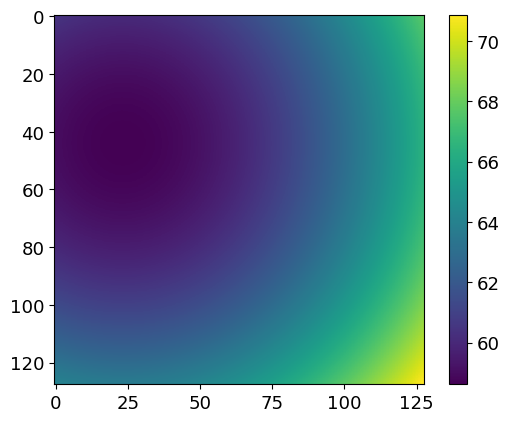

In [32]:
plt.imshow(beta[10])
plt.colorbar()

In [24]:
pert[mask]+= (np.cos(0.5*np.pi*beta[mask])**2)

In [27]:
pert.min()

np.float64(0.0)

In [16]:
import colormaps as cmaps
import plot_src.ctables as ctables

#centerx      = ens_state.experiment['INIT']['centerx']
#centery      = ens_state.experiment['INIT']['centery']


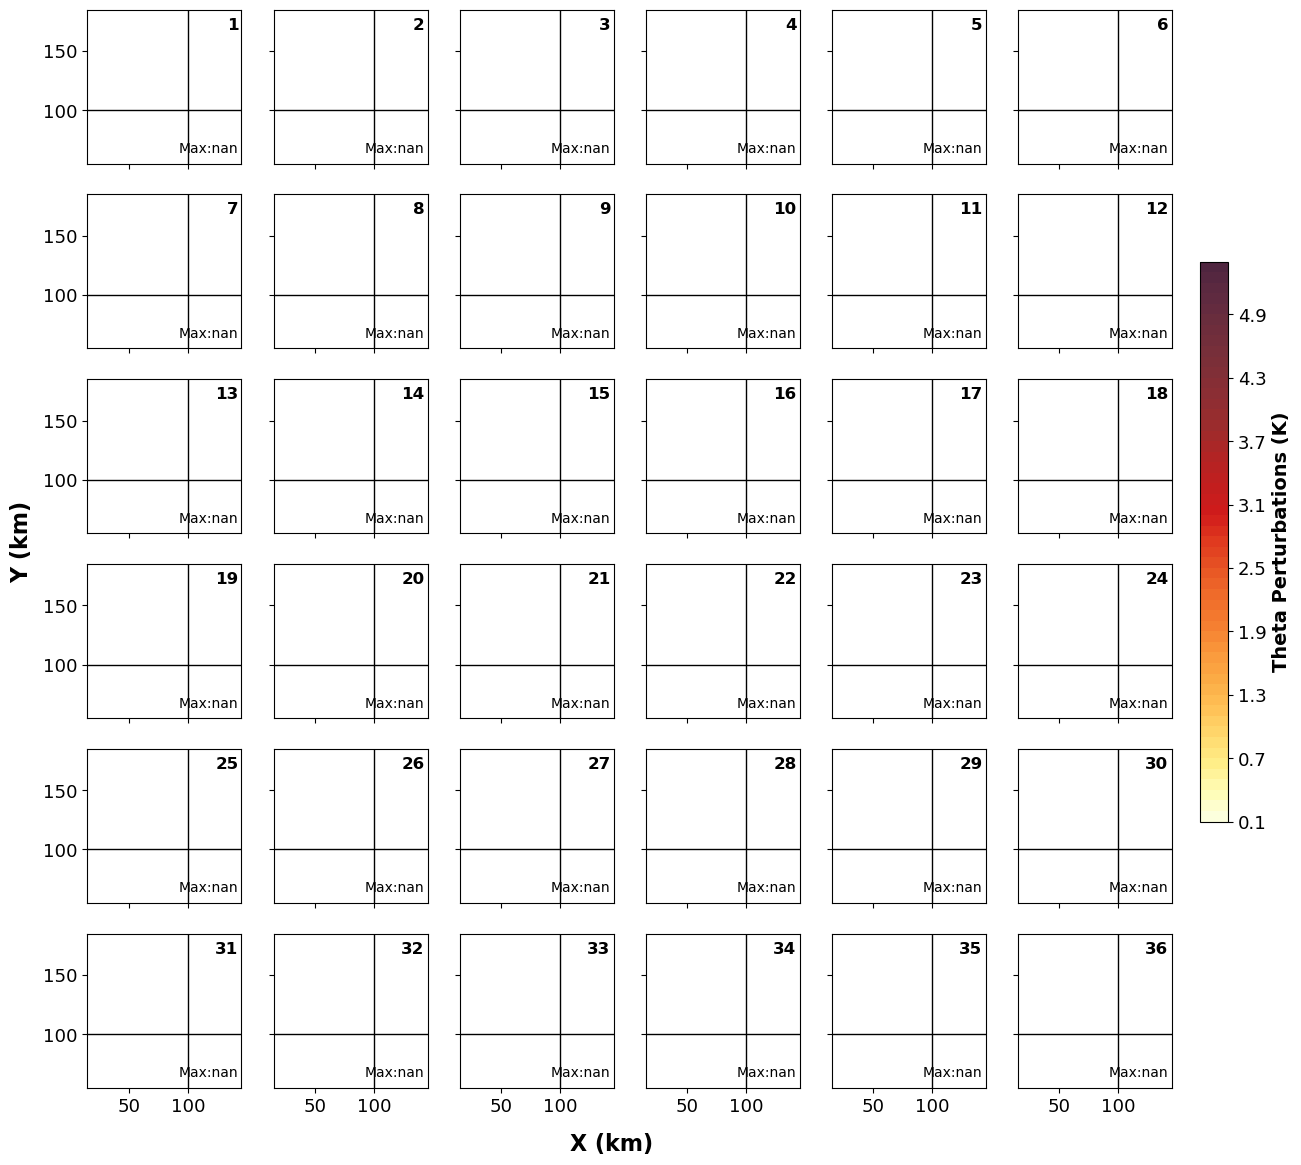

In [18]:


ne = ens_state.ne
height = 1 # in km
cref = True
obs = True
plot_width = 130 # in km 
smooth_obs = True

x = ens_state.xc[:]/1000
y = ens_state.yc[:]/1000
z = ens_state.zc[:]/1000

zi = findnearest(z, height) # if cref is chosen, this isn't used
# prepping the observations

fig,axes = plt.subplots(6,6, figsize=(14,14), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

thp = ens_state['TH'][:] -ens_state['TH'][:,:,-1,0][:,:,np.newaxis, np.newaxis]
w = ens_state['W'][:]#

full_field= (thp).sum(axis=(0,1))
yc, xc = np.where(full_field == full_field.max())

yc,xc = centery/1000, centerx/1000

if plot_width!= None:
    # axes[0,0].set_xlim(x[xc]-plot_width/2, x[xc]+plot_width/2) # shift plot 20 km to the right, it just looks better
    # axes[0,0].set_ylim(y[yc]-plot_width/2, y[yc]+plot_width/2)

    axes[0,0].set_xlim(xc-plot_width/2, xc+plot_width/2) # shift plot 20 km to the right, it just looks better
    axes[0,0].set_ylim(yc-plot_width/2, yc+plot_width/2)


xx,yy = np.meshgrid(x,y)
for i,ax in enumerate(axes.flatten()):
     # -1 is the mean member, so always skip it

    

    im=ax.contourf(x,y, thp[i,zi,:,:],cmap=cmaps.redy3,levels=np.arange(.1, 5.5, .1))    
    ax.contour(x,y, thp[-1,zi,:,:], levels=np.arange(.1, 5.1, .5), colors='k', linewidths=0.5, alpha=0.8)

    #ax.contour(x,y, w[i, zi], levels=[0,.5, 1, 1.5, 2], linewidths=1, colors='b')

    #ax.scatter(xx.flatten(), yy.flatten(), s=0.5, color='k', alpha=0.2)

    ax.axhline(100, color='k', lw=1)
    ax.axvline(100, color='k', lw=1)

    
    
    ax.text(0.98, .05, f'Max:{thp[i].max():.1f}', va='bottom',ha='right', fontsize=10, transform=ax.transAxes)
    ax.text(0.98, .95, f'{i+1}', ha='right', va='top',fontsize=12, transform=ax.transAxes, weight='bold')

# xwidth = (axes[0,0].get_position().x1-axes[0,0].get_position().x0)*.2
# ywidth = (axes[0,0].get_position().y1-axes[0,0].get_position().y0)*.4
# plt.subplots_adjust(hspace = ywidth, wspace = ywidth)

cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Theta Perturbations (K)', weight='bold')

#plt.tight_layout()

fig.text(0.5, 0.07, 'X (km)', ha='center', va='center', weight='bold', fontsize=16);
fig.text(0.07,0.5, r'Y (km)', weight='bold', va='center', fontsize=16, rotation='vertical');

[31] [43]


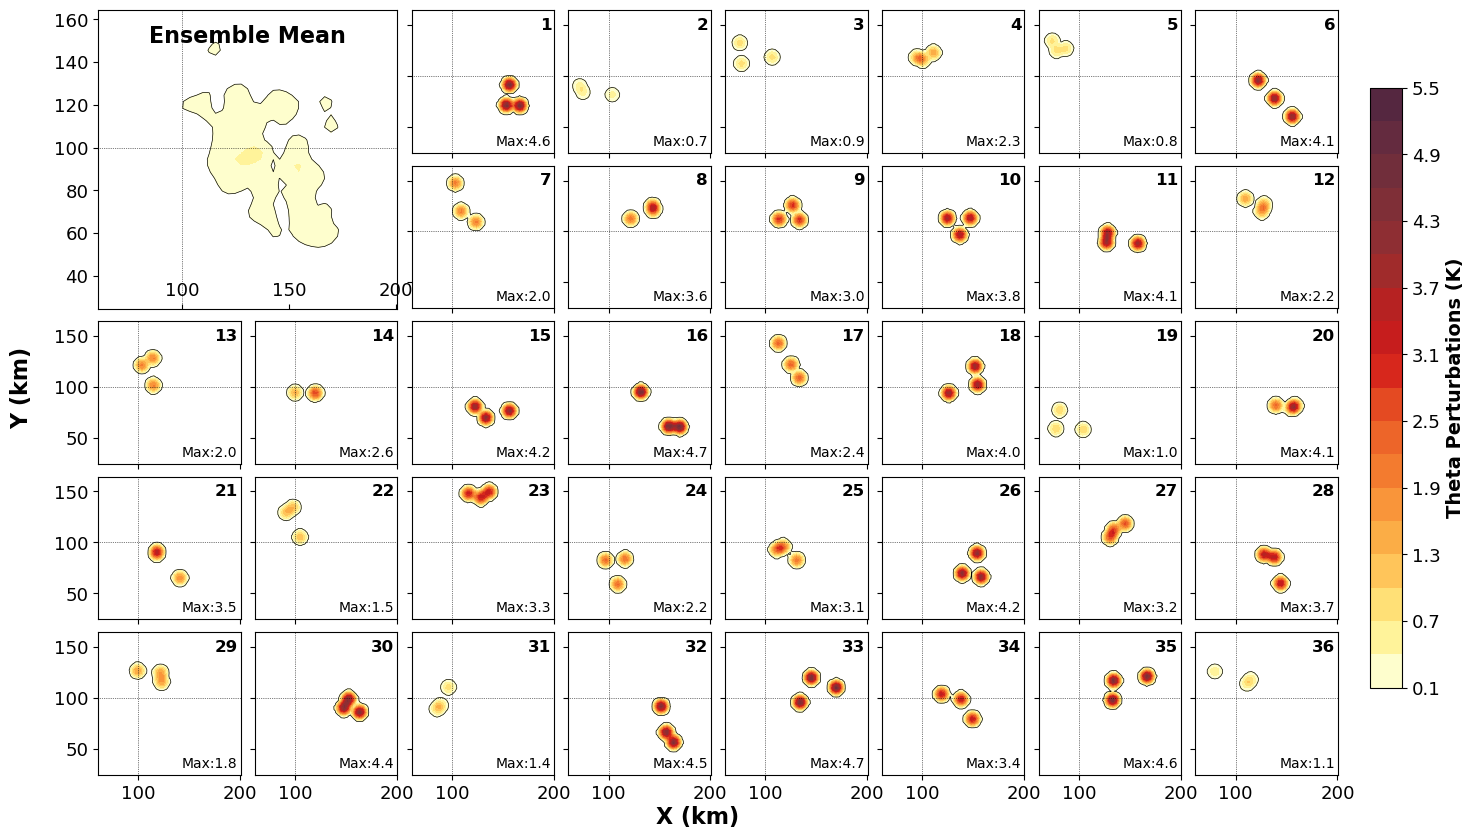

In [283]:

ne = ens_state.ne
height = 1 # in km
#cref = True
#obs = True
plot_width = 140#220 # in km 


thp = ens_state['TH'][:] -ens_state['TH'][:,:,-1,0][:,:,np.newaxis, np.newaxis]


fig, axes = plt.subplots(5,8, sharex=True, sharey=True, figsize=(16,10), subplot_kw={'aspect':'equal'})
gs = axes[0,1].get_gridspec()
for ax in [axes[0,0], axes[0,1], axes[1,0], axes[1,1]]:
    ax.remove()

axbig = fig.add_subplot(gs[0:2, 0:2])
axbig.set_aspect('equal')
axbig.tick_params(axis="x", direction="in", pad=-20)

ax_list = []# axes.flatten
for n,ax in enumerate(axes.flatten()):
    if n not in [0,1,8,9]:
        ax_list.append(ax)


x = ens_state.xc[:]/1000
y = ens_state.yc[:]/1000
z = ens_state.zc[:]/1000

zi = findnearest(z, height) # if cref is chosen, this isn't used

mean_field = thp[-1, zi]
smth = gaussian_filter(mean_field, sigma=3)
yc, xc = np.where(smth == smth.max())



# now shift 
# shift = 0 #km
#xc = xc[0] - int(20/(ens_state.dx/1000))
#yc = yc[0] + int(25/(ens_state.dy/1000))


axbig.scatter(x[xc],y[yc])

print(yc, xc)

if plot_width!= None:
    axes[-1,-1].set_xlim(x[xc]-plot_width/2, x[xc]+plot_width/2) # shift plot 20 km to the right, it just looks better
    axes[-1,-1].set_ylim(y[yc]-plot_width/2, y[yc]+plot_width/2)
axbig.set_xlim(x[xc]-plot_width/2, x[xc]+plot_width/2) 
axbig.set_ylim(y[yc]-plot_width/2, y[yc]+plot_width/2)


### obs
axbig.contourf(x,y,mean_field, cmap=cmaps.redy3,levels=np.arange(.1, 5.5, .3))
axbig.contour(x,y, mean_field, colors='k', linewidths=0.5, levels=np.arange(.1, 5.5, 5))
axbig.text(0.5, .95, 'Ensemble Mean', ha='center', va='top', fontsize=16, weight='bold', transform=axbig.transAxes)

axbig.axhline(100, color='k', lw=.5, ls=':')
axbig.axvline(100, color='k', lw=.5, ls=':')



for i,ax in enumerate(ax_list):

    
    im=ax.contourf(x,y,thp[i,zi,:,:],cmap=cmaps.redy3,levels=np.arange(.1, 5.5, .3)) 
    #ax.contourf(x,y, dbz, colors=['C0'], levels=[5,100]) 
    ax.contour(x,y, thp[i,zi,:,:], colors='k', levels=np.arange(.1, 5.5, 5), linewidths=0.5)
    ax.text(0.98, .03, f'Max:{thp[i,zi,:,:].max():.1f}', va='bottom',ha='right', fontsize=10, transform=ax.transAxes)
    ax.text(0.98, .95, f'{i+1}', ha='right', va='top',fontsize=12, transform=ax.transAxes, weight='bold')

    ax.axhline(100, color='k', lw=.5, ls=':')
    ax.axvline(100, color='k', lw=.5, ls=':')

plt.subplots_adjust(hspace = .05 ,wspace = .1)

cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Theta Perturbations (K)', weight='bold')


fig.text(0.5, 0.07, 'X (km)', ha='center', va='center', weight='bold', fontsize=16);
fig.text(0.07,0.5, r'Y (km)', weight='bold', va='center', fontsize=16, rotation='vertical');


# ComputeHx tests - reading in and processing obs

In [1]:
import sys

sys.path.append('src/')
import os
import numpy as N
import math as M
import datetime as DT 
from netCDF4 import *
import pyDart
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import json
import src.plot_src.ctables as ctables


from pyDart import dxy_2_dll
import pandas as pd
import pickle
import numpy as np
import cftime


day_utime   = "days since 1601-01-01 00:00:00"#utime("days since 1601-01-01 00:00:00") JEDIT
sec_utime   = "seconds since 1970-01-01 00:00:00"#utime("seconds since 1970-01-01 00:00:00") JEDIT

truelat1, truelat2 = 30.0, 60.0
map_projection='lcc'

# myDTstring = '2024,05,08,20,00,00,00'
# time = [2024,5,8,20,00,0]
# analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))

# with open('/work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/DBZ_VR.exp', 'rb') as f:
#     exper = json.load(f)
# files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)


fpath = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w/'
name = fpath.split('/')[-2]
myDTstring = '2024,05,08,20,00,00'
time = [2024,5,8,20,00,0]
analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))

with open(f'{fpath}{name}.exp', 'rb') as f:
    exper = json.load(f)
files, myDT = ens.FindRestartFiles(exper, myDTstring, ret_exp=False,)

# ens_state = ens.read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1) # the final member is the mean member!!!!
# ens.ens_CM1_coords(ens_state)

state = ens.read_CM1_ens(files, exper, state_vector=state.Hxf, DateTime=analysis_time)   
ens.ens_CM1_C2A(state)
ens.ens_CM1_coords(state)

obs_file = exper['radar_obs']
window = int(exper['DA_PARAMS']['assim_window'])

obs_error = exper['DA_PARAMS']['obs_errors']
outlier = exper['DA_PARAMS']['outlier']


 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 1200 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w/member001/cm1rst_000002.nc

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2024-05-08 20:00:00 


 Wallclock time for serial read netCDF ensemble files: 13.115  sec

 Wallclock time to convert from C to A grid: 0.441  sec

 Wallclock time to read arrays from netCDF ensemble files: 13.702  sec

 Wallclock time to convert from C to A grid: 0.442  sec

 Wallclock time to create coordinates: 0.0  sec


In [3]:
obs_error

{'11': ['VR', 3], '12': ['DBZ', 7], '13': ['DBZ0', 5]}

In [ ]:
python /work/jessica.mcdonald/CM1_LETKF_2025/run_filter.py --exper RUN_LETKF/RUN_LETKF.exp -t 2003,05,08,21,40,00 --freq -300

In [8]:
window=15
#obs_file = 'Obs/8may24_cm1_obs.csv'
#obs_file = 'Obs/obs_seq_8may03_2km.h5'
init=False

In [3]:
path = exper['base_dir']

In [2]:
ob_f = pd.read_csv(obs_file)
np.unique(ob_f.kind)

array([11, 12, 13])

In [4]:
obs_include = ['VR', 'DBZ',  'DBZ0_W']

In [14]:
ob_f

,level_0,azimuth,date,days,elevation,error_var,height,index,kind,lat,lon,seconds,utime,value,x,y,z
0,0,-126.831521,2024-05-08 19:45:00,9167716250,0.5,0,980.866683,0,11,34.698148,-97.954970,71100,1715197500,-13.534043,-59750.0,-44750.0,980.866683
1,1,-123.634709,2024-05-08 19:45:00,9167716250,0.5,0,930.822765,1,11,34.698148,-97.899883,71100,1715197500,-16.513900,-59750.0,-39750.0,930.822765
2,2,-120.181853,2024-05-08 19:45:00,9167716250,0.5,0,885.831895,2,11,34.698148,-97.844796,71100,1715197500,-17.446597,-59750.0,-34750.0,885.831895
3,3,-116.469078,2024-05-08 19:45:00,9167716250,0.5,0,846.144220,3,11,34.698148,-97.789709,71100,1715197500,-12.875253,-59750.0,-29750.0,846.144220
4,4,-112.500605,2024-05-08 19:45:00,9167716250,0.5,0,812.019010,4,11,34.698148,-97.734621,71100,1715197500,-12.601407,-59750.0,-24750.0,812.019010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1266171,1266171,55.289590,2024-05-08 21:51:00,9167716250,8.0,0,36859.438306,1266171,14,36.992859,-95.971832,78660,1715205060,0.000000,195250.0,135250.0,36859.438306
1266172,1266172,52.420773,2024-05-08 21:51:00,9167716250,8.0,0,38367.976887,1266172,14,36.992859,-95.806571,78660,1715205060,0.000000,195250.0,150250.0,38367.976887
1266173,1266173,49.757065,2024-05-08 21:51:00,9167716250,8.0,0,39985.143531,1266173,14,36.992859,-95.641309,78660,1715205060,0.000000,195250.0,165250.0,39985.143531
1266174,1266174,47.287563,2024-05-08 21:51:00,9167716250,8.0,0,41702.388740,1266174,14,36.992859,-95.476048,78660,1715205060,0.000000,195250.0,180250.0,41702.388740


In [15]:
np.unique(ob_f.kind)

array([11, 12, 14])

In [11]:
if ('DBZ0' in obs_include) & ('DBZ0_W' in obs_include):
    print("**** ATTENTION ****")
    print('BOTH DBZ0 (clear air) AND DBZ0_W (treats clear air like w=0) ARE INCLUDED OBSERVATION TYPES')

h


In [13]:
if 'DBZ0_W' in obs_include:
    ob_f.loc[ob_f.kind==13, 'kind'] = 14

In [11]:
%%time
yes=True
final=True

outlier = exper['DA_PARAMS']['outlier']


if yes==True:
    ob_f = pd.read_csv(obs_file)
  
# Initialize a bunch of containers, they get converted to numpy arrays below

    lat     = N.empty((0))
    lon     = N.empty((0))
    dates   = N.empty((0))
    value   = N.empty((0))
    kind    = N.empty((0))
    height  = N.empty((0))
    elev    = N.empty((0))
    az      = N.empty((0))
    err_var = N.empty((0))
    idx     = N.empty((0))
    
    analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
     
    print("\n --> ComputeHx:  Reading in model state for HxF at %s \n" %  (analysis_time.strftime("%Y-%m-%d %H:%M:%S")))
    
    Hxfm = N.empty((0,state.ne))  # need to init this here cause need size of ensemble


    if len(obs_include) > 0:
        include = []
        for ob in obs_include:
            
            if ob == "DBZ0_W":
                include.append(14)
                ob_f.loc[ob_f.kind==13, 'kind'] = 14 # recode all clear air obs to be vertical velocity
                 
            if ob == "DBZ0":
                include.append(13)
            if ob == "DBZ":
                include.append(12)
            if ob == 'VR':
                include.append(11)

        ob_f = ob_f[ob_f['kind'].isin(include)]

  #set spatial and temporal conditions to index the observation data 
    g_lat_max = state.late[:].max()
    g_lat_min = state.late[:].min()
    g_lon_max = state.lone[:].max()
    g_lon_min = state.lone[:].min()
    g_alt_max = max(state.zc.data[:]) + state.hgt
    g_alt_min = min(state.zc.data[:]) + state.hgt
    
    dt     = DT.timedelta(0,int(window/2))
    begin  = cftime.date2num(analysis_time - dt, sec_utime)
    ending = cftime.date2num(analysis_time + dt, sec_utime)
    
    data_mask = (ob_f.utime >= begin) & (ob_f.utime <= ending) & \
              (ob_f.lat <= g_lat_max) & (ob_f.lat >= g_lat_min) & \
              (ob_f.lon <= g_lon_max) & (ob_f.lon >= g_lon_min)
    
    subdata = ob_f[data_mask]
    
    
    if len(subdata.index) > 0:
        print("\n --> ComputeHx:  Total number of obs found at search time: %s \n" % len(subdata.index))
    else:
        print("\n --> ComputeHx:  No obs found at search time:  %s exiting......\n" % (analysis_time))
        sys.exit(0)

# Compute Hxfs from 

    idx, Hxf, kind, lat, lon, height, elev, azimuth = ens.calcHx(state, 
                                                               subdata['kind'].values, 
                                                               subdata['lat'].values,                                         
                                                               subdata['lon'].values,
                                                               subdata['height'].values,
                                                               subdata['elevation'].values,
                                                               subdata['azimuth'].values)
   
#At this point we have created all the Hxfs and so we can make sure we have enough obs to run
    if idx != None:
        nobs = N.size(idx) 

    print("\n --> ComputeHx:  Total number of obs found is: %d \n" % (nobs))

# # retrieve these from pyTable

#     err_var = N.append(err_var, subdata['error_var'].values[idx])   
#     value   = N.append(value,   subdata['value'].values[idx])
#     dates   = N.append(dates,   subdata['date'].values[idx])
  
#   else:
#     print("\n  >======================================================================<\n")   
#     print("\n    ComputeHx: NOBS == 0:  NO HXF's were created - EXITING computeHx!!!  ")
#     print("\n    ComputeHx:  NOBS == 0:  NO HXF's were created - EXITING computeHx!!! ")
#     print("\n  >======================================================================<\n"   )
#     sys.exit(0)
    
# # Overide the file observation std deviations with either defaults at top of script or input parameters

#   for key in obs_error.keys():
#     print_once = True
#     for n, item in enumerate(kind):
#       if int(item) == int(key):
#          err_var[n] = obs_error[key][1]**2.0
#          if print_once:
#            print("\n --> ComputeHx:  Changing %s observational error to:  %s" % (obs_error[key][0],obs_error[key][1]))
#            print_once = False

# # Here we choose to create a coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
# # The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid

#   xs, ys = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
#   zs     = height
  
#   Hxfbar = N.average(Hxf,axis=1)
    
# # We dont use this flag (is supposed to be a flag to tell one whether the obs is used for verification or assimilation, or thrown out)
#   status = N.ones(nobs)

#   if init:
#     create_prior_file(state.ne)
# 
  # write_prior(state.ne, kind, value, dates, err_var, xs, ys, zs, Hxf, Hxfbar, lat, lon, elev, azimuth, status, outlier)
  
  # if final:
  #   newPriorFile = os.path.join(path, "Prior_%s.nc" % analysis_time.strftime("%Y-%m-%d_%H:%M:%S"))
  #   os.rename("Prior.nc", newPriorFile)
  
# timeHxF.stop()
  
 # timeIO.printit("--> ComputeHx:  Total time for ensemble I/O")
  
 # timeHxF.printit("--> ComputeHx:  Time for searching ob table and computing priors")

 # timeMain.stop()
 #  timeMain.printit("--> ComputeHx:  Total time in minutes")

# Print out Wallclock time for ComputeHx

#   now = DT.datetime.now()

#   print("\n  ----------------------------------------------------------------------")
#   print("\n                END PROGRAM ComputeHx                                   ")
#   print("\n      WALLCLOCK END TIME:  %s " % now.strftime("%Y-%m-%d %H:%M")     )
#   print("\n  ----------------------------------------------------------------------\n")
    
# path = exper['base_path']
  
# file_DT = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))

# newPriorFile = os.path.join(path, "Prior_%s.nc" % file_DT.strftime("%Y-%m-%d_%H:%M:%S"))

# os.rename("Prior.nc", newPriorFile)

# print("\n  --> Moved Prior.nc file to %s\n" % (newPriorFile))  


 --> ComputeHx:  Reading in model state for HxF at 2024-05-08 20:00:00 


 --> ComputeHx:  Total number of obs found at search time: 6836 

 calcHx:  OBS   LAT MIN/MAX:   33.618283845221214 36.99285857702675
 calcHx:  MODEL LAT MIN/MAX:   33.62953247125773 37.058100351453895
 calcHx:  OBS   LON MIN/MAX:   -99.44232358785833 -95.31078620011496
 calcHx:  MODEL LON MIN/MAX:   -99.42855179656584 -95.2309098106186
 calcHx:  OBS   HGT MIN/MAX:   144.60763863317047 43511.96395013844
 calcHx:  MODEL HGT MIN/MAX:   75.0 19700.0

 --> ComputeHx:  Total number of obs found is: 5532 

CPU times: user 1.27 s, sys: 257 ms, total: 1.53 s
Wall time: 1.52 s


In [12]:
np.unique(kind)

array([11, 12, 14])

In [24]:
Hxf[kind==11]

array([[27.96382333, 28.35779287, 28.73949645, ..., 27.10609915,
        25.76263539, 26.52827302],
       [27.51831178, 27.979901  , 28.19146866, ..., 26.35973702,
        24.54751185, 25.54890341],
       [26.42523786, 27.00064435, 27.07817561, ..., 25.12645461,
        25.15931578, 24.08537442],
       ...,
       [32.91668607, 32.28318464, 35.50250608, ..., 30.57626859,
        30.33519091, 29.89788602],
       [34.8364015 , 34.83720487, 38.0723605 , ..., 34.9918931 ,
        35.18890772, 34.08905462],
       [35.92023797, 36.53856335, 39.81942168, ..., 37.75722243,
        38.03508292, 36.67403568]])

In [19]:
index = (kind ==11)

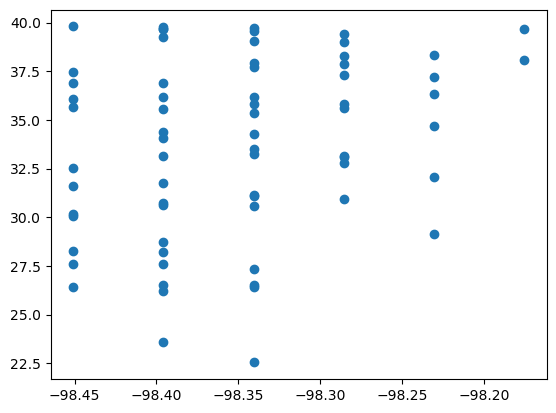

In [23]:
plt.scatter(lon[index], Hxf[index,3])

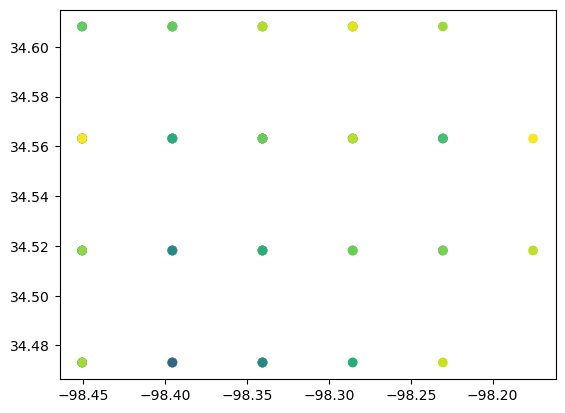

In [20]:
import matplotlib.pyplot as plt
plt.scatter(lon[index][:], lat[index][:],c= Hxf[index][:,3], )

# LETKF

In [9]:
#!/usr/bin/env python
import sys
import os
import numpy as N
import datetime as DT 
from netCDF4 import *
import pyDart
from pyDart import dll_2_dxy
import ens 
import glob
from optparse import OptionParser
from multiprocessing import Pool
from time import time as timer
from nc_prior_file import *
from assim_util import *
import state_vector as state
import pickle
import json
# Fortran functions
sys.path.append( "./fsrc" )
from fpython2 import fstate


In [ ]:
python letkf.py --exper RUN_LETKF/RUN_LETKF.exp --time 2003,05,08,21,00,00 --nthreads 1

In [8]:

#-------------------------------------------------------------------------------
# Default values 

_missing_value = 9900000000.
_time_units    = 'seconds since 1970-01-01 00:00:00'
_calendar      = 'standard'

debug  = False
_update_theta = 1
_variable_dbz_error = False

#-------------------------------------------------------------------------------
# Run parameters for the filter

obs_diag = {11: ["VR"], 12:["DBZ"]}

#-------------------------------------------------------------------------------
def getIndexEqual(field, value):
    return ( field == value )

#-------------------------------------------------------------------------------
def getIndexGT(field, value):
    return ( field > value )

#-------------------------------------------------------------------------------
def getIndexLT(field, value):
    return ( field < value )

########################################################################################################################
#
# Main program
me=True
if me==True:

  stime = timer()
  now = DT.datetime.now()

  print("----------------------------------------------------------------------\n")
  print("              BEGIN PROGRAM LETKF                                     \n ")
  print(("  WALLCLOCK START TIME:  %s \n" % now.strftime("%Y-%m-%d %H:%M")))  
  print("  --------------------------------------------------------------------\n")
  
# Create timers for the code...

  timeFilter   = myTimer(name = "Filter")
  timeIO       = myTimer(name = "I/O")
  timeMain     = myTimer(name = "Program")
  timeHxF      = myTimer(name = "HxF")
  
# Time the data assimilation

  timeMain.start()

#-------------------------------------------------------------------------------
# Parse input command options

#   parser = OptionParser()
#   parser.add_option("-f", "--file",      dest="file",     type="string", help = "Priors netCDF file")
#   parser.add_option("-t", "--time",      dest="time",     type="string", help = "Analysis time in YYYY,MM,DD,HH,MM,SS")
#   parser.add_option("-e", "--exper",     dest="exper",    type="string", help = "experiment run file created to store database info")
#   parser.add_option(      "--nthreads",  dest="nthreads", type="int",    help = "Number of threads for LETKF computation")
#   parser.add_option(      "--outl",      dest="outl",     type="int",    help = "Outlier threshold for observations")
#   parser.add_option(      "--saveW",     dest="saveW",    default=False, help = "Save LETKF weights...", action="store_true")
#   parser.add_option(      "--readW",     dest="readW",    default=False, help = "Read LETKF weights...", action="store_true")
#   parser.add_option(      "--noupdate",  dest="noupdate", default=False, help = "Do not update variables", action="store_true")
#   parser.add_option(      "--aInflate",  dest="ainflate",  type = "int",   help = "Sets type of adaptive inflation (0,1,2,3)", default=None)
#   parser.add_option(      "--HF",        dest="HF",        type = "int",   help = "Sets up writeback skip for HF filter", default=None)
  
#   (options, args) = parser.parse_args()
    
# python letkf.py --exper RUN_LETKF/RUN_LETKF.exp --time 2003,05,08,21,05,00 --nthreads 1  --aInflate 1
#-------------------------------------------------------------------------------  
# Get experiment file
  with open('DBZ_VR/DBZ_VR.exp', 'rb') as p:
        exper = json.load(p)
      
  # if options.exper == None:
  #   print("\n --> LETKF:  No experiment's run filename specified, exiting....\n")
  #   parser.print_help()
  #   sys.exit(-1)
  # else:
  #   with open(options.exper, 'rb') as p:
  #       exper = json.load(p)

#-------------------------------------------------------------------------------
# Get the time stamp
  time = '2024,05,08,20,00,00'.split(",")  
  # if options.time == None:
  #   print("\n --> LETKF:  No analysis time specified, exiting....\n")
  #   parser.print_help()
  #   sys.exit(-1)
  # else:
  #   time = options.time.split(",")
    
#-------------------------------------------------------------------------------
# The rest of the input is options - so set parameters based on what is in the experiment data base

  mpass             = exper['DA_PARAMS']['mpass']
  writeFcstMean     = exper['DA_PARAMS']['writeFcstMean']
  writeAnalMean     = exper['DA_PARAMS']['writeAnalMean']
  saveWeights       = exper['DA_PARAMS']['saveWeights']
  readWeights       = exper['DA_PARAMS']['readWeights']
  rhoriz            = exper['DA_PARAMS']['rhoriz']
  rvert             = exper['DA_PARAMS']['rvert']
  rtime             = exper['DA_PARAMS']['rtime']
  cutoff            = exper['DA_PARAMS']['cutoff']
  zcutoff           = exper['DA_PARAMS']['zcutoff']
  inflate           = exper['DA_PARAMS']['inflate']
  print_state_stats = exper['DA_PARAMS']['print_state_stats']
  path              = exper['base_path']

#-------------------------------------------------------------------------------
# Parallel Threading
  nthreads=8

  # if options.nthreads != None:
  #   nthreads = options.nthreads
  #   print(("\n --> LETKF:  Number of threads requested is from command line:  %d" % nthreads))
  # else:
  #   nthreads = exper['DA_PARAMS']['nthreads']
  #   print(("\n --> LETKF:  Number of threads requested is from EXPER file:  %d" % nthreads))
    

#-------------------------------------------------------------------------------
#  Priors file
  print("\n --> LETKF:  No netCDF Priors file specified, using default priors file")
  ftime      = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  prior_file = os.path.join(path, "Prior_%s.nc" % ftime.strftime("%Y-%m-%d_%H:%M:%S"))
  if os.path.isfile(prior_file):
    print(("\n --> LETKF:  Using prior file:  %s\n" % prior_file))

  # if options.file == None:
  #   print("\n --> LETKF:  No netCDF Priors file specified, using default priors file")
  #   ftime      = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  #   prior_file = os.path.join(path, "Prior_%s.nc" % ftime.strftime("%Y-%m-%d_%H:%M:%S"))
  #   if os.path.isfile(prior_file):
  #     print(("\n --> LETKF:  Using prior file:  %s\n" % prior_file))
  #   else:
  #     print(("\n  --> LETKF:  Could not find prior file:  %s !!!!  Exiting LETKF...." % prior_file))
  #     parser.print_help()
  #     sys.exit(-1)
  # else:
  #   prior_file = options.file

#-------------------------------------------------------------------------------
# Inflation type
  aInflate = 1
  
  inflation_deltaT = exper['DA_PARAMS']['assim_window']
  dt = DT.timedelta(0,inflation_deltaT)
  in_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5])) - dt
  inflate_file = os.path.join(path, "Inflation_%s.nc" % in_time.strftime("%Y-%m-%d_%H:%M:%S"))
  print(("\n --> LETKF:  Trying to find inflation file: %s" % inflate_file))
  inflate_file_exists = False
  if os.path.isfile(inflate_file):
    inflate_file_exists = True
    print(("\n --> LETKF:  Using inflation file: %s" % inflate_file))
      
  # if options.ainflate:
  #   aInflate = options.ainflate
  # else:
  #   aInflate   = exper['DA_PARAMS']['aInflate']
    
  # if aInflate == 0:
  #   inflate_file_exists = False
  # else:
  #   inflation_deltaT = exper['DA_PARAMS']['assim_window']
  #   dt = DT.timedelta(0,inflation_deltaT)
  #   in_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5])) - dt
  #   inflate_file = os.path.join(path, "Inflation_%s.nc" % in_time.strftime("%Y-%m-%d_%H:%M:%S"))
  #   print(("\n --> LETKF:  Trying to find inflation file: %s" % inflate_file))
  #   if os.path.isfile(inflate_file):
  #     inflate_file_exists = True
  #     print(("\n --> LETKF:  Using inflation file: %s" % inflate_file))
  #   else:
  #     inflate_file_exists = False
  #     print("\n --> LETKF:  Could not find inflation file....none will be used.")

#-------------------------------------------------------------------------------
# LETKF Weight I/O flags
  saveWeights = exper['DA_PARAMS']['saveWeights']
  readWeights = exper['DA_PARAMS']['readWeights']
#   if options.saveW:
#     saveWeights = options.saveW
#     print(("\n --> LETKF: saveWeights is from command line:  %s" % saveWeights))
#   else:  
#     saveWeights = exper['DA_PARAMS']['saveWeights']
#     print(("\n --> LETKF: saveWeights is from EXPER file:  %s" % saveWeights))

#   if options.readW:
#     readWeights = options.readW
#     print(("\n --> LETKF: readWeights is from command line:  %s" % readWeights))
#   else:  
#     readWeights = exper['DA_PARAMS']['readWeights']
#     print(("\n --> LETKF: readWeights is from EXPER file:  %s" % readWeights))
   
# #-------------------------------------------------------------------------------
# # Update flag which is useful when debugging (does not overwrite files
  noUpdate = False
#   if options.noupdate:
#       noUpdate = options.noupdate
#       print("\n --> LETKF: noUpdate is set from command line:  No files will be written back")
#   else:
#       noUpdate = False

# #-------------------------------------------------------------------------------
# # outlier threshold
  outlier_threshold = exper['DA_PARAMS']['outlier']
#   if options.outl == None:
#     outlier_threshold = exper['DA_PARAMS']['outlier']
#     print(("\n --> LETKF: obs outlier is from EXPER file:  %d" % outlier_threshold))
#   else:
#     outlier_threshold = options.outl
#     print(("\n --> LETKF: obs outlier is from command line:  %d" % outlier_threshold))

########################################################################################################################
#
# Read in STATE VECTOR for ensemble
  
  timeIO.start()

  analysis_time = DT.datetime(int(time[0]),int(time[1]),int(time[2]),int(time[3]),int(time[4]),int(time[5]))
  
  files, exper = ens.FindRestartFiles(exper, analysis_time, ret_DT=False)
  
  print(("\n  ---->LETKF:  Reading in model state for analysis at %s \n" %  (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
  
  state = ens.read_CM1_ens(files, exper, state_vector = None, DateTime=analysis_time, addmean=1)   
  ens.ens_CM1_coords(state)
  ens.ens_CM1_mean(state)
  
  tanalysis = date2num(analysis_time,units=_time_units,calendar=_calendar)
  
  print(("\n  ---->Analysis state read in for time %s " % (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
  print(("\n  ---->Analysis state universal time %f" % (tanalysis)))

  if debug:
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
    print("WARNING WARNING WARNING:  No files are written!!!!")
  else:
    if writeFcstMean:
      ens.write_CM1_ens(state, writeFcstMean=writeFcstMean, overwrite=True)
  
  timeIO.stop()
  
########################################################################################################################
#
# Read in observational priors

  timeHxF.start()
  
  analysis_sec = date2num(analysis_time,units=_time_units,calendar=_calendar)
     
  print(("\n  ----> LETKF:  Reading in Prior file:  %s \n" %  (prior_file)))
    
  kind, value, error, lat, lon, xob, yob, zob, tob, Hxf, Hxfbar, outlier = read_prior(analysis_time, file=prior_file, sort=True)

  nobs = Hxf.shape[0]
  ne   = Hxf.shape[1]
  
  if nobs == 0:  
    print(("\n  ----> LETKF:  Prior file is empty, exiting at analysis time %s \n" %  (analysis_time.strftime("%Y %m-%d %H:%M:%S"))))
    sys.exit(0)
  else:
    print(("\n  ----> LETKF:  Prior file has %d obs at analysis time %s \n" %  (nobs, analysis_time.strftime("%Y %m-%d %H:%M:%S"))))

    tob = N.array(tob - analysis_sec, dtype=N.float64)   # departure time for temporation localization

    if (outlier_threshold > 0):
      print(('\n  --> LETKF called with an outlier threshold of %d standard deviations' % outlier_threshold))

      mask  = N.where( outlier <= outlier_threshold, True, False )
      mask2 = N.where( kind == 11, True, False )
      print(("Mask before Vr mask:  ", N.count_nonzero(mask)))
      mask  = mask | mask2
      print(("Mask after Vr mask:  ", N.count_nonzero(mask)))

      kind   = kind[mask]
      value  = value[mask]
      error  = error[mask]
      tob    = tob[mask]
      xob    = xob[mask]
      yob    = yob[mask]
      zob    = zob[mask]
      Hxf    = Hxf[mask][:]
      Hxfbar = Hxfbar[mask]
      lat    = lat[mask]
      lon    = lon[mask]

      print('\n  >=====================================================================<')
      print(('\n  --> LETKF:  Number of total    obs = %d' % nobs))
      print(('\n  --> LETKF:  Number of rejected obs = %d' % (nobs - N.count_nonzero(mask) )))
      print(('\n  --> LETKF:  Max outlier: %f  Min outlier:  %f\n' % (outlier.max(), outlier.min())))
    
# Reset number of obs

      nobs = N.count_nonzero(mask)

# Change the dbz error threshold based on each obs innovation mean 

      if _variable_dbz_error:
          mask = N.where( kind == 12, True, False )
          print("  --> LETKF:  Variable dBZ error:  Number of dBZ observations is %d" % N.count_nonzero(mask))
          mask2 = N.where(value > 20., True, False)
          print("  --> LETKF:  Variable dBZ error:  Number of obs where value > 20  %d" % N.count_nonzero(mask2))
          mask  = mask & mask2
          print("  -->  LETKF:  Number of Priors where Obs > 20 and will have their values increased:  %d" % N.count_nonzero(mask))
          Hxfbar[mask] = Hxfbar[mask] + 10.
          Hxf[mask,:] = Hxf[mask,:] + 10.

# Recompute coordinate system of x/y's based from the SW corner (lat,lon) of model grid.
# The observations' new x/y's are then in the model's coordinate system relative to reference (lat,lon) of grid
# Need to do this again because of running-in-place for moving grids...

  xob, yob = pyDart.dll_2_dxy(state.late[0], lat, state.lone[0], lon, degrees=True)
  dep      = N.zeros(nobs)
  dep[:]   = value[:] - Hxfbar[:]
    
# Here we create the localization arrays

  rdiag    = N.array(error.reshape(nobs,1), order='F')
  rloc     = N.array(N.ones(nobs).reshape(nobs,1), order='F')

# Print some stats...

  print("\n  >==============================================================================================<")
  print(("\n  LETKF:  %s  Total number of observations:  %d" % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"),value.size)))
  print("\n  <==============================================================================================<")
  print("\n  LETKF:  Obs Space Diagnostic for forecast computed via Dowell and Wicker, MWR 2009, Additive Noise\n")
  print("\n  LETKF:  Obs Std  |  Root-Mean-Sq-Error  |    Bias    |  Spread (obsErr^2+Hxf_var^2)  |   Consistency Ratio")
  print("\n  >==============================================================================================<\n")

  for key in list(obs_diag.keys()):
    index_kind  = getIndexEqual(kind, key)
    d           = dep[index_kind]
    
    if obs_diag[key][0] == 'DBZ':

  # Non-zero dBZ obs
  
        index_dbz   = index_kind & getIndexGT(value, 0.1)

        if N.sum(index_dbz) > 0:
          ob_err      = error[index_dbz].mean()
          d           = dep[index_dbz]
          Hxftmp      = Hxf[index_dbz,:]
          Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
          inno_var    = N.mean((d - d.mean())**2)
          consi_ratio = (ob_err + Hxf_var) / inno_var

          print(("\n -->  LETKF:  %s  NOBS: %5.5d  %3.3s>0: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_dbz), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
        else:
          print(("\n -->  LETKF:  %3.3s>0: is not present in observations" % (obs_diag[key][0])))

  # zero dBZ obs      

        index_dbz   = index_kind & getIndexLT(value, 0.1)
        if N.sum(index_dbz) > 0:
          ob_err      = error[index_dbz].mean()
          d           = dep[index_dbz]
          Hxftmp      = Hxf[index_dbz,:]
          Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
          inno_var    = N.mean((d - d.mean())**2)
          consi_ratio = (ob_err + Hxf_var) / inno_var
          print(("\n --> LETKF:%s  NOBS: %5.5d  %3.3s<0: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_dbz), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
        else:
          print(("\n -->  LETKF:  %3.3s<=0: is not present in observations" % (obs_diag[key][0])))

  # other obs

    elif d.size > 0:

      ob_err      = error[index_kind].mean()
      d           = dep[index_kind]
      Hxftmp      = Hxf[index_kind,:]
      Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
      inno_var    = N.mean((d - d.mean())**2)
      consi_ratio = (ob_err + Hxf_var) / inno_var
      print(("\n -->  LETKF:  %s  NOBS: %5.5d    %3.3s: %3.1f  RMSI: %6.3f  M-Innov: %7.3f  Spread: %6.3f  CRatio: %7.4f " \
                % (analysis_time.strftime("%Y-%m-%d_%H:%M:%S"), N.sum(index_kind), obs_diag[key][0], N.sqrt(ob_err), \
                   N.sqrt(inno_var), d.mean(), N.sqrt(ob_err + Hxf_var), consi_ratio)))
    else:
      print(("\n -->  LETKF:  %s is not present in observations" % (obs_diag[key][0])))

  print("\n  >============================================================================================<\n")

  timeHxF.stop()
  
#################################################################################################
#
# Adaptive inflation: read in or create dummy file....

  if aInflate == 0:   # just create a dummy array of ones...
    print("\n -->  LETKF:  Adaptive inflation is turned off....\n")
    inflate = N.ones((state.nz, state.ny, state.nx), order='F', dtype=N.float64)
  else:
    print("\n -->  LETKF:  Adaptive inflation is turned on....\n")
    if inflate_file_exists:
      print(("\n -->  LETKF:  Adaptive inflation is using prior file:  %s\n" % inflate_file))
      inflate = read_inflation_file(file=inflate_file)
    else:
      print("\n -->  LETKF: Adaptive inflation cannot find the previous inflation file, initializing inflation array to 1.0 \n") 
      inflate = N.ones((state.nz, state.ny, state.nx), order='F', dtype=N.float64)
      
################################################################################################################################

# Begin LETKF analysis
 
  if print_state_stats: print_state_diagnostics(state, store=True)
  
  print("\n  >=======================  >>BEGIN FILTER<< ===========================================<\n")    

# Call the fortran letkf module

  timeFilter.start()

  if mpass == True:

    print("\n -->  LETKF:  MultiPASS algorithm turned on, assimilating VR THEN DBZ\n")
    for key in list(obs_diag.keys()):

      index_kind  = getIndexEqual(kind, key)
      if obs_diag[key][0] == "DBZ":  
        update_theta = 0
      else:
        update_theta = _update_theta

      if N.sum(index_kind) > 0:
        print(("\n-->  LETKF:  %d observations of %3.3s is now being assimilated!\n" % (N.sum(index_kind), obs_diag[key][0])))
        inflateN = fstate.compute_letkf(xob[index_kind], yob[index_kind], zob[index_kind], tob[index_kind], tanalysis,
                                        value[index_kind], Hxf[index_kind], dep[index_kind], rdiag[index_kind], rloc[index_kind], 
                                        rhoriz, rvert, rtime, nthreads, cutoff, zcutoff, update_theta, aInflate, inflate,
                                        saveWeights, readWeights)
      else:
        print(("\n -->  LETKF:%3.3s: NO OBSERVATIONS FOUND!\n" % (obs_diag[key][0])))

  else:

    print("\n -->  LETKF:ALL OBS TYPES BEING ASSIMULATED SIMULTANEOUSLY: MULTIPASS==False\n")
    update_theta = _update_theta
    inflateN = fstate.compute_letkf(xob, yob, zob, tob, tanalysis,
                                    value, Hxf, dep, rdiag, rloc, 
                                    rhoriz, rvert, rtime, nthreads, cutoff, zcutoff, update_theta, aInflate, inflate,
                                    saveWeights, readWeights)
                           
# # inflateN always has the adaptive inflation field produced by LETKF core. Write it out...

#   if aInflate > 0:
#     print(("\n -->  LETKF:  Adaptive Inflation stats:  Max AI:  %3.1f  Min AI %3.1f  Mean AI: %3.1f  StdDev:  %4.3f\n" % \
#         (inflateN.max(), inflateN.min(), inflateN.mean(), inflateN.std())))

#   InflationFile = write_inflation_file(inflateN,fstate.xc,fstate.yc,fstate.zc,analysis_time)
#   newInflationFile = os.path.join(path, InflationFile)
#   os.rename(InflationFile, newInflationFile)
#   print(("\n -->  LETKF:  Moved %s file to directory %s" %(InflationFile, path)))

# # If saveWeights == True, rename the netCDF4 file dumped out by the fortran code

#   if saveWeights:
#     rename_weight_file(analysis_time)

#   timeFilter.stop()

#   print("\n  >=======================  >>END FILTER<< ===========================================<\n")    

#   if print_state_stats: print_state_diagnostics(state, header=True)   
  
# # Write out model state
  
#   timeIO.start()

# # Write ensemble back out

#   if debug:
#     print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
#     print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
#     print("\nWARNING WARNING WARNING:  LETKF is in DEBUG mode!!!")
#     print("\nWARNING WARNING WARNING:  STATE DATA IS NOT WRITTEN BACK OUT!")
#   elif noUpdate:
#     print("\n -->  LETKF:  NO UPDATE FLAG is TRUE....state data will not be written back out!")
#   else:
#     print("\n -->  LETKF:  state data now written back out!")
#     ens.write_CM1_ens(state, writeEns=True, writeAnalMean=writeAnalMean, overwrite=False)#, HF=options.HF)
  
#   timeIO.stop()
  
# # Print out specific timing information

#   timeHxF.printit("")
#   timeFilter.printit("")
#   timeIO.printit("")
  
#   timeMain.stop()
#   timeMain.printit("")

# # Print out Wallclock time for LETKF

#   now = DT.datetime.now()

#   print("\n  ----------------------------------------------------------------------")
#   print("\n                END PROGRAM LETKF                                        ")
#   print(("\n  WALLCLOCK END TIME:  %s \n" % now.strftime("%Y-%m-%d %H:%M")))  
#   print("\n  -----------------------------------------------------------------------\n")


----------------------------------------------------------------------

              BEGIN PROGRAM LETKF                                     
 
  WALLCLOCK START TIME:  2025-04-03 23:56 

  --------------------------------------------------------------------


 --> LETKF:  No netCDF Priors file specified, using default priors file

 --> LETKF:  Using prior file:  /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:00:00.nc


 --> LETKF:  Trying to find inflation file: /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Inflation_2024-05-08_19:59:30.nc

 ==> FindRestartFiles: Date and time supplied is 2024_05_08 20:00:00

 ==> FindRestartFile:  Found time 2700 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/member001/cm1rst_000009.nc

  ---->LETKF:  Reading in model state for analysis at 2024 05-08 20:00:00 


 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_

NameError: name 'fstate' is not defined

In [11]:
index_kind  = getIndexEqual(kind, 11)

In [13]:
value[index_kind]

masked_array(data=[ 4.52374311,  6.01211415,  6.85047665,  8.33634024,
                    4.96774367,  6.07902327,  7.29477135,  9.61311077,
                    9.4009037 , 11.16060393, 11.95807832, 13.06172338,
                    5.3660868 ,  6.68399011,  7.09700164,  8.14800688,
                    3.22938288,  5.61464968,  7.54449034, 10.75111367,
                    8.33284458, 11.25389444, 13.21546589, 16.00014901,
                    7.96150039,  9.69652308, 10.93417463, 12.2930178 ,
                    8.07646047,  9.9114899 , 11.26057194, 12.22568771,
                    7.09905546,  9.02461381, 10.48046281, 11.54426008,
                    5.65622932,  8.03630907,  9.59554331, 11.0089845 ,
                    8.59196898, 10.79744315, 12.43769454, 14.09272416,
                    6.90579599,  9.37691369, 11.72306518, 13.67337322,
                    8.44746829, 10.75824723, 12.28244672, 13.58922844,
                    9.02161934, 11.14450644, 12.71962458, 13.76954021,
      

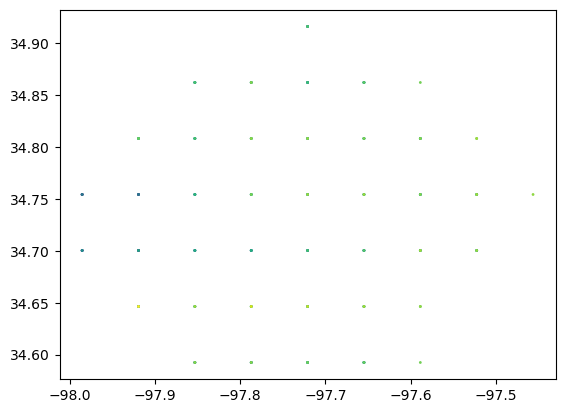

In [12]:
#P.scatter(lon[index_kind]/1000, lat[index_kind]/1000, c=value[index_kind], s=.5)
P.scatter(lon[index_kind], lat[index_kind], c=value[index_kind], s=1)
# P.xlim(0,140)
# P.ylim(0,140)

In [9]:
 kind, value, error, lat, lon, xob, yob, zob, tob, Hxf, Hxfbar, outlier = read_prior(analysis_time, file=prior_file, sort=True)

Prior obs file found, opening /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:00:00.nc 

Total number of obs in /work/jessica.mcdonald/CM1_LETKF_2025/DBZ_VR/Prior_2024-05-08_20:00:00.nc file is 2049 



In [10]:
len(kind)

2049

In [11]:
ob_err      = error[index_kind].mean()
d           = dep[index_kind]
Hxftmp      = Hxf[index_kind,:]
Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean()
inno_var    = N.mean((d - d.mean())**2)
consi_ratio = (ob_err + Hxf_var) / inno_var

In [13]:
d

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan])

In [17]:
index_kind  = getIndexEqual(kind, 12)
Hxfbar[index_kind]

masked_array(data=[0., 0., 0., ..., 0., 0., 0.],
             mask=False,
       fill_value=1e+20)